# CCLE TP53 Project EDA: RNA-only dataset preparation

This notebook prepares the CCLE dataset for an **RNA-expression-first TP53 mutation prediction project**.

Important terminology used throughout the notebook:
- **TP53 mutation status** means DNA/somatic mutation status of the `TP53` gene. It does **not** mean TP53 RNA expression level.
- **RNA-expression features** are the model inputs: expression values for thousands of genes.
- **TP53 mutation annotations** are used upstream only to construct labels, not as model predictors.
- **TP53 target genes / p53-response genes** are genes whose expression may be regulated downstream of p53 activity. They are not genes that are necessarily mutated in the samples.
- **Wild type** means no retained protein-altering TP53 mutation annotation under the notebook's label rules. It does not prove fully normal p53 pathway function, copy number, methylation, or protein activity.

Design choices for the assignment:
- **Primary signal source:** mRNA / RNA-seq expression features.
- **Labels:** TP53 mutation annotations are used only upstream to define targets.
- **Lineage:** used as a stratification and audit variable, not as a primary model predictor.
- **Primary Task 1 label:** `TP53_mut_nonsyn`.

The notebook produces aligned artifacts for the modeling section:
1. filtered RNA expression matrix;
2. metadata table for split auditing and lineage stratification only;
3. TP53 labels and split membership.

Important modeling rule: supervised feature selection is performed inside modeling pipelines/CV, not in EDA.


## 0. Setup

This section defines Kaggle-ready paths, configuration, and helper functions for:
- TP53 label construction;
- train-only RNA filtering;
- exploratory RNA association analysis;
- sample QC / outlier flagging;
- lineage-stratified split construction;
- a compact `TP53_TARGETS` reference set used for p53 biology checks.

The `TP53_TARGETS` set is a curated biological reference panel of known/canonical p53-response genes. It is not discovered from this CCLE dataset and it is not a list of mutated genes. The code later checks which of those reference genes are present as RNA-expression columns. The alias mapping, for example `WIG1 -> ZMAT3`, handles gene-symbol naming differences.

If raw CCLE files are not attached, the raw EDA cells are skipped and the modeling section tries to use already-created `processed/` artifacts.


In [1]:
from pathlib import Path
from IPython.display import display

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
from scipy import stats
import sklearn
import statsmodels

from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

RNG = 42

# Kaggle-ready input discovery. Attach a Kaggle Dataset containing the CCLE/DepMap
# files, or place them under ./data for local runs. The notebook writes processed
# artifacts only to the writable working directory.
CWD = Path.cwd()
SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("./data"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]
if str(CWD) not in {"/", "/mnt"} and CWD not in SEARCH_ROOTS:
    SEARCH_ROOTS.insert(2, CWD)
OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True, parents=True)


def list_available_files_for_debug(roots=SEARCH_ROOTS, max_files=80):
    rows = []
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob("*"):
            if p.is_file():
                rows.append(str(p))
                if len(rows) >= max_files:
                    break
        if len(rows) >= max_files:
            break
    return rows


def find_first_file(patterns, roots=SEARCH_ROOTS, required=False, label="input file"):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = sorted([p for p in root.rglob(pattern) if p.is_file()])
            if matches:
                return matches[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        sample_files = list_available_files_for_debug()
        raise FileNotFoundError(
            f"Could not find required {label}. Tried:\n"
            + "\n".join(tried)
            + "\n\nFirst files visible to this Kaggle notebook:\n"
            + "\n".join(sample_files[:80])
        )
    return None

MODEL_PATH = find_first_file(["Model.csv", "*Model*.csv", "sample_info.csv", "*sample*info*.csv"], label="CCLE model metadata")
MUT_PATH = find_first_file(["OmicsSomaticMutations.csv", "*OmicsSomaticMutations*.csv", "*mutation*.csv", "*Mutation*.csv"], label="CCLE somatic mutations")
EXPR_PATH = find_first_file([
    "OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    "*OmicsExpressionProteinCodingGenesTPMLogp1*.csv",
    "*OmicsExpressionProteinCodingGenesTPM*.csv",
    "*expression*.csv",
    "*Expression*.csv",
], label="CCLE RNA expression")

RAW_CCLE_AVAILABLE = MODEL_PATH is not None and MUT_PATH is not None and EXPR_PATH is not None

if RAW_CCLE_AVAILABLE:
    print("Using raw CCLE inputs:")
    print("  MODEL_PATH:", MODEL_PATH)
    print("  MUT_PATH:", MUT_PATH)
    print("  EXPR_PATH:", EXPR_PATH)
else:
    print("Raw CCLE files were not all found. Raw CCLE EDA cells will be skipped.")
    print("The modeling section will try to use an existing processed/ directory instead.")
    print("Found paths:")
    print("  MODEL_PATH:", MODEL_PATH)
    print("  MUT_PATH:", MUT_PATH)
    print("  EXPR_PATH:", EXPR_PATH)
    print("First files visible to the notebook:")
    for f in list_available_files_for_debug(max_files=40):
        print("  ", f)

CONFIG = {
    "primary_label": "TP53_mut_nonsyn",
    "detect_expr_threshold": 0.10,
    "min_detect_frac": 0.05,
    "min_variance": 1e-4,
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features_for_eda": 300,
    "outlier_vote_possible": 3,
    "outlier_vote_sure": 4,
    "outlier_contamination": 0.05,
    "min_meta_category_n": 15,
    "test_size": 0.15,
    "val_size_within_temp": 0.15 / 0.85,
}


def choose_first_present(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def collapse_duplicate_gene_columns(df):
    n_dup = int(df.columns.duplicated().sum())
    if n_dup == 0:
        return df, 0
    collapsed = df.T.groupby(level=0).mean().T
    return collapsed, n_dup


def robust_zscore(values):
    s = pd.Series(values, copy=True)
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0 or pd.isna(mad):
        return pd.Series(0.0, index=s.index)
    return 0.6745 * (s - med) / mad


def mad_flag(values, threshold=3.5):
    return robust_zscore(values).abs() > threshold


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


TP53_TEXT_COLS = [
    "VariantClassification",
    "VariantInfo",
    "VariantType",
    "ProteinChange",
    "HGVSp_Short",
    "HGVSp",
    "RefSeq",
]


def classify_tp53_event(row):
    vc = str(row.get("VariantClassification", "")).strip().lower()
    vt = str(row.get("VariantType", "")).strip().lower()
    text = " ".join(str(row.get(c, "")) for c in TP53_TEXT_COLS).lower()

    if vc in {
        "frame_shift_del", "frame_shift_ins", "frameshift_deletion", "frameshift_insertion",
        "nonsense_mutation", "splice_site", "translation_start_site",
        "start_codon_del", "start_codon_ins", "stop_codon_del", "stop_codon_ins",
    }:
        return "lof_or_splice"

    if vc in {"missense_mutation", "in_frame_del", "in_frame_ins"}:
        return "missense_or_inframe"

    if vc in {"silent", "synonymous"}:
        return "synonymous"

    lof_terms = [
        "frameshift", "frame_shift", "nonsense", "stop_gained", "stopgain",
        "splice", "start_lost", "stop_lost", "trunc", "truncating",
    ]
    missense_terms = [
        "missense", "nonsynonymous", "non_synonymous", "inframe", "in_frame",
        "nonframeshift", "non_frameshift",
    ]
    syn_terms = ["synonymous", "silent"]

    if any(term in text for term in lof_terms):
        return "lof_or_splice"
    if any(term in text for term in missense_terms):
        return "missense_or_inframe"
    if any(term in text for term in syn_terms):
        return "synonymous"
    if vc:
        return "other_or_unknown"
    if vt in {"snp", "dnp", "tnp", "onp", "del", "ins"}:
        return "other_or_unknown"
    return "unknown"


def corr_against_binary(X, y, method="pearson"):
    assert X.index.equals(y.index), "X and y must have aligned indices."
    y = pd.Series(y, index=X.index).astype(float)
    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def collapse_categories(train_s, val_s, min_n=15, other_label="Other"):
    train_s = train_s.fillna("Unknown").astype(str)
    val_s = val_s.fillna("Unknown").astype(str)
    counts = train_s.value_counts()
    major = set(counts[counts >= min_n].index.tolist())
    train_out = train_s.where(train_s.isin(major), other=other_label)
    val_out = val_s.where(val_s.isin(major), other=other_label)
    return train_out, val_out, counts


def eval_meta_baseline(train_df, val_df, y_train, y_val, cols, min_n=15):
    if len(cols) == 0:
        return None

    train_proc = pd.DataFrame(index=train_df.index)
    val_proc = pd.DataFrame(index=val_df.index)

    for c in cols:
        train_proc[c], val_proc[c], _ = collapse_categories(train_df[c], val_df[c], min_n=min_n)

    enc = make_dense_onehot_encoder()
    Xtr = enc.fit_transform(train_proc)
    Xva = enc.transform(val_proc)

    clf = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RNG)
    clf.fit(Xtr, y_train)
    prob = clf.predict_proba(Xva)[:, 1]

    return {
        "model": "+".join(cols),
        "n_features": Xtr.shape[1],
        "auroc": roc_auc_score(y_val, prob),
        "auprc": average_precision_score(y_val, prob),
    }



def make_stable_joint_strata(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

def save_parquet_with_id(df, filename, id_col="ModelID"):
    path = OUT_DIR / filename
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(path, index=False)
    return path


def save_series_with_id(s, filename, value_name=None, id_col="ModelID"):
    path = OUT_DIR / filename
    s = s.copy()

    # Ensure the value column has a valid string name
    if value_name is None:
        if s.name is None:
            value_name = filename.replace(".parquet", "")
        else:
            value_name = str(s.name)
    else:
        value_name = str(value_name)

    # Ensure the index column name is also a string
    if id_col is None:
        id_col = s.index.name if s.index.name is not None else "ModelID"
    id_col = str(id_col)

    df = s.rename(value_name).rename_axis(id_col).reset_index()

    # Final safety: force all column names to strings
    df.columns = [str(c) for c in df.columns]

    df.to_parquet(path, index=False)
    return path

print(
    f"pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__} | "
    f"sklearn {sklearn.__version__} | statsmodels {statsmodels.__version__}"
)
print(json.dumps(CONFIG, indent=2))


Using raw CCLE inputs:
  MODEL_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/Model.csv
  MUT_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/OmicsSomaticMutations.csv
  EXPR_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/OmicsExpressionProteinCodingGenesTPMLogp1.csv
pandas 2.3.3 | numpy 2.0.2 | scipy 1.16.3 | sklearn 1.6.1 | statsmodels 0.14.6
{
  "primary_label": "TP53_mut_nonsyn",
  "detect_expr_threshold": 0.1,
  "min_detect_frac": 0.05,
  "min_variance": 0.0001,
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features_for_eda": 300,
  "outlier_vote_possible": 3,
  "outlier_vote_sure": 4,
  "outlier_contamination": 0.05,
  "min_meta_category_n": 15,
  "test_size": 0.15,
  "val_size_within_temp": 0.17647058823529413
}


## 1. Load data, keep audit metadata, and build TP53 labels

The goal here is to build a **clean sample table** with:
- expression data;
- audit metadata for lineage stratification and split checks;
- TP53 labels.

The TP53 labels are derived from somatic mutation annotations for `TP53`. They are not derived from TP53 expression and they do not use RNA values.

For interpretation, remember that a sample called `wild_type` here means **no retained protein-altering TP53 mutation under the notebook's rules**. It does not prove that the p53 pathway is fully normal, because other alterations such as copy-number loss, methylation, post-translational effects, or mutations outside the retained annotation logic could still affect p53 biology.

Metadata is retained for stratification/auditing only. It is **not** used as a predictor in the submitted RNA-only models.


In [2]:
if RAW_CCLE_AVAILABLE:
    model = pd.read_csv(MODEL_PATH)
    muts = pd.read_csv(MUT_PATH, low_memory=False)
    expr = pd.read_csv(EXPR_PATH, index_col=0)

    assert "ModelID" in muts.columns, "Expected ModelID in mutation file."
    assert "HugoSymbol" in muts.columns, "Expected HugoSymbol in mutation file."

    expr.index.name = "ModelID"
    expr.columns = expr.columns.str.replace(r"\s*\([^)]*\)$", "", regex=True)
    expr, n_collapsed_gene_names = collapse_duplicate_gene_columns(expr)

    lineage_col = choose_first_present(
        model.columns,
        ["OncotreeLineage", "OncotreeLineageDerived", "Lineage", "lineage"],
    )
    disease_col = choose_first_present(
        model.columns,
        ["OncotreePrimaryDisease", "PrimaryDisease", "Primary Disease", "Disease"],
    )
    sex_col = choose_first_present(
        model.columns,
        ["Sex", "sex", "Gender", "gender", "PatientSex"],
    )
    name_col = choose_first_present(
        model.columns,
        ["StrippedCellLineName", "CellLineName", "ModelName", "CCLEName"],
    )

    model_keep = ["ModelID"] + [c for c in [name_col, lineage_col, sex_col, disease_col] if c is not None]
    model_meta = model[model_keep].drop_duplicates("ModelID").set_index("ModelID")

    expr_ids = pd.Index(expr.index.unique(), name="ModelID")
    mut_ids = pd.Index(pd.Series(muts["ModelID"].dropna().astype(str).unique()).sort_values(), name="ModelID")
    model_ids = pd.Index(model_meta.index.unique().astype(str), name="ModelID")

    overlap_summary = pd.Series(
        {
            "expression_samples": len(expr_ids),
            "mutation_covered_samples": len(mut_ids),
            "metadata_samples": len(model_ids),
            "expr_and_mut_overlap": len(expr_ids.intersection(mut_ids)),
            "expr_and_meta_overlap": len(expr_ids.intersection(model_ids)),
            "mut_and_meta_overlap": len(mut_ids.intersection(model_ids)),
            "expr_mut_meta_overlap": len(expr_ids.intersection(mut_ids).intersection(model_ids)),
        },
        name="n",
    )

    print(f"Model:      {model.shape}")
    print(f"Mutations:  {muts.shape}")
    print(f"Expression: {expr.shape}")
    print(f"Collapsed duplicate gene symbols after stripping suffixes: {n_collapsed_gene_names}")
    print(f"Metadata columns kept: {[c for c in [name_col, lineage_col, sex_col, disease_col] if c is not None]}")
    display(overlap_summary.to_frame())

    tp53_muts = muts.loc[muts["HugoSymbol"].eq("TP53")].copy()
    tp53_muts["tp53_event_class"] = tp53_muts.apply(classify_tp53_event, axis=1)

    priority_map = {
        "lof_or_splice": 5,
        "missense_or_inframe": 4,
        "other_or_unknown": 3,
        "synonymous": 2,
        "unknown": 1,
    }
    tp53_muts["priority"] = tp53_muts["tp53_event_class"].map(priority_map).fillna(0).astype(int)

    best_tp53 = (
        tp53_muts.sort_values(["ModelID", "priority"], ascending=[True, False])
        .drop_duplicates("ModelID", keep="first")
        .set_index("ModelID")
    )

    called_ids = set(muts["ModelID"].dropna().astype(str).unique())
    expr_ids = set(expr.index.astype(str))
    common = sorted(called_ids & expr_ids)

    expr.index = expr.index.astype(str)
    X_all = expr.loc[common].copy()

    sample_meta = pd.DataFrame(index=pd.Index(common, name="ModelID")).join(model_meta, how="left")
    sample_meta["TP53_event_class"] = best_tp53["tp53_event_class"].reindex(common)
    sample_meta["tp53_event_count"] = tp53_muts.groupby("ModelID").size().reindex(common).fillna(0).astype(int)

    sample_meta["TP53_mut_any"] = sample_meta.index.isin(best_tp53.index.astype(str)).astype(int)
    sample_meta["TP53_mut_nonsyn"] = sample_meta["TP53_event_class"].isin(["lof_or_splice", "missense_or_inframe"]).astype(int)
    sample_meta["TP53_mut_lof"] = sample_meta["TP53_event_class"].eq("lof_or_splice").astype(int)
    sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(["other_or_unknown", "unknown", "synonymous"]).astype(int)

    mut_type = sample_meta["TP53_event_class"].fillna("wild_type").rename("mut_type")
    sample_meta["TP53_task2_label"] = mut_type.astype(str)
    y_primary = sample_meta[CONFIG["primary_label"]].rename(CONFIG["primary_label"])

    print(f"Usable samples with mutation-call coverage and expression: {len(common):,}")
    print(f"Primary label ({CONFIG['primary_label']}): {int(y_primary.sum()):,} positives ({y_primary.mean():.1%})")
    print(f"TP53_mut_any:   {int(sample_meta['TP53_mut_any'].sum()):,} positives ({sample_meta['TP53_mut_any'].mean():.1%})")
    print(f"TP53_mut_lof:   {int(sample_meta['TP53_mut_lof'].sum()):,} positives ({sample_meta['TP53_mut_lof'].mean():.1%})")
    print(f"Cell lines with >1 TP53 event: {(sample_meta['tp53_event_count'] > 1).sum():,}")

    event_counts = (
        sample_meta["TP53_event_class"]
        .fillna("wild_type")
        .value_counts(dropna=False)
        .rename_axis("event_class")
        .to_frame("n_cell_lines")
    )
    display(event_counts)
else:
    print('Skipping this CCLE raw-EDA cell because raw CCLE files were not found. The modeling section will try to use processed/ artifacts instead.')


Model:      (2116, 49)
Mutations:  (751310, 70)
Expression: (1684, 19205)
Collapsed duplicate gene symbols after stripping suffixes: 0
Metadata columns kept: ['StrippedCellLineName', 'OncotreeLineage', 'Sex', 'OncotreePrimaryDisease']


,n
expression_samples,1684
mutation_covered_samples,1939
metadata_samples,2116
expr_and_mut_overlap,1608
expr_and_meta_overlap,1684
mut_and_meta_overlap,1939
expr_mut_meta_overlap,1608


Usable samples with mutation-call coverage and expression: 1,608
Primary label (TP53_mut_nonsyn): 987 positives (61.4%)
TP53_mut_any:   987 positives (61.4%)
TP53_mut_lof:   362 positives (22.5%)
Cell lines with >1 TP53 event: 115


,n_cell_lines
event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 1b. Inspect raw TP53 mutation annotations

This block directly inspects the raw TP53 mutation rows using the mutation-annotation columns most relevant for manual review:

- `HugoSymbol`
- `VariantType`
- `VariantInfo`
- `DNAChange`
- `ProteinChange`

This does **not** replace the derived label logic above. It is a QC step to verify that the raw TP53 rows look biologically and syntactically sensible before continuing.

These mutation columns are never used as model input features. They are used only to decide whether a sample should be labeled as TP53 protein-altering mutant, WT/non-protein-altering, ambiguous, or a broader mutation-consequence class.


In [3]:
if RAW_CCLE_AVAILABLE:
    # Direct TP53 / p53 mutation annotation QC
    required_tp53_cols = [
        "HugoSymbol",
        "VariantType",
        "VariantInfo",
        "DNAChange",
        "ProteinChange",
    ]

    missing_tp53_cols = [c for c in required_tp53_cols if c not in tp53_muts.columns]
    if missing_tp53_cols:
        print(f"Missing expected TP53 mutation columns: {missing_tp53_cols}")

    tp53_view_cols = [c for c in required_tp53_cols if c in tp53_muts.columns]
    tp53_view = tp53_muts[tp53_view_cols].copy()

    print(f"Total TP53 mutation rows: {len(tp53_view):,}")
    print(f"Unique ModelID with any TP53 row: {tp53_muts['ModelID'].astype(str).nunique():,}")

    print("First TP53 rows (raw annotations):")
    display(tp53_view.head(20))

    if "VariantType" in tp53_view.columns:
        print("VariantType counts:")
        display(tp53_view["VariantType"].fillna("<NA>").value_counts(dropna=False).to_frame("n_rows"))

    if "VariantInfo" in tp53_view.columns:
        print("VariantInfo counts:")
        display(tp53_view["VariantInfo"].fillna("<NA>").value_counts(dropna=False).to_frame("n_rows"))

    if "ProteinChange" in tp53_view.columns:
        print("Top ProteinChange values:")
        display(tp53_view["ProteinChange"].fillna("<NA>").value_counts(dropna=False).head(25).to_frame("n_rows"))

    missingness_summary = pd.Series(
        {c: int(tp53_view[c].isna().sum()) for c in tp53_view.columns},
        name="n_missing",
    )
    print("Missing values across TP53 review columns:")
    display(missingness_summary.to_frame())

    # Helpful QC views for rows that may need manual inspection
    qc_examples = {}
    if "ProteinChange" in tp53_view.columns:
        qc_examples["missing_protein_change"] = tp53_muts.loc[
            tp53_muts["ProteinChange"].isna(),
            ["ModelID"] + tp53_view_cols + [c for c in ["VariantClassification", "tp53_event_class"] if c in tp53_muts.columns],
        ].head(15)

    if "DNAChange" in tp53_view.columns:
        qc_examples["missing_dna_change"] = tp53_muts.loc[
            tp53_muts["DNAChange"].isna(),
            ["ModelID"] + tp53_view_cols + [c for c in ["VariantClassification", "tp53_event_class"] if c in tp53_muts.columns],
        ].head(15)

    if "tp53_event_class" in tp53_muts.columns:
        qc_examples["ambiguous_or_unknown"] = tp53_muts.loc[
            tp53_muts["tp53_event_class"].isin(["other_or_unknown", "unknown", "synonymous"]),
            ["ModelID"] + tp53_view_cols + [c for c in ["VariantClassification", "tp53_event_class"] if c in tp53_muts.columns],
        ].head(20)

    for name, df in qc_examples.items():
        if len(df) > 0:
            print(f"QC example: {name}")
            display(df)

    # Compact table to compare raw mutation annotations against the derived TP53 event label
    tp53_review_summary = tp53_muts.loc[:, [c for c in [
        "ModelID", "HugoSymbol", "VariantType", "VariantInfo", "DNAChange", "ProteinChange",
        "VariantClassification", "tp53_event_class"
    ] if c in tp53_muts.columns]].copy()

    display(tp53_review_summary.head(20))
else:
    print('Skipping this CCLE raw-EDA cell because raw CCLE files were not found. The modeling section will try to use processed/ artifacts instead.')


Total TP53 mutation rows: 1,319
Unique ModelID with any TP53 row: 1,174
First TP53 rows (raw annotations):


,HugoSymbol,VariantType,VariantInfo,DNAChange,ProteinChange
154890,TP53,SNV,missense_variant,ENST00000269305.9:c.1165G>T,p.G389W
154891,TP53,deletion,frameshift_variant,ENST00000269305.9:c.1146del,p.K382NfsTer40
154892,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN
154893,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN
154894,TP53,deletion,splice_donor_variant&coding_sequence_variant,ENST00000269305.9:c.1097_1100+1del,NaN
154895,TP53,substitution,missense_variant,ENST00000269305.9:c.1049_1050delinsCT,p.L350P
154896,TP53,SNV,missense_variant,ENST00000269305.9:c.1049T>C,p.L350P
154897,TP53,SNV,stop_gained,ENST00000269305.9:c.1045G>T,p.E349Ter
154898,TP53,SNV,missense_variant,ENST00000269305.9:c.1040C>T,p.A347V
154899,TP53,SNV,missense_variant,ENST00000269305.9:c.1039G>C,p.A347P


VariantType counts:


,n_rows
VariantType,
SNV,1106
deletion,147
insertion,43
substitution,23


VariantInfo counts:


...

Missing values across TP53 review columns:


,n_missing
HugoSymbol,0
VariantType,0
VariantInfo,0
DNAChange,0
ProteinChange,111


QC example: missing_protein_change


,ModelID,HugoSymbol,VariantType,VariantInfo,DNAChange,ProteinChange,tp53_event_class
154892,ACH-000997,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154893,ACH-001061,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154894,ACH-000227,TP53,deletion,splice_donor_variant&coding_sequence_variant,ENST00000269305.9:c.1097_1100+1del,NaN,lof_or_splice
154919,ACH-001143,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.994-1G>A,NaN,lof_or_splice
154920,ACH-000484,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.994-2A>G,NaN,lof_or_splice
154921,ACH-000243,TP53,deletion,splice_donor_variant&splice_donor_5th_base_var...,ENST00000269305.9:c.972_993+16del,NaN,lof_or_splice
154922,ACH-000557,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+2T>G,NaN,lof_or_splice
154923,ACH-000502,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+1G>A,NaN,lof_or_splice
154924,ACH-002665,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+1G>C,NaN,lof_or_splice
154925,ACH-000021,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+1G>T,NaN,lof_or_splice


,ModelID,HugoSymbol,VariantType,VariantInfo,DNAChange,ProteinChange,tp53_event_class
154890,ACH-000940,TP53,SNV,missense_variant,ENST00000269305.9:c.1165G>T,p.G389W,missense_or_inframe
154891,ACH-000632,TP53,deletion,frameshift_variant,ENST00000269305.9:c.1146del,p.K382NfsTer40,lof_or_splice
154892,ACH-000997,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154893,ACH-001061,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154894,ACH-000227,TP53,deletion,splice_donor_variant&coding_sequence_variant,ENST00000269305.9:c.1097_1100+1del,NaN,lof_or_splice
154895,ACH-001975,TP53,substitution,missense_variant,ENST00000269305.9:c.1049_1050delinsCT,p.L350P,missense_or_inframe
154896,ACH-002283,TP53,SNV,missense_variant,ENST00000269305.9:c.1049T>C,p.L350P,missense_or_inframe
154897,ACH-000720,TP53,SNV,stop_gained,ENST00000269305.9:c.1045G>T,p.E349Ter,lof_or_splice
154898,ACH-000701,TP53,SNV,missense_variant,ENST00000269305.9:c.1040C>T,p.A347V,missense_or_inframe
154899,ACH-000803,TP53,SNV,missense_variant,ENST00000269305.9:c.1039G>C,p.A347P,missense_or_inframe


## 2. Train / validation / test split

The primary binary CCLE split is stratified on **TP53 mutation status x CCLE lineage** where feasible. This is important because TP53 mutation prevalence and RNA-expression structure both vary by cancer lineage. If the test set had a very different lineage composition from the training set, the estimated performance could reflect lineage composition rather than TP53-associated expression signal.

This split remains a **global** train/validation/test split across all cell lines. It does not train separate lineage-specific models. Lineage is used only to balance the split and to audit possible confounding.

Because some lineages are small, strict TP53-label-by-lineage stratification can create tiny strata. For example, a rare lineage may contain only one or two TP53-mutant samples. Such strata cannot be safely divided across train, validation, and test sets. To handle this, the split code uses adaptive stratification:

1. common TP53-label-by-lineage cells are kept as separate strata;
2. rare lineage-label cells are collapsed into a rare-lineage bucket;
3. if the resulting strata are still too small, the code falls back to TP53-label-only stratification.

This avoids dropping samples while still reducing lineage confounding. The resulting split should be interpreted as lineage-balanced for the common lineages, not as proof that every rare lineage has enough samples for reliable lineage-specific performance estimates.

Lineage is not used as an input feature for the primary RNA model.

In [4]:
if RAW_CCLE_AVAILABLE:
    if lineage_col is None or lineage_col not in sample_meta.columns:
        print("No lineage column found; falling back to TP53-label-only stratification.")
        split_strata_all = y_primary.astype(str)
        split_stratification_note = "TP53 label only; lineage unavailable"
    else:
        split_strata_all = make_stable_joint_strata(
            labels=y_primary,
            groups=sample_meta.loc[y_primary.index, lineage_col],
            min_count=2,
            group_name="lineage",
            split_fraction=CONFIG["test_size"],
            min_group_count=15,
        )
        split_stratification_note = f"TP53 label x {lineage_col}"

    idx_temp, idx_test = train_test_split(
        y_primary.index,
        test_size=CONFIG["test_size"],
        stratify=split_strata_all,
        random_state=RNG,
    )
    idx_temp = pd.Index(idx_temp, name=y_primary.index.name)
    idx_test = pd.Index(idx_test, name=y_primary.index.name)

    temp_groups = (
        sample_meta.loc[idx_temp, lineage_col]
        if lineage_col is not None and lineage_col in sample_meta.columns
        else pd.Series("missing", index=idx_temp)
    )
    split_strata_temp = make_stable_joint_strata(
        labels=y_primary.loc[idx_temp],
        groups=temp_groups,
        min_count=2,
        group_name="lineage",
    )

    idx_train, idx_val = train_test_split(
        idx_temp,
        test_size=CONFIG["val_size_within_temp"],
        stratify=split_strata_temp,
        random_state=RNG,
    )
    idx_train = pd.Index(idx_train, name=y_primary.index.name)
    idx_val = pd.Index(idx_val, name=y_primary.index.name)

    X_train = X_all.loc[idx_train]
    X_val = X_all.loc[idx_val]
    X_test = X_all.loc[idx_test]

    y_train = y_primary.loc[idx_train]
    y_val = y_primary.loc[idx_val]
    y_test = y_primary.loc[idx_test]

    split_membership = pd.Series(index=X_all.index, dtype="object")
    split_membership.loc[idx_train] = "train"
    split_membership.loc[idx_val] = "val"
    split_membership.loc[idx_test] = "test"
    sample_meta["split"] = split_membership

    split_summary = pd.DataFrame(
        {
            "n": [len(y_train), len(y_val), len(y_test)],
            "tp53_mut_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
        },
        index=["train", "val", "test"],
    )
    print(f"Primary split stratification: {split_stratification_note}")
    display(split_summary.round(3))

    if lineage_col is not None and lineage_col in sample_meta.columns:
        split_lineage_counts = pd.crosstab(
            sample_meta.loc[split_membership.notna(), lineage_col].fillna("Unknown"),
            sample_meta.loc[split_membership.notna(), "split"],
        ).sort_values("train", ascending=False)
        print("Lineage distribution across primary Task 1 splits, top 20 lineages:")
        display(split_lineage_counts.head(20))
else:
    print("Skipping split construction from raw CCLE files because raw CCLE inputs were not found.")


Using adaptive TP53-label x lineage strata: 50 strata; rare lineage threshold=15. No samples dropped.
Using adaptive TP53-label x lineage strata: 53 strata; rare lineage threshold=10. No samples dropped.
Primary split stratification: TP53 label x OncotreeLineage


,n,tp53_mut_rate
train,1124,0.613
val,242,0.616
test,242,0.616


Lineage distribution across primary Task 1 splits, top 20 lineages:


split,test,train,val
OncotreeLineage,,,
Lung,30,139,30
Lymphoid,28,128,28
Skin,18,83,18
CNS/Brain,14,67,14
Bowel,13,58,13
Esophagus/Stomach,12,54,12
Head and Neck,11,51,11
Myeloid,10,51,10
Breast,10,49,10


## 3. Metadata diagnostics for optional audit variables

These checks are here because metadata can reveal confounding and split imbalance, even when it is not used as a model feature.

We therefore inspect:
- missingness;
- category balance across splits;
- primary-label rate by category in training.

In the submitted RNA-only models, lineage/metadata variables are used for stratification, auditing, subgroup summaries, and grouped robustness checks. They are not predictors in the main model.


In [5]:
if RAW_CCLE_AVAILABLE:
    present_meta_cols = [c for c in [lineage_col, sex_col, disease_col] if c is not None]
    recommended_meta_cols = []  # metadata is not used as a predictor
    metadata_audit_cols = [c for c in [lineage_col, sex_col] if c is not None]

    if not present_meta_cols:
        print("No metadata covariates found beyond ModelID / names.")
    else:
        meta_missing = pd.DataFrame(
            {
                "missing_n": sample_meta[present_meta_cols].isna().sum(),
                "missing_frac": sample_meta[present_meta_cols].isna().mean(),
            }
        ).sort_values("missing_frac", ascending=False)
        print("Metadata missingness:")
        display(meta_missing.round(3))

        for col in present_meta_cols:
            print(f"\n=== {col} ===")
            top_by_split = (
                sample_meta[["split", col]]
                .assign(**{col: lambda d: d[col].fillna("Unknown").astype(str)})
                .groupby(["split", col])
                .size()
                .rename("n")
                .reset_index()
            )
            display(top_by_split.sort_values(["split", "n"], ascending=[True, False]).groupby("split").head(8))

            train_rates = (
                sample_meta.loc[X_train.index, [col, CONFIG["primary_label"]]]
                .assign(**{col: lambda d: d[col].fillna("Unknown").astype(str)})
                .groupby(col)
                .agg(n=(CONFIG["primary_label"], "size"), tp53_rate=(CONFIG["primary_label"], "mean"))
                .sort_values("n", ascending=False)
            )
            display(train_rates.head(15).round(3))

    print("Metadata columns retained for stratification/auditing only:")
    print(metadata_audit_cols if metadata_audit_cols else "[]")
else:
    print('Skipping this CCLE raw-EDA cell because raw CCLE files were not found. The modeling section will try to use processed/ artifacts instead.')


Metadata missingness:


,missing_n,missing_frac
OncotreeLineage,5,0.003
Sex,0,0.000
OncotreePrimaryDisease,0,0.000



=== OncotreeLineage ===


,split,OncotreeLineage,n
15,test,Lung,30
16,test,Lymphoid,28
23,test,Skin,18
7,test,CNS/Brain,14
5,test,Bowel,13
9,test,Esophagus/Stomach,12
12,test,Head and Neck,11
6,test,Breast,10
41,train,Lung,139
42,train,Lymphoid,128


,n,tp53_rate
OncotreeLineage,,
Lung,139,0.885
Lymphoid,128,0.523
Skin,83,0.337
CNS/Brain,67,0.642
Bowel,58,0.776
Esophagus/Stomach,54,0.852
Myeloid,51,0.588
Head and Neck,51,0.902
Breast,49,0.776


...

,n,tp53_rate
Sex,,
Male,593,0.634
Female,477,0.593
Unknown,54,0.556



=== OncotreePrimaryDisease ===


,split,OncotreePrimaryDisease,n
41,test,Non-Small Cell Lung Cancer,24
32,test,Melanoma,17
30,test,Mature B-Cell Neoplasms,13
10,test,Colorectal Adenocarcinoma,12
12,test,Diffuse Glioma,12
21,test,Head and Neck Squamous Cell Carcinoma,11
44,test,Ovarian Epithelial Tumor,10
0,test,Acute Myeloid Leukemia,9
108,train,Non-Small Cell Lung Cancer,90
97,train,Melanoma,76


,n,tp53_rate
OncotreePrimaryDisease,,
Non-Small Cell Lung Cancer,90,0.844
Melanoma,76,0.303
Mature B-Cell Neoplasms,74,0.541
Colorectal Adenocarcinoma,57,0.789
Diffuse Glioma,50,0.740
Head and Neck Squamous Cell Carcinoma,49,0.918
Invasive Breast Carcinoma,47,0.787
Lung Neuroendocrine Tumor,46,0.957
Ovarian Epithelial Tumor,44,0.773


Metadata columns retained for stratification/auditing only:
['OncotreeLineage', 'Sex']


## 4. Training-only low-information RNA filtering

This is the core RNA preprocessing step used for downstream modeling.

The key rule is preserved:
- filtering thresholds are learned on the **training split only**
- the same kept-gene mask is then applied to validation and test


In [6]:
if RAW_CCLE_AVAILABLE:
    detected_frac = (X_train > CONFIG["detect_expr_threshold"]).mean(axis=0)
    variance = X_train.var(axis=0, ddof=1)

    keep_gene_mask = (
        (detected_frac >= CONFIG["min_detect_frac"])
        & (variance >= CONFIG["min_variance"])
    )

    gene_filter_qc = pd.DataFrame(
        {
            "detected_frac": detected_frac,
            "variance": variance,
            "fail_detect_frac": detected_frac < CONFIG["min_detect_frac"],
            "fail_variance": variance < CONFIG["min_variance"],
            "keep": keep_gene_mask,
        }
    ).sort_values(["keep", "variance", "detected_frac"], ascending=[False, False, False])

    X_train_filt = X_train.loc[:, keep_gene_mask].copy()
    X_val_filt = X_val.loc[:, keep_gene_mask].copy()
    X_test_filt = X_test.loc[:, keep_gene_mask].copy()
    X_rna_filtered_all = X_all.loc[:, keep_gene_mask].copy()

    print(f"Genes before filtering: {X_train.shape[1]:,}")
    print(f"Genes after filtering:  {X_train_filt.shape[1]:,}")
    print(f"Removed low-information genes: {(~keep_gene_mask).sum():,}")

    removal_summary = pd.Series(
        {
            "fail_detect_frac_only": int((gene_filter_qc["fail_detect_frac"] & ~gene_filter_qc["fail_variance"]).sum()),
            "fail_variance_only": int((gene_filter_qc["fail_variance"] & ~gene_filter_qc["fail_detect_frac"]).sum()),
            "fail_both": int((gene_filter_qc["fail_detect_frac"] & gene_filter_qc["fail_variance"]).sum()),
        },
        name="n_genes",
    )
    display(removal_summary.to_frame())
else:
    print('Skipping this CCLE raw-EDA cell because raw CCLE files were not found. The modeling section will try to use processed/ artifacts instead.')


Genes before filtering: 19,205
Genes after filtering:  17,781
Removed low-information genes: 1,424


,n_genes
fail_detect_frac_only,1298
fail_variance_only,0
fail_both,126


## 5. Exploratory mRNA association analysis

This section is **EDA only**.

It is useful for understanding RNA structure and TP53-associated expression patterns, but it is **not** the final supervised feature selection step for the main models. The final models redo supervised selection **inside cross-validation** in the modeling notebook.

### TP53 target-gene reference clarification

The code below defines a compact `TP53_TARGETS` set. This is a curated, a priori reference list of canonical p53-response / TP53 pathway genes. It is not generated from the CCLE expression matrix and it is not a list of genes that are mutated in the samples.

The larger external file `tp53_target_genes_fischer2017.csv`, used later when available, contains a broader Fischer 2017-style TP53 target-gene reference list. The compact set here is a smaller canonical panel for easier interpretation and overlap checks.

The analysis compares this predefined reference list with the RNA-expression column names after gene-name cleanup. For example, an expression column such as `CDKN1A (1026)` corresponds to the gene symbol `CDKN1A`. The alias dictionary handles naming differences such as `WIG1`, which is commonly represented as `ZMAT3`.

In this EDA section, the target list is used to ask whether known p53-response genes appear among TP53-associated expression patterns. In the CCLE modeling section, the same compact panel is also allowed into the fold-safe RNA feature builder as a pre-specified biological RNA feature panel. That is not mutation-label leakage because the model receives only RNA expression values for those genes, and the gene identities are chosen before fitting. However, it should be described honestly as a biologically informed RNA feature prior, not as a data-discovered list.


In [7]:
if RAW_CCLE_AVAILABLE:
    corr_pearson = corr_against_binary(X_train_filt, y_train, method="pearson")
    corr_spearman = corr_against_binary(X_train_filt, y_train, method="spearman")

    corr = corr_pearson.join(corr_spearman)
    corr["abs_pearson_r"] = corr["pearson_r"].abs()
    corr["abs_spearman_r"] = corr["spearman_r"].abs()
    corr = corr.sort_values("abs_pearson_r", ascending=False)

    corr_ranked = corr.loc[
        (corr["pearson_p_bh"] <= CONFIG["corr_alpha"])
        & (corr["spearman_p_bh"] <= CONFIG["corr_alpha"])
        & (corr["abs_pearson_r"] >= CONFIG["corr_min_abs_r"])
    ].sort_values("abs_pearson_r", ascending=False)

    TP53_TARGETS = {
        "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
        "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
        "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
        "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
        "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
        "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
    }
    TARGET_ALIASES = {"WIG1": "ZMAT3"}

    targets_present = set()
    for gene in sorted(TP53_TARGETS):
        if gene in X_train_filt.columns:
            targets_present.add(gene)
        elif gene in TARGET_ALIASES and TARGET_ALIASES[gene] in X_train_filt.columns:
            targets_present.add(TARGET_ALIASES[gene])

    eda_target_overlap = pd.DataFrame(index=sorted(set(corr_ranked.head(CONFIG["max_corr_features_for_eda"]).index) | targets_present))
    eda_target_overlap["from_corr_ranked"] = eda_target_overlap.index.isin(corr_ranked.head(CONFIG["max_corr_features_for_eda"]).index)
    eda_target_overlap["from_tp53_target_list"] = eda_target_overlap.index.isin(targets_present)
    eda_target_overlap["pearson_r"] = corr.reindex(eda_target_overlap.index)["pearson_r"]
    eda_target_overlap["spearman_r"] = corr.reindex(eda_target_overlap.index)["spearman_r"]
    eda_target_overlap["abs_pearson_r"] = eda_target_overlap["pearson_r"].abs()
    eda_target_overlap = eda_target_overlap.sort_values("abs_pearson_r", ascending=False)

    summary = pd.Series(
        {
            "genes_tested": int(corr["pearson_r"].notna().sum()),
            "pearson_bh_sig": int((corr["pearson_p_bh"] <= CONFIG["corr_alpha"]).sum()),
            "spearman_bh_sig": int((corr["spearman_p_bh"] <= CONFIG["corr_alpha"]).sum()),
            "corr_ranked_genes": len(corr_ranked),
            "tp53_targets_present": len(targets_present),
        },
        name="n_genes",
    )
    display(summary.to_frame())

    print("Top positively associated genes (EDA only):")
    display(corr.sort_values("pearson_r", ascending=False).head(15)[["pearson_r", "pearson_p_bh", "spearman_r", "spearman_p_bh"]].round(4))

    print("Top negatively associated genes (EDA only):")
    display(corr.sort_values("pearson_r", ascending=True).head(15)[["pearson_r", "pearson_p_bh", "spearman_r", "spearman_p_bh"]].round(4))
else:
    print('Skipping this CCLE raw-EDA cell because raw CCLE files were not found. The modeling section will try to use processed/ artifacts instead.')


,n_genes
genes_tested,17781
pearson_bh_sig,8160
spearman_bh_sig,9200
corr_ranked_genes,1871
tp53_targets_present,49


Top positively associated genes (EDA only):


,pearson_r,pearson_p_bh,spearman_r,spearman_p_bh
EPCAM,0.3275,0.0,0.3371,0.0
CDC42BPG,0.3132,0.0,0.3290,0.0
CNKSR1,0.3121,0.0,0.3500,0.0
CLDN7,0.3089,0.0,0.3205,0.0
RCE1,0.3084,0.0,0.3233,0.0
SPINT2,0.3068,0.0,0.3058,0.0
CLDN4,0.3040,0.0,0.3125,0.0
OVOL2,0.3039,0.0,0.3331,0.0
MAP3K9,0.3028,0.0,0.3059,0.0
CHMP4C,0.3023,0.0,0.3043,0.0


Top negatively associated genes (EDA only):


,pearson_r,pearson_p_bh,spearman_r,spearman_p_bh
EDA2R,-0.6187,0.0,-0.5663,0.0
MDM2,-0.5444,0.0,-0.5747,0.0
RPS27L,-0.5117,0.0,-0.5180,0.0
ZMAT3,-0.5069,0.0,-0.4933,0.0
CDKN1A,-0.4948,0.0,-0.5134,0.0
BAX,-0.4157,0.0,-0.4228,0.0
SESN1,-0.4090,0.0,-0.4239,0.0
RRM2B,-0.4072,0.0,-0.4012,0.0
DDB2,-0.3966,0.0,-0.4110,0.0
PTCHD4,-0.3944,0.0,-0.4273,0.0


## 6. Candidate sample QC flags

These are retained as a **sensitivity-analysis aid**.

An outlier here means an RNA-expression/QC anomaly, not necessarily a biologically invalid sample. The notebook uses multiple detectors, such as extreme detected-gene burden, PCA distance, isolation forest, local outlier factor, total-expression MAD, and detected-gene MAD. Each detector casts an outlier vote; samples with several votes are flagged as possible or sure outliers.

The notebook does **not** drop outliers by default. The modeling notebook can compare the primary model with and without sure outliers. This avoids bias from deleting biologically unusual cancer samples without evidence that they are technical failures.


In [8]:
if RAW_CCLE_AVAILABLE:
    CONTAM = CONFIG["outlier_contamination"]

    votes = pd.DataFrame(index=X_train_filt.index)
    sample_qc = pd.DataFrame(index=X_train_filt.index)

    Xs = StandardScaler().fit_transform(X_train_filt)

    Z = np.abs(stats.zscore(X_train_filt, axis=0, nan_policy="omit"))
    extreme_gene_burden = pd.Series((Z > 4.0).sum(axis=1), index=X_train_filt.index)
    votes["extreme_gene_burden"] = (extreme_gene_burden >= extreme_gene_burden.quantile(1 - CONTAM)).astype(int)
    sample_qc["extreme_gene_burden"] = extreme_gene_burden

    n_pcs_outlier = min(20, X_train_filt.shape[0] - 1, X_train_filt.shape[1])
    pcs_outlier = PCA(n_components=n_pcs_outlier, random_state=RNG).fit_transform(Xs)
    pc_distance = pd.Series(np.sqrt((pcs_outlier ** 2).sum(axis=1)), index=X_train_filt.index)
    votes["pca_distance"] = (pc_distance >= pc_distance.quantile(1 - CONTAM)).astype(int)
    sample_qc["pca_distance"] = pc_distance

    iso = IsolationForest(contamination=CONTAM, random_state=RNG, n_jobs=-1)
    votes["iforest"] = (iso.fit_predict(Xs) == -1).astype(int)

    lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAM)
    votes["lof"] = (lof.fit_predict(Xs) == -1).astype(int)

    total_expr = X_train_filt.sum(axis=1)
    votes["total_expr_mad"] = mad_flag(total_expr).astype(int)
    sample_qc["total_expr"] = total_expr

    n_detected = (X_train_filt > CONFIG["detect_expr_threshold"]).sum(axis=1)
    votes["n_detected_mad"] = mad_flag(n_detected).astype(int)
    sample_qc["n_detected"] = n_detected

    votes["n_votes"] = votes.sum(axis=1)

    sure_outliers = votes.index[votes["n_votes"] >= CONFIG["outlier_vote_sure"]]
    possible_outliers = votes.index[votes["n_votes"] == CONFIG["outlier_vote_possible"]]

    print("Fraction flagged by each detector:")
    display(votes.drop(columns="n_votes").mean().round(3).to_frame("fraction_flagged"))
    print("Samples by vote count:")
    display(votes["n_votes"].value_counts().sort_index().to_frame("n_samples"))
    print(f"Sure outliers (>={CONFIG['outlier_vote_sure']} votes): {len(sure_outliers)}")
    print(f"Possible outliers (= {CONFIG['outlier_vote_possible']} votes): {len(possible_outliers)}")
else:
    print('Skipping this CCLE raw-EDA cell because raw CCLE files were not found. The modeling section will try to use processed/ artifacts instead.')


Fraction flagged by each detector:


,fraction_flagged
extreme_gene_burden,0.051
pca_distance,0.051
iforest,0.051
lof,0.051
total_expr_mad,0.010
n_detected_mad,0.004


Samples by vote count:


,n_samples
n_votes,
0,975
1,92
2,27
3,24
4,5
5,1


Sure outliers (>=4 votes): 6
Possible outliers (= 3 votes): 24


## 7. Metadata audit for lineage stratification only

Metadata is not used as a predictor. This section only audits lineage/covariate availability and TP53 prevalence by lineage so that lineage can be used responsibly as a stratification and subgroup-evaluation variable.


In [9]:
# Metadata/covariate audit only. No metadata-only classifier is fit here.
meta_baseline_df = pd.DataFrame()

if RAW_CCLE_AVAILABLE and lineage_col is not None and lineage_col in sample_meta.columns:
    lineage_audit = (
        sample_meta.loc[X_train.index]
        .assign(lineage=lambda d: d[lineage_col].fillna("Unknown").astype(str))
        .groupby("lineage")
        .agg(
            n_train=(CONFIG["primary_label"], "size"),
            tp53_mut_rate_train=(CONFIG["primary_label"], "mean"),
        )
        .sort_values("n_train", ascending=False)
    )
    print("Training-set lineage audit for stratification/confounding checks:")
    display(lineage_audit.head(25).round(3))
else:
    print("Skipping CCLE metadata audit because raw CCLE EDA inputs were not available or lineage is missing.")

print("No metadata-only model is trained in this RNA-only submission notebook.")


Training-set lineage audit for stratification/confounding checks:


,n_train,tp53_mut_rate_train
lineage,,
Lung,139,0.885
Lymphoid,128,0.523
Skin,83,0.337
CNS/Brain,67,0.642
Bowel,58,0.776
Esophagus/Stomach,54,0.852
Myeloid,51,0.588
Head and Neck,51,0.902
Breast,49,0.776


No metadata-only model is trained in this RNA-only submission notebook.


## 8. Save artifacts for the mRNA-first modeling notebook

The official downstream artifacts are now:
- **filtered RNA matrix**
- **small metadata matrix**
- **labels + split membership**
- **EDA-only diagnostics** such as outliers and gene-filter QC

Unlike the earlier version, the notebook does **not** treat globally selected genes or PCA features as the official modeling inputs.


In [10]:
if RAW_CCLE_AVAILABLE:
    artifacts_written = []

    schema = {
        "primary_label": CONFIG["primary_label"],
        "alternate_labels": ["TP53_mut_any", "TP53_mut_nonsyn", "TP53_mut_lof"],
        "task2_label": "TP53_task2_label",
        "task2_classes": {str(k): int(v) for k, v in sample_meta["TP53_task2_label"].value_counts().items()},
        "lineage_col": lineage_col,
        "sex_col": sex_col,
        "disease_col": disease_col,
        "name_col": name_col,
        "available_meta_cols": [c for c in [lineage_col, sex_col, disease_col] if c is not None],
        "recommended_meta_cols": [],  # metadata predictors disabled; retained only for strata/audits
        "detect_expr_threshold": CONFIG["detect_expr_threshold"],
        "min_detect_frac": CONFIG["min_detect_frac"],
        "min_variance": CONFIG["min_variance"],
        "corr_alpha": CONFIG["corr_alpha"],
        "corr_min_abs_r": CONFIG["corr_min_abs_r"],
        "max_corr_features_for_eda": CONFIG["max_corr_features_for_eda"],
        "split_sizes": split_summary["n"].to_dict(),
        "split_stratification": globals().get("split_stratification_note", "TP53 label x lineage where feasible"),
    }

    for obj, filename, mode in [
        (sample_meta, "ccle_sample_metadata.parquet", "df"),
        (X_rna_filtered_all, "ccle_X_rna_filtered_all.parquet", "df"),
        (split_membership, "ccle_split_membership.parquet", "series"),
    ]:
        if mode == "df":
            artifacts_written.append(save_parquet_with_id(obj, filename))
        else:
            artifacts_written.append(save_series_with_id(obj, filename, value_name="split"))

    with open(OUT_DIR / "ccle_modeling_schema.json", "w") as f:
        json.dump(schema, f, indent=2)
    artifacts_written.append(OUT_DIR / "ccle_modeling_schema.json")

    if "sure_outliers" in globals():
        pd.Series(sure_outliers, name="ModelID").to_csv(OUT_DIR / "ccle_sure_outliers.txt", index=False, header=False)
        artifacts_written.append(OUT_DIR / "ccle_sure_outliers.txt")
    if "possible_outliers" in globals():
        pd.Series(possible_outliers, name="ModelID").to_csv(OUT_DIR / "ccle_possible_outliers.txt", index=False, header=False)
        artifacts_written.append(OUT_DIR / "ccle_possible_outliers.txt")

    print("Artifacts written:")
    for p in artifacts_written:
        print(" -", p)
else:
    print("Skipping processed artifact creation because raw CCLE inputs were not found.")


Artifacts written:
 - processed/ccle_sample_metadata.parquet
 - processed/ccle_X_rna_filtered_all.parquet
 - processed/ccle_split_membership.parquet
 - processed/ccle_modeling_schema.json
 - processed/ccle_sure_outliers.txt
 - processed/ccle_possible_outliers.txt


# CCLE TP53 Modeling Notebook: RNA-only models with lineage-stratified splits

This notebook follows the assignment literally: predictive features are gene-expression measurements. Lineage is used only for stratified splitting, split-balance audits, and subgroup/grouped evaluation. It is not used as a predictor.

Important clarification: the compact `TP53_TARGETS` list used in this CCLE modeling section is a predefined p53-response gene panel. Some of those genes may be included as RNA-expression features by the fold-safe feature builder, but they are still expression measurements, not mutation calls. The mutation label remains based only on TP53 mutation annotations.


## Notebook outputs

The notebook produces:
- validation and test results for RNA-only Task 1 models;
- a fixed primary RNA model (`rna_enet_logreg`);
- RNA-only model-family ablations and a soft-voting ensemble;
- coefficient-based interpretation of the primary RNA model;
- per-lineage and grouped checks for confounding;
- Task 2 multiclass status/type results from RNA expression;
- strict mutant-only Task 2 metrics computed on TP53-mutant test samples only.


## 0. Setup

This setup block defines model configuration, helper constants, and the compact `TP53_TARGETS` / `TARGET_ALIASES` reference panel.

`TP53_TARGETS` is not all genes in the dataset. It is a small curated set of canonical p53-response genes used as a biological prior and interpretation aid. `TARGET_ALIASES = {"WIG1": "ZMAT3"}` prevents a known p53-response gene from being missed because of gene-symbol naming differences.


In [11]:
from pathlib import Path
import shutil

CWD = Path.cwd()
SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]
if str(CWD) not in {"/", "/mnt"} and CWD not in SEARCH_ROOTS:
    SEARCH_ROOTS.insert(0, CWD)

REQUIRED_CCLE_FILES = [
    "ccle_sample_metadata.parquet",
    "ccle_split_membership.parquet",
    "ccle_X_rna_filtered_all.parquet",
    "ccle_modeling_schema.json",
]

OPTIONAL_CCLE_FILES = [
    "ccle_X_meta.parquet",
    "ccle_sure_outliers.txt",
    "ccle_possible_outliers.txt",
]


def processed_dir_is_complete(p, required_files=REQUIRED_CCLE_FILES):
    return p.is_dir() and all((p / f).exists() for f in required_files)


def find_processed_dir(required_files, search_roots):
    candidates = []
    for root in search_roots:
        if not root.exists():
            continue
        direct = root / "processed"
        if processed_dir_is_complete(direct, required_files):
            candidates.append(direct)
        for p in root.rglob("processed"):
            if processed_dir_is_complete(p, required_files):
                candidates.append(p)

    unique = []
    seen = set()
    for p in candidates:
        rp = str(p.resolve())
        if rp not in seen:
            unique.append(p)
            seen.add(rp)

    if not unique:
        visible = []
        for root in search_roots:
            if root.exists():
                for f in root.rglob("*"):
                    if f.is_file():
                        visible.append(str(f))
                        if len(visible) >= 80:
                            break
            if len(visible) >= 80:
                break
        raise FileNotFoundError(
            "Could not find raw CCLE files or a processed/ directory containing the required CCLE artifacts.\n"
            f"Required processed files: {required_files}\n"
            f"Searched roots: {[str(r) for r in search_roots]}\n\n"
            "Attach either the raw CCLE files or a processed/ dataset. First visible files are:\n"
            + "\n".join(visible[:80])
        )
    return unique[0]

SRC_PROCESSED = find_processed_dir(REQUIRED_CCLE_FILES, SEARCH_ROOTS)
DST_PROCESSED = Path("processed")

if SRC_PROCESSED.resolve() == DST_PROCESSED.resolve():
    print(f"Using local processed directory from this run: {DST_PROCESSED.resolve()}")
else:
    if DST_PROCESSED.exists():
        shutil.rmtree(DST_PROCESSED)
    shutil.copytree(SRC_PROCESSED, DST_PROCESSED)
    print(f"Copied CCLE processed files from {SRC_PROCESSED} to writable directory: {DST_PROCESSED.resolve()}")

print("\nRequired processed files:")
for f in REQUIRED_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

print("\nOptional processed files:")
for f in OPTIONAL_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

PROCESSED_DIR = DST_PROCESSED


Using local processed directory from this run: /kaggle/working/processed

Required processed files:
FOUND ccle_sample_metadata.parquet
FOUND ccle_split_membership.parquet
FOUND ccle_X_rna_filtered_all.parquet
FOUND ccle_modeling_schema.json

Optional processed files:
MISSING ccle_X_meta.parquet
FOUND ccle_sure_outliers.txt
FOUND ccle_possible_outliers.txt


In [12]:
from pathlib import Path
from IPython.display import display
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RNG = 42
PROC = Path("processed")
PROC.mkdir(exist_ok=True, parents=True)

CONFIG = {
    "primary_model_name": "rna_enet_logreg",
    "primary_label_fallback": "TP53_mut_nonsyn",
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features": 300,
    "selector_fallback_top_n": 200,
    "min_meta_category_n": 15,
    "cv_splits": 3,
    "cv_scoring": "average_precision",
    "bootstrap_reps": 200,
    "grouped_outer_splits": 3,
    "grouped_inner_splits": 2,
    "label_sensitivity_labels": ["TP53_mut_nonsyn", "TP53_mut_lof"],
    "top_k_interpretation": 30,
    "evaluate_optional_rf": False,
    "allow_metadata_predictors": False,
    "run_ccle_ablation": True,
}

TP53_TARGETS = {
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}
TARGET_ALIASES = {"WIG1": "ZMAT3"}
LINEAGE_MARKER_HINTS = {"EPCAM", "CLDN7", "KRT8", "KRT18", "KRT19", "MUC1"}

print(json.dumps(CONFIG, indent=2))


{
  "primary_model_name": "rna_enet_logreg",
  "primary_label_fallback": "TP53_mut_nonsyn",
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features": 300,
  "selector_fallback_top_n": 200,
  "min_meta_category_n": 15,
  "cv_splits": 3,
  "cv_scoring": "average_precision",
  "bootstrap_reps": 200,
  "grouped_outer_splits": 3,
  "grouped_inner_splits": 2,
  "label_sensitivity_labels": [
    "TP53_mut_nonsyn",
    "TP53_mut_lof"
  ],
  "top_k_interpretation": 30,
  "evaluate_optional_rf": false,
  "allow_metadata_predictors": false,
  "run_ccle_ablation": true
}


### Helper functions


In [13]:
def load_parquet_with_id(path, id_col="ModelID"):
    df = pd.read_parquet(path)
    if id_col not in df.columns:
        raise ValueError(f"{path} is missing required ID column {id_col}")
    df[id_col] = df[id_col].astype(str)
    return df.set_index(id_col)


def save_parquet_with_id(df, filename, id_col="ModelID"):
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(PROC / filename, index=False)


def save_series_with_id(s, filename, value_name=None, id_col="ModelID"):
    s = s.copy()
    if value_name is not None:
        s.name = value_name
    s.rename_axis(id_col).reset_index().to_parquet(PROC / filename, index=False)


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def corr_against_binary(X, y, method="pearson"):
    if not isinstance(X, pd.DataFrame):
        raise TypeError("corr_against_binary expects a pandas DataFrame")
    y = pd.Series(y, index=X.index).astype(float)
    assert X.index.equals(y.index), "X and y must have aligned indices."

    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def get_prob(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        score = estimator.decision_function(X)
        return 1 / (1 + np.exp(-score))
    raise AttributeError("Estimator has neither predict_proba nor decision_function")


def choose_threshold(y_true, prob):
    thresholds = np.unique(np.round(prob, 6))
    if len(thresholds) == 0:
        return 0.5
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])
    best_thr, best_score = 0.5, -np.inf
    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_thr, best_score = thr, score
    return float(best_thr)


def evaluate_binary_metrics(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }


def bootstrap_metric_ci(y_true, prob, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y_true[idx]
        if len(np.unique(yb)) < 2:
            continue
        vals.append(metric_fn(yb, prob[idx]))
    if len(vals) == 0:
        return (np.nan, np.nan, np.nan)
    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), float(np.quantile(vals, 0.025)), float(np.quantile(vals, 0.975))


### Custom transformers and feature builders

The custom RNA feature builder keeps the model leakage-aware by fitting feature selection and scaling only inside the current training data or cross-validation fold.

The selector has two sources of RNA features:
1. genes selected from training-fold RNA/label association statistics; and
2. genes from the predefined `TP53_TARGETS` panel that are present in the RNA matrix.

The second source is a biological prior, not a mutation feature. It does not tell the model whether TP53 is mutated in a sample; it only makes the expression values of known p53-response genes available to the classifier. This should be described as an a priori RNA feature panel, not as genes discovered from the dataset and not as a list of mutated genes.


In [14]:
class CorrTargetGeneSelector(BaseEstimator, TransformerMixin):
    """Fold-safe supervised selector for mRNA features."""

    def __init__(
        self,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")

        tp53_targets = set() if self.tp53_targets is None else set(self.tp53_targets)
        target_aliases = {} if self.target_aliases is None else dict(self.target_aliases)

        y = pd.Series(y, index=X.index).astype(int)
        pear = corr_against_binary(X, y, method="pearson")
        spear = corr_against_binary(X, y, method="spearman")
        corr = pear.join(spear)
        corr["abs_pearson_r"] = corr["pearson_r"].abs()
        corr["abs_spearman_r"] = corr["spearman_r"].abs()

        strict_ranked = corr.loc[
            (corr["pearson_p_bh"] <= self.corr_alpha)
            & (corr["spearman_p_bh"] <= self.corr_alpha)
            & (corr["abs_pearson_r"] >= self.corr_min_abs_r)
        ].sort_values("abs_pearson_r", ascending=False)

        if len(strict_ranked) == 0:
            strict_ranked = corr.sort_values("abs_pearson_r", ascending=False).head(self.fallback_top_n)

        corr_genes = set(strict_ranked.head(self.max_corr_features).index)

        targets_present = set()
        for gene in sorted(tp53_targets):
            if gene in X.columns:
                targets_present.add(gene)
            elif gene in target_aliases and target_aliases[gene] in X.columns:
                targets_present.add(target_aliases[gene])

        selected = sorted(corr_genes | targets_present)
        if len(selected) == 0:
            raise ValueError("Selector produced zero genes; inspect the fold or relax thresholds.")

        self.selected_genes_ = selected
        self.corr_table_ = corr.sort_values("abs_pearson_r", ascending=False)
        self.selection_manifest_ = pd.DataFrame(index=selected)
        self.selection_manifest_["from_correlation"] = self.selection_manifest_.index.isin(corr_genes)
        self.selection_manifest_["from_tp53_target_list"] = self.selection_manifest_.index.isin(targets_present)
        self.selection_manifest_["pearson_r"] = corr.reindex(self.selection_manifest_.index)["pearson_r"]
        self.selection_manifest_["abs_pearson_r"] = self.selection_manifest_["pearson_r"].abs()
        self.selection_manifest_ = self.selection_manifest_.sort_values("abs_pearson_r", ascending=False)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")
        return X.loc[:, self.selected_genes_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.selected_genes_, dtype=object)

class RNAFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe supervised RNA feature builder with scaling."""

    def __init__(
        self,
        rna_cols,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.rna_cols = rna_cols
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        X_df = self._to_frame(X)
        rna_cols = list(self.rna_cols)

        gene_df = X_df.loc[:, rna_cols]
        self.selector_ = CorrTargetGeneSelector(
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            fallback_top_n=self.fallback_top_n,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.selector_.fit(gene_df, y)
        selected_df = self.selector_.transform(gene_df)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(selected_df)

        self.rna_cols_ = rna_cols
        self.feature_names_out_ = self.selector_.get_feature_names_out()
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        gene_df = X_df.loc[:, self.rna_cols_]
        selected_df = self.selector_.transform(gene_df)
        return self.scaler_.transform(selected_df)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("RNAFeatureBuilder expects a pandas DataFrame")


### Pipeline factories

The pipeline factories combine the RNA feature builder with the classifier. The resulting pipelines use only RNA-expression columns as predictors. Mutation annotations are not passed to the classifier, and lineage is not passed as a feature.


In [15]:
def make_rna_pipeline(clf, rna_cols):
    return Pipeline(
        steps=[
            (
                "features",
                RNAFeatureBuilder(
                    rna_cols=rna_cols,
                    corr_alpha=CONFIG["corr_alpha"],
                    corr_min_abs_r=CONFIG["corr_min_abs_r"],
                    max_corr_features=CONFIG["max_corr_features"],
                    fallback_top_n=CONFIG["selector_fallback_top_n"],
                    tp53_targets=TP53_TARGETS,
                    target_aliases=TARGET_ALIASES,
                ),
            ),
            ("clf", clf),
        ]
    )


## 1. Label definition and task alignment

**Primary prediction target:** sample-level `TP53_mut_nonsyn`

This target is derived upstream from raw somatic mutation rows where `HugoSymbol == "TP53"` in the mutation file. It is a DNA/somatic mutation label, not TP53 RNA expression.

The raw TP53 mutation annotations reviewed in the EDA are:
- `HugoSymbol`
- `VariantType`
- `VariantInfo`
- `DNAChange`
- `ProteinChange`

At the sample level:
- positive class = TP53 protein-altering events (`lof_or_splice` or `missense_or_inframe`);
- negative class = samples without those retained TP53 protein-altering events;
- ambiguous / non-protein-altering TP53 calls are tracked separately for sensitivity analysis.

The word `wild_type` in this notebook should be read operationally: no retained protein-altering TP53 mutation under the available annotation rules. It does not prove complete normality of the p53 pathway.

Important: mutation annotation columns are used only to define the target upstream, not as model input features.


## 1. Load processed artifacts from the EDA notebook

In [16]:
required = [
    PROC / "ccle_sample_metadata.parquet",
    PROC / "ccle_X_rna_filtered_all.parquet",
    PROC / "ccle_modeling_schema.json",
]
for path in required:
    assert path.exists(), f"Missing required processed artifact: {path}"

sample_meta = load_parquet_with_id(PROC / "ccle_sample_metadata.parquet")
X_rna = load_parquet_with_id(PROC / "ccle_X_rna_filtered_all.parquet")

with open(PROC / "ccle_modeling_schema.json") as f:
    schema = json.load(f)

primary_label = schema.get("primary_label", CONFIG["primary_label_fallback"])
assert primary_label in sample_meta.columns, f"Primary label {primary_label} not found in sample metadata"

y = sample_meta[primary_label].astype(int)
common = sample_meta.index.intersection(X_rna.index)

sample_meta = sample_meta.loc[common].copy()
X_rna = X_rna.loc[common].copy()
y = y.loc[common].copy()

available_meta_cols = [c for c in schema.get("available_meta_cols", []) if c in sample_meta.columns]
recommended_meta_cols = []  # metadata predictors disabled; lineage is used only for strata/audits
lineage_col = schema.get("lineage_col") if schema.get("lineage_col") in sample_meta.columns else None
sex_col = schema.get("sex_col") if schema.get("sex_col") in sample_meta.columns else None
disease_col = schema.get("disease_col") if schema.get("disease_col") in sample_meta.columns else None

X_joint = X_rna.copy()  # predictors are RNA-only
rna_cols = X_rna.columns.tolist()

# Reconstruct the primary CCLE train/val/test split from processed artifacts so Kaggle
# processed-only runs do not inherit an older, non-lineage-stratified split.
PRIMARY_TEST_SIZE = 0.15
PRIMARY_VAL_SIZE_WITHIN_TEMP = 0.17647058823529413  # gives ~70/15/15 overall

if lineage_col is not None and lineage_col in sample_meta.columns:
    ccle_split_strata_all = make_stable_joint_strata(
        labels=y,
        groups=sample_meta[lineage_col],
        min_count=2,
        group_name="lineage",
        split_fraction=PRIMARY_TEST_SIZE,
        min_group_count=15,
    )
    ccle_split_note = f"TP53 label x {lineage_col}"
else:
    ccle_split_strata_all = y.astype(str)
    ccle_split_note = "TP53 label only; lineage unavailable"

idx_temp, idx_test = train_test_split(
    y.index,
    test_size=PRIMARY_TEST_SIZE,
    stratify=ccle_split_strata_all,
    random_state=RNG,
)
idx_temp = pd.Index(idx_temp, name=y.index.name)
idx_test = pd.Index(idx_test, name=y.index.name)

temp_groups = sample_meta.loc[idx_temp, lineage_col] if lineage_col is not None and lineage_col in sample_meta.columns else pd.Series("missing", index=idx_temp)
ccle_split_strata_temp = make_stable_joint_strata(
    labels=y.loc[idx_temp],
    groups=temp_groups,
    min_count=2,
    group_name="lineage",
    split_fraction=PRIMARY_VAL_SIZE_WITHIN_TEMP,
    min_group_count=15,
)

idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=PRIMARY_VAL_SIZE_WITHIN_TEMP,
    stratify=ccle_split_strata_temp,
    random_state=RNG,
)
idx_train = pd.Index(idx_train, name=y.index.name)
idx_val = pd.Index(idx_val, name=y.index.name)

split_membership = pd.Series(index=y.index, dtype="object")
split_membership.loc[idx_train] = "train"
split_membership.loc[idx_val] = "val"
split_membership.loc[idx_test] = "test"
sample_meta["split"] = split_membership

train_idx = split_membership.index[split_membership.eq("train")]
val_idx = split_membership.index[split_membership.eq("val")]
test_idx = split_membership.index[split_membership.eq("test")]
trainval_idx = split_membership.index[split_membership.isin(["train", "val"])]

X_train = X_joint.loc[train_idx]
X_val = X_joint.loc[val_idx]
X_test = X_joint.loc[test_idx]
X_trainval = X_joint.loc[trainval_idx]

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]
y_test = y.loc[test_idx]
y_trainval = y.loc[trainval_idx]

print(f"Primary label: {primary_label}")
print(f"Primary CCLE split stratification: {ccle_split_note}")
print(f"Samples -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
print(f"RNA genes available: {len(rna_cols):,}")
print(f"Metadata columns available for strata/audits only: {available_meta_cols}")
print("Metadata columns used as predictors: []")

display(pd.DataFrame({
    "n": [len(train_idx), len(val_idx), len(test_idx)],
    "tp53_mut_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"]).round(3))

if lineage_col is not None and lineage_col in sample_meta.columns:
    print("CCLE lineage distribution across reconstructed splits, top 20:")
    display(pd.crosstab(sample_meta[lineage_col].fillna("Unknown"), split_membership).sort_values("train", ascending=False).head(20))


Using adaptive TP53-label x lineage strata: 50 strata; rare lineage threshold=15. No samples dropped.
Using adaptive TP53-label x lineage strata: 50 strata; rare lineage threshold=15. No samples dropped.
Primary label: TP53_mut_nonsyn
Primary CCLE split stratification: TP53 label x OncotreeLineage
Samples -> train: 1124, val: 242, test: 242
RNA genes available: 17,781
Metadata columns available for strata/audits only: ['OncotreeLineage', 'Sex', 'OncotreePrimaryDisease']
Metadata columns used as predictors: []


,n,tp53_mut_rate
train,1124,0.613
val,242,0.616
test,242,0.616


CCLE lineage distribution across reconstructed splits, top 20:


col_0,test,train,val
OncotreeLineage,,,
Lung,30,139,30
Lymphoid,28,128,28
Skin,18,83,18
CNS/Brain,14,67,14
Bowel,13,58,13
Esophagus/Stomach,12,54,12
Head and Neck,11,51,11
Myeloid,10,51,10
Breast,10,49,10


In [17]:
# Label provenance checks and leakage guard

FORBIDDEN_LABEL_SOURCE_COLS = {"HugoSymbol", "VariantType", "VariantInfo", "DNAChange", "ProteinChange"}

predictor_cols = set(X_joint.columns)
leaky_predictors = sorted(FORBIDDEN_LABEL_SOURCE_COLS.intersection(predictor_cols))
assert len(leaky_predictors) == 0, f"Forbidden mutation-label source columns leaked into predictors: {leaky_predictors}"

if "TP53_mut_ambiguous" not in sample_meta.columns:
    if "TP53_event_class" in sample_meta.columns:
        sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(
            ["other_or_unknown", "unknown", "synonymous"]
        ).astype(int)
    else:
        sample_meta["TP53_mut_ambiguous"] = 0

label_summary = pd.Series(
    {
        "primary_label": primary_label,
        "n_total": len(sample_meta),
        "primary_positive_n": int(sample_meta[primary_label].sum()),
        "primary_positive_rate": float(sample_meta[primary_label].mean()),
        "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()),
        "multi_event_tp53_n": int((sample_meta.get("tp53_event_count", pd.Series(0, index=sample_meta.index)) > 1).sum()),
    },
    name="value",
)
display(label_summary.to_frame())

if "TP53_event_class" in sample_meta.columns:
    event_class_counts = (
        sample_meta["TP53_event_class"]
        .fillna("wild_type")
        .value_counts(dropna=False)
        .rename_axis("TP53_event_class")
        .to_frame("n_cell_lines")
    )
    display(event_class_counts)

,value
primary_label,TP53_mut_nonsyn
n_total,1608
primary_positive_n,987
primary_positive_rate,0.613806
ambiguous_tp53_n,0
multi_event_tp53_n,115


,n_cell_lines
TP53_event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 2. Build the RNA-only model registry

The model registry is intentionally restricted to RNA-expression predictors. Lineage and other metadata are not included as model features; they are used only for stratification and subgroup evaluation.

The compact TP53 target-gene panel may contribute RNA-expression features through the fold-safe feature builder, but this remains an RNA-only model: the classifier receives expression values, not TP53 mutation annotations or mutation consequences.


In [18]:
cv = StratifiedKFold(n_splits=CONFIG["cv_splits"], shuffle=True, random_state=RNG)

registry = []

registry.append(
    {
        "model_name": "dummy_prior",
        "tier": "baseline",
        "meta_cols": [],
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    }
)

registry.append(
    {
        "model_name": "rna_enet_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.1, 1.0], "clf__l1_ratio": [0.0, 0.5]},
    }
)

registry.append(
    {
        "model_name": "rna_l2_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.1, 1.0]},
    }
)

registry.append(
    {
        "model_name": "rna_linear_svm",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RNG),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.1, 1.0]},
    }
)

if CONFIG.get("evaluate_optional_rf", False):
    from sklearn.ensemble import RandomForestClassifier
    registry.append(
        {
            "model_name": "rna_random_forest",
            "tier": "appendix",
            "meta_cols": [],
            "estimator": make_rna_pipeline(
                RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced_subsample",
                    random_state=RNG,
                    n_jobs=-1,
                ),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__max_depth": [None, 8], "clf__min_samples_leaf": [1, 3]},
        }
    )

# Safety guard: metadata must not be registered as a predictor in the submission notebook.
non_rna_tiers = {r["tier"] for r in registry} - {"baseline", "mrna", "appendix"}
assert not non_rna_tiers, f"Unexpected metadata/joint predictor tiers were registered: {non_rna_tiers}"
assert all(len(r.get("meta_cols", [])) == 0 for r in registry), "Metadata predictors are disabled; found non-empty meta_cols."

registry_df = pd.DataFrame(
    [{"model_name": r["model_name"], "tier": r["tier"], "meta_cols": ""} for r in registry]
)
print("Registered Task 1 models: RNA-only predictors plus dummy baseline.")
display(registry_df)


Registered Task 1 models: RNA-only predictors plus dummy baseline.


,model_name,tier,meta_cols
0,dummy_prior,baseline,
1,rna_enet_logreg,mrna,
2,rna_l2_logreg,mrna,
3,rna_linear_svm,mrna,


## 3. Train on the training split and rank on validation


In [19]:
val_rows = []
val_prob_store = {}
val_best_params = {}
trained_on_train = {}

for spec in registry:
    model_name = spec["model_name"]
    estimator = spec["estimator"]
    param_grid = spec["param_grid"]

    if len(param_grid) == 0:
        estimator.fit(X_train, y_train)
        best_est = estimator
        best_params = {}
        best_cv = np.nan
    else:
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=CONFIG["cv_scoring"],
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)
        best_est = grid.best_estimator_
        best_params = grid.best_params_
        best_cv = grid.best_score_

    prob_val = get_prob(best_est, X_val)
    thr = choose_threshold(y_val, prob_val)
    metrics = evaluate_binary_metrics(y_val, prob_val, threshold=thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "cv_best_score": best_cv,
        "best_params": json.dumps(best_params),
    }
    row.update({f"val_{k}": v for k, v in metrics.items()})
    val_rows.append(row)

    val_prob_store[model_name] = prob_val
    val_best_params[model_name] = best_params
    trained_on_train[model_name] = best_est

val_results = pd.DataFrame(val_rows).sort_values(["tier", "val_auprc"], ascending=[True, False]).reset_index(drop=True)
display(val_results.round(4))

PRIMARY_MODEL_NAME = CONFIG["primary_model_name"]
assert PRIMARY_MODEL_NAME in val_results["model_name"].values, f"Primary model {PRIMARY_MODEL_NAME} missing from validation results"

best_meta_model = None
best_joint_model = None

print(f"Primary RNA model (fixed): {PRIMARY_MODEL_NAME}")
print("Metadata-only and RNA+metadata models are not trained in this submission notebook.")


,model_name,tier,meta_cols,cv_best_score,best_params,val_auroc,val_auprc,val_balanced_accuracy,val_f1,val_precision,val_recall,val_specificity,val_tn,val_fp,val_fn,val_tp,val_threshold
0,dummy_prior,baseline,,NaN,{},0.5000,0.6157,0.5000,0.7621,0.6157,1.0000,0.0000,0,93,0,149,0.0000
1,rna_enet_logreg,mrna,,0.9277,"{""clf__C"": 0.1, ""clf__l1_ratio"": 0.5}",0.9156,0.9189,0.8824,0.9139,0.9020,0.9262,0.8387,78,15,11,138,0.4679
2,rna_l2_logreg,mrna,,0.9221,"{""clf__C"": 0.1}",0.9030,0.9150,0.8630,0.9013,0.8839,0.9195,0.8065,75,18,12,137,0.4201
3,rna_linear_svm,mrna,,0.8972,"{""clf__C"": 0.1}",0.8808,0.8889,0.8401,0.8852,0.8654,0.9060,0.7742,72,21,14,135,0.5513


Primary RNA model (fixed): rna_enet_logreg
Metadata-only and RNA+metadata models are not trained in this submission notebook.


## 4. Refit on train + validation and evaluate once on test


In [20]:
test_rows = []
test_prob_store = {}
trained_on_trainval = {}

for spec in registry:
    model_name = spec["model_name"]
    est = clone(spec["estimator"]) if spec["model_name"] != "dummy_prior" else clone(spec["estimator"])
    if len(val_best_params[model_name]) > 0:
        est.set_params(**val_best_params[model_name])
    est.fit(X_trainval, y_trainval)

    prob_test = get_prob(est, X_test)
    val_thr = float(val_results.loc[val_results["model_name"].eq(model_name), "val_threshold"].iloc[0])
    metrics = evaluate_binary_metrics(y_test, prob_test, threshold=val_thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "val_threshold": val_thr,
    }
    row.update({f"test_{k}": v for k, v in metrics.items()})
    test_rows.append(row)

    test_prob_store[model_name] = prob_test
    trained_on_trainval[model_name] = est

test_results = pd.DataFrame(test_rows).sort_values(["tier", "test_auprc"], ascending=[True, False]).reset_index(drop=True)
display(test_results.round(4))


,model_name,tier,meta_cols,val_threshold,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,test_tn,test_fp,test_fn,test_tp,test_threshold
0,dummy_prior,baseline,,0.0000,0.5000,0.6157,0.5000,0.7621,0.6157,1.0000,0.0000,0,93,0,149,0.0000
1,rna_enet_logreg,mrna,,0.4679,0.8956,0.9264,0.8280,0.8750,0.8581,0.8926,0.7634,71,22,16,133,0.4679
2,rna_l2_logreg,mrna,,0.4201,0.8744,0.9057,0.8280,0.8750,0.8581,0.8926,0.7634,71,22,16,133,0.4201
3,rna_linear_svm,mrna,,0.5513,0.8581,0.8843,0.8005,0.8505,0.8421,0.8591,0.7419,69,24,21,128,0.5513


## 5. Main comparison table: dummy baseline vs RNA-only model


In [21]:
def get_row(df, model_name, prefix):
    row = df.loc[df["model_name"].eq(model_name)].iloc[0].copy()
    keep = [c for c in row.index if c in ["model_name", "tier", "meta_cols"] or c.startswith(prefix)]
    return row[keep]

main_models = ["dummy_prior", PRIMARY_MODEL_NAME]

main_validation_table = pd.concat([get_row(val_results, m, "val_") for m in main_models], axis=1).T.reset_index(drop=True)
main_test_table = pd.concat([get_row(test_results, m, "test_") for m in main_models], axis=1).T.reset_index(drop=True)

main_comparison = main_test_table[["model_name", "tier", "meta_cols", "test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "test_specificity"]].copy()

base_auprc = float(main_comparison.loc[main_comparison["model_name"].eq("dummy_prior"), "test_auprc"].iloc[0])
mrna_auprc = float(main_comparison.loc[main_comparison["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0])
main_comparison["delta_auprc_vs_dummy"] = main_comparison["test_auprc"] - base_auprc
main_comparison["delta_auprc_vs_mrna"] = main_comparison["test_auprc"] - mrna_auprc

display(main_comparison.round(4))


,model_name,tier,meta_cols,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,delta_auprc_vs_dummy,delta_auprc_vs_mrna
0,dummy_prior,baseline,,0.5,0.615702,0.5,0.762148,0.615702,1.0,0.0,0.0,-0.310733
1,rna_enet_logreg,mrna,,0.895576,0.926435,0.828029,0.875,0.858065,0.892617,0.763441,0.310733,0.0



## 5A. RNA model-family ablation and soft-voting ensemble

This section mirrors the TCGA ablation table for the CCLE branch. It keeps the same leakage-aware structure as the main notebook: RNA feature selection and scaling are fit only inside the current training fold, hyperparameters are selected on the training split by inner-CV AUPRC, the validation split is used only for model ranking and threshold selection, and the test split is evaluated once after refitting on train + validation.

The purpose is not to replace the fixed primary elastic-net logistic model, but to check whether the main conclusion depends strongly on one model family.


Implementation note: the PCA ablation uses a version-safe cuML PCA constructor because Kaggle RAPIDS builds differ in whether `random_state` and `output_type` are accepted. RBF SVC is disabled by default because it is slower and more version-sensitive; set `CCLE_ABLATION_INCLUDE_SVC = True` only if you want to include it.

In [22]:
# ============================================================
# CCLE RNA-only model-family ablation, CPU/Kaggle compatible
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

RUN_CCLE_ABLATION = True
CCLE_ABLATION_ENSEMBLE_TOP_N = 3

ccle_ablation_cv_results = pd.DataFrame()
ccle_ablation_table = None
ccle_ablation_table_with_ensemble = None
ccle_final_model_comparison_with_ablations = None
ccle_ablation_val_prob_store = {}
ccle_ablation_test_prob_store = {}

if RUN_CCLE_ABLATION:
    ablation_specs = [
        {
            "model_name": "ablation_enet_logreg",
            "estimator": make_rna_pipeline(
                LogisticRegression(penalty="elasticnet", solver="saga", max_iter=6000, class_weight="balanced", random_state=RNG),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__C": [0.1, 1.0], "clf__l1_ratio": [0.0, 0.5]},
        },
        {
            "model_name": "ablation_l2_logreg",
            "estimator": make_rna_pipeline(
                LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, class_weight="balanced", random_state=RNG),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__C": [0.1, 1.0]},
        },
        {
            "model_name": "ablation_linear_svm",
            "estimator": make_rna_pipeline(
                SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RNG),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__C": [0.1, 1.0]},
        },
        {
            "model_name": "ablation_random_forest_fast",
            "estimator": make_rna_pipeline(
                RandomForestClassifier(n_estimators=150, max_features="sqrt", class_weight="balanced_subsample", random_state=RNG, n_jobs=-1),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__max_depth": [8, None], "clf__min_samples_leaf": [2]},
        },
        {
            "model_name": "ablation_knn_fast",
            "estimator": make_rna_pipeline(KNeighborsClassifier(), rna_cols=rna_cols),
            "param_grid": {"clf__n_neighbors": [15, 31]},
        },
    ]

    rows = []
    cv_frames = []
    for spec in ablation_specs:
        name = spec["model_name"]
        print(f"Running RNA-only ablation: {name}")
        search = GridSearchCV(
            estimator=clone(spec["estimator"]),
            param_grid=spec["param_grid"],
            scoring=CONFIG["cv_scoring"],
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        cv_frame = pd.DataFrame(search.cv_results_)
        cv_frame["model_name"] = name
        cv_frames.append(cv_frame)

        val_prob = get_prob(search.best_estimator_, X_val)
        val_thr = choose_threshold(y_val, val_prob)
        val_metrics = evaluate_binary_metrics(y_val, val_prob, threshold=val_thr)

        refit_est = clone(spec["estimator"])
        refit_est.set_params(**search.best_params_)
        refit_est.fit(X_trainval, y_trainval)
        test_prob = get_prob(refit_est, X_test)
        test_metrics = evaluate_binary_metrics(y_test, test_prob, threshold=val_thr)

        ccle_ablation_val_prob_store[name] = val_prob
        ccle_ablation_test_prob_store[name] = test_prob

        row = {
            "model_name": name,
            "tier": "rna_ablation",
            "selection_rule": "inner-CV AUPRC on train; threshold selected on validation",
            "cv_best_score": float(search.best_score_),
            "best_params": json.dumps(search.best_params_),
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        row.update({f"test_{k}": v for k, v in test_metrics.items()})
        rows.append(row)

    ccle_ablation_cv_results = pd.concat(cv_frames, ignore_index=True) if cv_frames else pd.DataFrame()
    ccle_ablation_table = pd.DataFrame(rows).sort_values("val_auprc", ascending=False).reset_index(drop=True)

    ensemble_members = ccle_ablation_table.head(CCLE_ABLATION_ENSEMBLE_TOP_N)["model_name"].tolist()
    print("Soft-voting ensemble members selected by validation AUPRC:", ensemble_members)

    ensemble_val_prob = np.mean([ccle_ablation_val_prob_store[m] for m in ensemble_members], axis=0)
    ensemble_thr = choose_threshold(y_val, ensemble_val_prob)
    ensemble_val_metrics = evaluate_binary_metrics(y_val, ensemble_val_prob, threshold=ensemble_thr)

    ensemble_test_prob = np.mean([ccle_ablation_test_prob_store[m] for m in ensemble_members], axis=0)
    ensemble_test_metrics = evaluate_binary_metrics(y_test, ensemble_test_prob, threshold=ensemble_thr)

    ensemble_row = {
        "model_name": "soft_vote_top_rna_ablation_models",
        "tier": "rna_ablation_ensemble",
        "selection_rule": f"top {len(ensemble_members)} RNA-only ablation models by validation AUPRC; uniform probability average",
        "cv_best_score": float(ccle_ablation_table.head(len(ensemble_members))["cv_best_score"].mean()),
        "best_params": json.dumps({"members": ensemble_members, "weights": "uniform"}),
    }
    ensemble_row.update({f"val_{k}": v for k, v in ensemble_val_metrics.items()})
    ensemble_row.update({f"test_{k}": v for k, v in ensemble_test_metrics.items()})

    ccle_ablation_table_with_ensemble = pd.concat([ccle_ablation_table, pd.DataFrame([ensemble_row])], ignore_index=True).sort_values("val_auprc", ascending=False).reset_index(drop=True)

    display(ccle_ablation_table_with_ensemble[[
        "model_name", "tier", "cv_best_score", "val_auprc", "test_auprc", "test_auroc",
        "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "best_params"
    ]].round(4))
else:
    print("Skipping CCLE ablation table because RUN_CCLE_ABLATION is False.")


Running RNA-only ablation: ablation_enet_logreg
Running RNA-only ablation: ablation_l2_logreg
Running RNA-only ablation: ablation_linear_svm
Running RNA-only ablation: ablation_random_forest_fast
Running RNA-only ablation: ablation_knn_fast
Soft-voting ensemble members selected by validation AUPRC: ['ablation_random_forest_fast', 'ablation_enet_logreg', 'ablation_l2_logreg']


,model_name,tier,cv_best_score,val_auprc,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall,best_params
0,ablation_random_forest_fast,rna_ablation,0.9229,0.9456,0.9321,0.9005,0.8173,0.8693,0.8471,0.8926,"{""clf__max_depth"": null, ""clf__min_samples_lea..."
1,soft_vote_top_rna_ablation_models,rna_ablation_ensemble,0.9242,0.9343,0.9266,0.8952,0.8321,0.8733,0.8675,0.8792,"{""members"": [""ablation_random_forest_fast"", ""a..."
2,ablation_enet_logreg,rna_ablation,0.9277,0.9189,0.9264,0.8956,0.8280,0.8750,0.8581,0.8926,"{""clf__C"": 0.1, ""clf__l1_ratio"": 0.5}"
3,ablation_l2_logreg,rna_ablation,0.9221,0.9150,0.9057,0.8744,0.8280,0.8750,0.8581,0.8926,"{""clf__C"": 0.1}"
4,ablation_knn_fast,rna_ablation,0.8875,0.9080,0.9008,0.8660,0.7857,0.8299,0.8414,0.8188,"{""clf__n_neighbors"": 31}"
5,ablation_linear_svm,rna_ablation,0.8972,0.8889,0.8843,0.8581,0.8005,0.8505,0.8421,0.8591,"{""clf__C"": 0.1}"


## 6. Bootstrap confidence intervals for the headline models


In [23]:
ci_rows = []
for model_name in main_models:
    prob = test_prob_store[model_name]
    ap_mean, ap_lo, ap_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, average_precision_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG)
    roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, roc_auc_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG + 1)
    ci_rows.append(
        {
            "model_name": model_name,
            "auprc_mean": ap_mean,
            "auprc_ci_lo": ap_lo,
            "auprc_ci_hi": ap_hi,
            "auroc_mean": roc_mean,
            "auroc_ci_lo": roc_lo,
            "auroc_ci_hi": roc_hi,
        }
    )

bootstrap_summary = pd.DataFrame(ci_rows)
display(bootstrap_summary.round(4))


,model_name,auprc_mean,auprc_ci_lo,auprc_ci_hi,auroc_mean,auroc_ci_lo,auroc_ci_hi
0,dummy_prior,0.6154,0.5537,0.6737,0.500,0.5000,0.500
1,rna_enet_logreg,0.9275,0.8872,0.9610,0.896,0.8548,0.932


## 7. Interpret the fixed primary mRNA model

This section is now guaranteed to work because the primary model is fixed as a linear mRNA model.

Coefficient interpretation is descriptive. A large coefficient means the gene's RNA expression helps the fitted classifier separate the labels in this dataset. It does not prove that the gene causes TP53 mutation status. Some genes are flagged as `is_tp53_target` because they appear in the predefined p53-response gene panel or its alias mapping; this is used to assess biological plausibility, not to claim causality.


In [24]:
primary_est = trained_on_trainval[PRIMARY_MODEL_NAME]
primary_builder = primary_est.named_steps["features"]
primary_clf = primary_est.named_steps["clf"]

primary_feature_names = np.array(primary_builder.get_feature_names_out(), dtype=object)
primary_coef = np.asarray(primary_clf.coef_).ravel()

primary_coef_df = pd.DataFrame(
    {
        "feature": primary_feature_names,
        "coefficient": primary_coef,
    }
)
primary_coef_df["abs_coefficient"] = primary_coef_df["coefficient"].abs()
primary_coef_df["is_tp53_target"] = primary_coef_df["feature"].isin(TP53_TARGETS) | primary_coef_df["feature"].isin(TARGET_ALIASES.values())
primary_coef_df["is_lineage_hint"] = primary_coef_df["feature"].isin(LINEAGE_MARKER_HINTS)
primary_coef_df = primary_coef_df.sort_values("abs_coefficient", ascending=False)

print("Top primary-model coefficients:")
display(primary_coef_df.head(CONFIG["top_k_interpretation"]).round(4))

interpretation_summary = pd.Series(
    {
        "n_nonzero_or_reported": len(primary_coef_df),
        "tp53_targets_in_top30": int(primary_coef_df.head(30)["is_tp53_target"].sum()),
        "lineage_hints_in_top30": int(primary_coef_df.head(30)["is_lineage_hint"].sum()),
    },
    name="value",
)
display(interpretation_summary.to_frame())


Top primary-model coefficients:


,feature,coefficient,abs_coefficient,is_tp53_target,is_lineage_hint
178,MDM2,-0.6852,0.6852,True,False
81,EDA2R,-0.4653,0.4653,True,False
53,CDKN1A,-0.3584,0.3584,True,False
292,TMEM182,0.3159,0.3159,False,False
108,FRRS1,0.2837,0.2837,False,False
212,PITX1,-0.2693,0.2693,False,False
255,SDR42E1,-0.2679,0.2679,False,False
226,PPM1D,-0.2528,0.2528,False,False
196,NFKBIB,0.2411,0.2411,False,False
141,KCNJ14,0.2334,0.2334,False,False


,value
n_nonzero_or_reported,330
tp53_targets_in_top30,8
lineage_hints_in_top30,0


## Joint/metadata model interpretation omitted

No RNA+metadata model is trained in this submission notebook. Metadata is used only for stratification and auditing.


In [25]:
joint_coef_df = None
print("No joint RNA+metadata model is trained; predictors remain RNA-only.")


No joint RNA+metadata model is trained; predictors remain RNA-only.


## 9. Per-lineage performance for the primary mRNA model


In [26]:
per_lineage_primary = None
if lineage_col is not None and lineage_col in sample_meta.columns:
    df = pd.DataFrame(
        {
            "lineage": sample_meta.loc[test_idx, lineage_col].fillna("Unknown").astype(str),
            "y_true": y_test,
            "prob": test_prob_store[PRIMARY_MODEL_NAME],
        },
        index=test_idx,
    )
    rows = []
    for lin, sub in df.groupby("lineage"):
        if sub["y_true"].nunique() < 2:
            continue
        rows.append(
            {
                "lineage": lin,
                "n": len(sub),
                "positive_rate": sub["y_true"].mean(),
                "auprc": average_precision_score(sub["y_true"], sub["prob"]),
                "auroc": roc_auc_score(sub["y_true"], sub["prob"]),
            }
        )
    per_lineage_primary = pd.DataFrame(rows).sort_values("n", ascending=False)
    if len(per_lineage_primary) > 0:
        display(per_lineage_primary.round(4))


,lineage,n,positive_rate,auprc,auroc
14,Lung,30,0.9000,0.9912,0.9259
15,Lymphoid,28,0.5357,0.9267,0.9231
21,Skin,18,0.3333,0.8889,0.8333
7,CNS/Brain,14,0.6429,0.9381,0.8444
5,Bowel,13,0.7692,0.9809,0.9333
9,Esophagus/Stomach,12,0.8333,0.8920,0.5000
11,Head and Neck,11,0.9091,0.9909,0.9000
16,Myeloid,10,0.6000,0.8179,0.7917
6,Breast,10,0.8000,1.0000,1.0000
17,Ovary/Fallopian Tube,10,0.7000,0.9683,0.9048


## 10. Grouped lineage-aware CV for the mRNA-only claim

This is kept as a robustness analysis for the **mRNA-only** models.
It asks whether RNA still works when the evaluation is made stricter with lineage grouping.


In [27]:
grouped_cv_summary = None
grouped_cv_folds = None

if lineage_col is None or lineage_col not in sample_meta.columns:
    print("No lineage column available; skipping grouped lineage-aware CV.")
else:
    groups = sample_meta.loc[trainval_idx, lineage_col].fillna("Unknown").astype(str)
    unique_groups = groups.nunique()
    outer_splits = min(CONFIG["grouped_outer_splits"], unique_groups)

    if outer_splits < 2:
        print("Not enough unique lineage groups for grouped CV.")
    else:
        grouped_candidates = [m for m in [PRIMARY_MODEL_NAME, "rna_linear_svm"] if m in val_results["model_name"].values]
        fold_rows = []

        outer_cv = StratifiedGroupKFold(n_splits=outer_splits)
        Xg = X_trainval.copy()
        yg = y_trainval.copy()

        registry_lookup = {r["model_name"]: r for r in registry}

        for model_name in grouped_candidates:
            spec = registry_lookup[model_name]
            for fold, (tr_pos, te_pos) in enumerate(outer_cv.split(Xg, yg, groups=groups), start=1):
                tr_ids = Xg.index[tr_pos]
                te_ids = Xg.index[te_pos]
                Xtr, Xte = Xg.loc[tr_ids], Xg.loc[te_ids]
                ytr, yte = yg.loc[tr_ids], yg.loc[te_ids]
                gtr = groups.loc[tr_ids]

                inner_unique_groups = gtr.nunique()
                inner_splits = min(CONFIG["grouped_inner_splits"], inner_unique_groups)
                if inner_splits >= 2:
                    inner_cv = StratifiedGroupKFold(n_splits=inner_splits)
                    grid = GridSearchCV(
                        estimator=clone(spec["estimator"]),
                        param_grid=spec["param_grid"],
                        scoring=CONFIG["cv_scoring"],
                        cv=inner_cv,
                        n_jobs=-1,
                        refit=True,
                    )
                    grid.fit(Xtr, ytr, groups=gtr)
                    best_est = grid.best_estimator_
                else:
                    best_est = clone(spec["estimator"]).set_params(**val_best_params[model_name])
                    best_est.fit(Xtr, ytr)

                prob = get_prob(best_est, Xte)
                fold_rows.append(
                    {
                        "model_name": model_name,
                        "fold": fold,
                        "n_test": len(te_ids),
                        "positive_rate": yte.mean(),
                        "auprc": average_precision_score(yte, prob),
                        "auroc": roc_auc_score(yte, prob),
                    }
                )

        grouped_cv_folds = pd.DataFrame(fold_rows)
        grouped_cv_summary = (
            grouped_cv_folds.groupby("model_name")[["auprc", "auroc", "n_test", "positive_rate"]]
            .agg(["mean", "std"])
        )
        display(grouped_cv_summary.round(4))


auprc           auroc            n_test          positive_rate        
                   mean     std    mean     std      mean      std          mean     std
model_name                                                                              
rna_enet_logreg  0.9195  0.0189  0.9088  0.0105  455.3333  56.8888        0.6127  0.0112
rna_linear_svm   0.8673  0.0182  0.8287  0.0084  455.3333  56.8888        0.6127  0.0112

## 11. Outlier sensitivity for the primary mRNA model


In [28]:
outlier_sensitivity = None
sure_outlier_path = PROC / "ccle_sure_outliers.txt"
if sure_outlier_path.exists():
    sure_outliers = pd.read_csv(sure_outlier_path).iloc[:, 0].astype(str).tolist()
    keep_trainval = [idx for idx in trainval_idx if idx not in set(sure_outliers)]
    if len(keep_trainval) < len(trainval_idx):
        est = clone([r for r in registry if r["model_name"] == PRIMARY_MODEL_NAME][0]["estimator"])
        est.set_params(**val_best_params[PRIMARY_MODEL_NAME])
        est.fit(X_trainval.loc[keep_trainval], y_trainval.loc[keep_trainval])
        prob = get_prob(est, X_test)
        outlier_sensitivity = pd.DataFrame(
            [
                {
                    "model_name": PRIMARY_MODEL_NAME,
                    "removed_trainval_outliers": len(trainval_idx) - len(keep_trainval),
                    "main_test_auprc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0]),
                    "outlier_removed_test_auprc": average_precision_score(y_test, prob),
                    "main_test_auroc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auroc"].iloc[0]),
                    "outlier_removed_test_auroc": roc_auc_score(y_test, prob),
                }
            ]
        )
        display(outlier_sensitivity.round(4))
    else:
        print("No sure outliers overlapped train+val; skipping sensitivity rerun.")
else:
    print("No sure-outlier file found; skipping sensitivity rerun.")


,model_name,removed_trainval_outliers,main_test_auprc,outlier_removed_test_auprc,main_test_auroc,outlier_removed_test_auroc
0,rna_enet_logreg,5,0.9264,0.9271,0.8956,0.8969


## 12. Label sensitivity

The notebook now focuses on the meaningful alternate label comparison:
- `TP53_mut_nonsyn` (primary)
- `TP53_mut_lof` (stricter phenotype)


In [29]:
label_sensitivity_rows = []
models_for_label_sensitivity = [m for m in [PRIMARY_MODEL_NAME, best_meta_model, best_joint_model] if m is not None]
registry_lookup = {r["model_name"]: r for r in registry}

label_sensitivity_specs = []

# Main task as currently defined
if primary_label in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": primary_label,
            "label_col": primary_label,
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "Main task on all eligible samples",
        }
    )

# Existing stricter phenotype
if "TP53_mut_lof" in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_lof",
            "label_col": "TP53_mut_lof",
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "LOF/splice only",
        }
    )

# New task-alignment sensitivity:
# same binary target as primary, but exclude ambiguous TP53-labeled samples
if "TP53_mut_ambiguous" in sample_meta.columns:
    strict_mask = ~sample_meta["TP53_mut_ambiguous"].astype(bool)
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_nonsyn_strict_no_ambiguous",
            "label_col": primary_label,
            "include_mask": strict_mask,
            "notes": "Primary task after excluding ambiguous / synonymous / unknown TP53 calls",
        }
    )

for spec_task in label_sensitivity_specs:
    label_col = spec_task["label_col"]
    include_mask = spec_task["include_mask"]

    use_train = train_idx.intersection(sample_meta.index[include_mask])
    use_val = val_idx.intersection(sample_meta.index[include_mask])
    use_test = test_idx.intersection(sample_meta.index[include_mask])
    use_trainval = trainval_idx.intersection(sample_meta.index[include_mask])

    y_alt = sample_meta[label_col].astype(int)
    y_alt_train = y_alt.loc[use_train]
    y_alt_val = y_alt.loc[use_val]
    y_alt_test = y_alt.loc[use_test]
    y_alt_trainval = y_alt.loc[use_trainval]

    # Skip degenerate tasks
    if min(len(use_train), len(use_val), len(use_test)) == 0:
        continue
    if y_alt_train.nunique() < 2 or y_alt_val.nunique() < 2 or y_alt_test.nunique() < 2:
        continue

    X_train_task = X_joint.loc[use_train]
    X_val_task = X_joint.loc[use_val]
    X_test_task = X_joint.loc[use_test]
    X_trainval_task = X_joint.loc[use_trainval]

    for model_name in models_for_label_sensitivity:
        spec_model = registry_lookup[model_name]
        est = clone(spec_model["estimator"])

        if len(spec_model["param_grid"]) > 0:
            grid = GridSearchCV(
                estimator=est,
                param_grid=spec_model["param_grid"],
                scoring=CONFIG["cv_scoring"],
                cv=cv,
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_train_task, y_alt_train)
            best_est = grid.best_estimator_
            best_params = grid.best_params_
            best_cv = grid.best_score_
        else:
            best_est = est.fit(X_train_task, y_alt_train)
            best_params = {}
            best_cv = np.nan

        val_prob = get_prob(best_est, X_val_task)
        thr = choose_threshold(y_alt_val, val_prob)

        est_refit = clone(spec_model["estimator"])
        if len(best_params) > 0:
            est_refit.set_params(**best_params)
        est_refit.fit(X_trainval_task, y_alt_trainval)

        test_prob = get_prob(est_refit, X_test_task)
        test_metrics = evaluate_binary_metrics(y_alt_test, test_prob, threshold=thr)

        label_sensitivity_rows.append(
            {
                "task_name": spec_task["task_name"],
                "notes": spec_task["notes"],
                "label_col": label_col,
                "model_name": model_name,
                "n_train": len(use_train),
                "n_val": len(use_val),
                "n_test": len(use_test),
                "excluded_n_total": int((~include_mask).sum()),
                "positive_rate_train": float(y_alt_train.mean()),
                "positive_rate_test": float(y_alt_test.mean()),
                "cv_best_score": best_cv,
                "test_auprc": test_metrics["auprc"],
                "test_auroc": test_metrics["auroc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_f1": test_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
            }
        )

label_sensitivity = pd.DataFrame(label_sensitivity_rows)
display(label_sensitivity.round(4))

,task_name,notes,label_col,model_name,n_train,n_val,n_test,excluded_n_total,positive_rate_train,positive_rate_test,cv_best_score,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6130,0.6157,0.9277,0.9264,0.8956,0.8280,0.8750,0.8581,0.8926
1,TP53_mut_lof,LOF/splice only,TP53_mut_lof,rna_enet_logreg,1124,242,242,0,0.2189,0.2562,0.6392,0.6625,0.8932,0.8272,0.6968,0.5806,0.8710
2,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6130,0.6157,0.9277,0.9264,0.8956,0.8280,0.8750,0.8581,0.8926


## 13. Calibration comparison


,model_name,brier_score
0,rna_enet_logreg,0.12


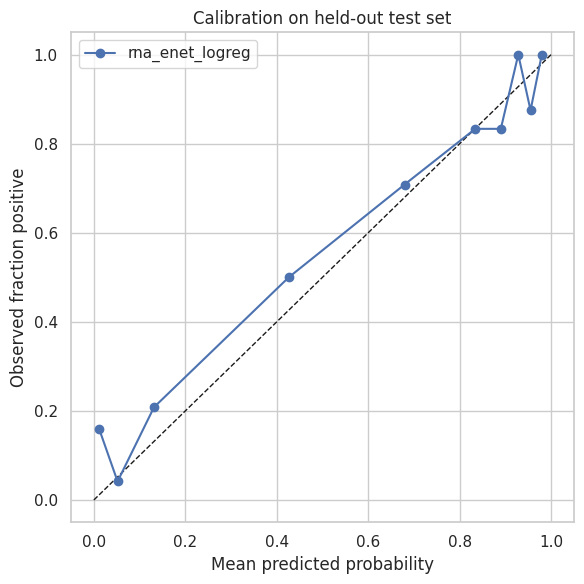

In [30]:
calibration_rows = []
plot_models = [PRIMARY_MODEL_NAME] + ([best_joint_model] if best_joint_model is not None and best_joint_model != PRIMARY_MODEL_NAME else [])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1)

for model_name in plot_models:
    prob = test_prob_store[model_name]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)
    calibration_rows.append(
        {
            "model_name": model_name,
            "brier_score": brier_score_loss(y_test, prob),
        }
    )

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration on held-out test set")
ax.legend()
plt.tight_layout()

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df.round(4))


## 14. Task 2: multiclass TP53 mutation-type prediction with lineage-stratified splitting

This section addresses the assignment's second task: predicting the **type of TP53 mutation** from gene expression profiles.

A literal mutation-type task could try to separate many raw categories such as missense, nonsense, frameshift deletion, frameshift insertion, splice-site, in-frame insertion, and in-frame deletion. In practice, several of these exact categories are rare, so modelling each one separately would create unstable classes. Therefore, I use broader TP53 mutation-type/consequence groups that preserve the main biological distinction while keeping enough samples per class.

For CCLE, the Task 2 classes are:

- `wild_type`: no retained protein-altering TP53 event used for the primary label. This is an operational label, not proof of fully normal p53 biology;
- `missense_or_inframe`: missense or in-frame TP53 alterations, which often preserve protein length but alter amino-acid sequence or local structure;
- `lof_or_splice`: loss-of-function-like events, including truncating, frameshift, nonsense, or splice-related events.

The 3-class formulation evaluates whether RNA expression can distinguish WT, missense/in-frame, and loss-of-function/splice-like TP53 states. Because this still includes WT, the notebook also reports a stricter **mutant-only Task 2** evaluation on held-out TP53-mutant samples only. That stricter report compares `missense_or_inframe` versus `lof_or_splice`, which more directly matches the phrase "type of mutation."

For Task 2, I rebuild the split specifically for mutation-type prediction and stratify by **TP53 mutation-type class x CCLE lineage** where possible. This preserves both mutation-type class balance and major lineage composition across train, validation, and test sets. Rare lineage-by-mutation-type strata are collapsed when necessary; they are not used to make strong per-lineage claims.

Metric note: the strict mutant-only evaluation uses the best 3-class model evaluated only on mutant test samples. If the 3-class model predicts `wild_type` for a mutant sample, that prediction is counted as an error in the metrics. The displayed mutant-only confusion table focuses on the two mutant classes, so the full 3-class confusion matrix should be used when interpreting WT-predicted errors.


In [31]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in CCLE
# ============================================================
# Methodological change from the initial completed version:
#   * Task 2 gets its own train/validation/test split.
#   * The split is stratified by TP53 mutation-type label and CCLE lineage together.
#   * Hyperparameter CV also stratifies by the same label-lineage strata when feasible.
#   * Model selection is by validation macro-F1, not by test performance.

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

TASK2_LABEL_COL = "TP53_task2_label"
TASK2_TEST_SIZE = 0.15
TASK2_VAL_SIZE = 0.15

if TASK2_LABEL_COL not in sample_meta.columns:
    if "mut_type" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["mut_type"].astype(str)
    elif "TP53_event_class" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["TP53_event_class"].fillna("wild_type").astype(str)
    else:
        raise ValueError("Cannot construct CCLE Task 2 label: missing mut_type/TP53_event_class.")

# Final CCLE Task 2 classes from the EDA notebook.
task2_labels = ["wild_type", "missense_or_inframe", "lof_or_splice"]

unexpected_task2 = sorted(set(sample_meta[TASK2_LABEL_COL].dropna().astype(str)) - set(task2_labels))
if unexpected_task2:
    raise ValueError(f"Unexpected CCLE Task 2 labels: {unexpected_task2}")

if lineage_col is None or lineage_col not in sample_meta.columns:
    raise ValueError(
        "Task 2 now requires a CCLE lineage column for label-lineage stratification. "
        "Check the EDA schema and sample metadata."
    )


def make_stable_joint_strata(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

task2_counts = (
    sample_meta[TASK2_LABEL_COL]
    .value_counts()
    .reindex(task2_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

# Task 2 uses all eligible samples but creates a new split that is adaptively stratified by
# mutation-type class and lineage. Rare lineage-type cells are collapsed; no samples are
# dropped solely because a lineage stratum is small.
y2_all = sample_meta[TASK2_LABEL_COL].astype(str)
task2_all_idx = pd.Index(sample_meta.index[y2_all.isin(task2_labels)], name=sample_meta.index.name)
task2_lineage_all = (
    sample_meta.loc[task2_all_idx, lineage_col]
    .astype(str)
    .fillna("missing")
    .replace({"nan": "missing"})
)

task2_strata_all = make_stable_joint_strata(
    labels=y2_all.loc[task2_all_idx],
    groups=task2_lineage_all,
    min_count=2,
    group_name="lineage",
    split_fraction=TASK2_TEST_SIZE,
    min_group_count=15,
)

task2_trainval_idx, task2_test_idx = train_test_split(
    task2_all_idx,
    test_size=TASK2_TEST_SIZE,
    random_state=RNG,
    shuffle=True,
    stratify=task2_strata_all,
)

task2_trainval_idx = pd.Index(task2_trainval_idx, name=sample_meta.index.name)
task2_test_idx = pd.Index(task2_test_idx, name=sample_meta.index.name)

task2_trainval_strata = make_stable_joint_strata(
    labels=y2_all.loc[task2_trainval_idx],
    groups=sample_meta.loc[task2_trainval_idx, lineage_col],
    min_count=2,
    group_name="lineage",
    split_fraction=TASK2_VAL_SIZE / (1.0 - TASK2_TEST_SIZE),
    min_group_count=15,
)

task2_val_fraction_of_trainval = TASK2_VAL_SIZE / (1.0 - TASK2_TEST_SIZE)
task2_train_idx, task2_val_idx = train_test_split(
    task2_trainval_idx,
    test_size=task2_val_fraction_of_trainval,
    random_state=RNG,
    shuffle=True,
    stratify=task2_trainval_strata,
)

task2_train_idx = pd.Index(task2_train_idx, name=sample_meta.index.name)
task2_val_idx = pd.Index(task2_val_idx, name=sample_meta.index.name)
task2_trainval_idx = task2_train_idx.union(task2_val_idx)

# Feature matrices for Task 2.
X2_train = X_joint.loc[task2_train_idx]
X2_val = X_joint.loc[task2_val_idx]
X2_test = X_joint.loc[task2_test_idx]
X2_trainval = X_joint.loc[task2_trainval_idx]

X2_meta_all = sample_meta[[lineage_col]].copy()
X2_meta_all[lineage_col] = X2_meta_all[lineage_col].astype(str).fillna("missing").replace({"nan": "missing"})
X2_meta_train = X2_meta_all.loc[task2_train_idx]
X2_meta_val = X2_meta_all.loc[task2_val_idx]
X2_meta_test = X2_meta_all.loc[task2_test_idx]
X2_meta_trainval = X2_meta_all.loc[task2_trainval_idx]

y2_train = y2_all.loc[task2_train_idx]
y2_val = y2_all.loc[task2_val_idx]
y2_test = y2_all.loc[task2_test_idx]
y2_trainval = y2_all.loc[task2_trainval_idx]

split_task2_counts = pd.concat(
    {
        "train": y2_train.value_counts().reindex(task2_labels),
        "val": y2_val.value_counts().reindex(task2_labels),
        "test": y2_test.value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_lineage_split_counts = pd.concat(
    {
        "train": X2_meta_train[lineage_col].value_counts(),
        "val": X2_meta_val[lineage_col].value_counts(),
        "test": X2_meta_test[lineage_col].value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("CCLE Task 2 class counts:")
display(task2_counts)
print("CCLE Task 2 split counts using label-lineage stratification:")
display(split_task2_counts)
print("CCLE Task 2 lineage split counts, top 20 lineages:")
display(task2_lineage_split_counts.head(20))


def align_multiclass_proba(estimator, X, labels):
    """Return probability columns aligned to a fixed class order."""
    labels = list(labels)
    if hasattr(estimator, "predict_proba"):
        raw = estimator.predict_proba(X)
        est_classes = list(estimator.classes_)
    elif hasattr(estimator, "decision_function"):
        score = np.asarray(estimator.decision_function(X), dtype=float)
        if score.ndim == 1:
            score = np.column_stack([-score, score])
        score = score - np.nanmax(score, axis=1, keepdims=True)
        exp_score = np.exp(score)
        raw = exp_score / np.clip(exp_score.sum(axis=1, keepdims=True), 1e-12, None)
        est_classes = list(estimator.classes_)
    else:
        pred = estimator.predict(X)
        raw = np.zeros((len(pred), len(labels)), dtype=float)
        est_classes = labels
        for i, p in enumerate(pred):
            if p in labels:
                raw[i, labels.index(p)] = 1.0

    out = np.zeros((raw.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


class RNAMulticlassKBestFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe multiclass RNA feature builder using train-fold ANOVA F scores."""

    def __init__(self, rna_cols, k=1000):
        self.rna_cols = rna_cols
        self.k = k

    def fit(self, X, y):
        X_df = self._to_frame(X)
        self.rna_cols_ = list(self.rna_cols)
        X_rna = X_df.loc[:, self.rna_cols_]
        k_eff = min(int(self.k), X_rna.shape[1])

        self.selector_ = SelectKBest(score_func=f_classif, k=k_eff)
        X_selected = self.selector_.fit_transform(X_rna, y)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_selected)

        self.selected_genes_ = np.asarray(self.rna_cols_)[self.selector_.get_support()]
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        X_rna = X_df.loc[:, self.rna_cols_]
        X_selected = self.selector_.transform(X_rna)
        return self.scaler_.transform(X_selected)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_genes_, dtype=object)

    @staticmethod
    def _to_frame(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("RNAMulticlassKBestFeatureBuilder expects a pandas DataFrame")
        return X


def make_task2_rna_pipeline(clf, rna_cols, k=1000):
    return Pipeline(
        steps=[
            ("features", RNAMulticlassKBestFeatureBuilder(rna_cols=rna_cols, k=k)),
            ("clf", clf),
        ]
    )


task2_cv_n = min(CONFIG["cv_splits"], int(y2_train.value_counts().min()))
task2_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=X2_meta_train[lineage_col],
    min_count=task2_cv_n,
    group_name="lineage",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RNG).split(
        np.zeros(len(y2_train)),
        task2_cv_strata,
    )
)

# Each registry entry declares the feature matrix it uses. Lineage is used for
# stratified splitting/auditing only, not as a predictor.
task2_registry = [
    {
        "model_name": "task2_dummy_prior",
        "tier": "baseline",
        "feature_set": "rna",
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    },
    {
        "model_name": "task2_rna_multinomial_logreg",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=8000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000, 2000],
            "clf__C": [0.03, 0.1, 0.3],
            "clf__l1_ratio": [0.0, 0.5],
        },
    },
    {
        "model_name": "task2_rna_linear_svm",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            SVC(
                kernel="linear",
                probability=True,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000],
            "clf__C": [0.03, 0.1, 0.3],
        },
    },
]

task2_feature_sets = {
    "rna": {
        "train": X2_train,
        "val": X2_val,
        "test": X2_test,
        "trainval": X2_trainval,
    },
}

assert all(spec["feature_set"] == "rna" for spec in task2_registry), "Task 2 metadata predictors are disabled; all models must use RNA feature sets."

task2_val_rows = []
task2_test_rows = []
task2_best_estimators = {}
task2_best_params = {}

for spec in task2_registry:
    name = spec["model_name"]
    est = clone(spec["estimator"])
    grid = spec["param_grid"]
    feature_set = spec["feature_set"]
    X_fit = task2_feature_sets[feature_set]["train"]

    if len(grid) > 0:
        search = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="f1_macro",
            cv=task2_cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_fit, y2_train)
        best_est = search.best_estimator_
        best_params = search.best_params_
        best_cv = search.best_score_
    else:
        best_est = est.fit(X_fit, y2_train)
        best_params = {}
        best_cv = np.nan

    val_proba = align_multiclass_proba(best_est, task2_feature_sets[feature_set]["val"], task2_labels)
    val_metrics, _ = evaluate_multiclass(y2_val, val_proba, task2_labels)

    task2_val_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
    )

    # Refit on train + validation using the selected hyperparameters before the one-time test evaluation.
    refit_est = clone(spec["estimator"])
    if len(best_params) > 0:
        refit_est.set_params(**best_params)
    refit_est.fit(task2_feature_sets[feature_set]["trainval"], y2_trainval)

    test_proba = align_multiclass_proba(refit_est, task2_feature_sets[feature_set]["test"], task2_labels)
    test_metrics, test_pred = evaluate_multiclass(y2_test, test_proba, task2_labels)

    task2_test_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
    )

    task2_best_estimators[name] = refit_est
    task2_best_params[name] = best_params

task2_val_results = pd.DataFrame(task2_val_rows).sort_values(
    "val_macro_f1",
    ascending=False,
).reset_index(drop=True)

task2_validation_order = {name: rank for rank, name in enumerate(task2_val_results["model_name"], start=1)}
task2_test_results = pd.DataFrame(task2_test_rows)
task2_test_results["validation_rank"] = task2_test_results["model_name"].map(task2_validation_order)
task2_test_results = task2_test_results.sort_values("validation_rank").reset_index(drop=True)

display(task2_val_results.round(4))
display(task2_test_results.round(4))

best_task2_name = task2_val_results.iloc[0]["model_name"]
best_task2_feature_set = task2_val_results.iloc[0]["feature_set"]
best_task2_est = task2_best_estimators[best_task2_name]
best_task2_test_proba = align_multiclass_proba(
    best_task2_est,
    task2_feature_sets[best_task2_feature_set]["test"],
    task2_labels,
)
_, best_task2_test_pred = evaluate_multiclass(y2_test, best_task2_test_proba, task2_labels)

task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_task2_test_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

task2_report = multiclass_report_df(y2_test, best_task2_test_pred, task2_labels)

print(f"Best CCLE Task 2 model by validation macro-F1: {best_task2_name}")
display(task2_confusion)
display(task2_report.round(4))

# Strict assignment-aligned Task 2: evaluate mutation type among TP53-mutant samples only.
# The model is still the same held-out test model selected above; WT samples are removed only for this metric.
ccle_task2_mutant_labels = ["missense_or_inframe", "lof_or_splice"]
ccle_task2_mutant_mask = pd.Series(y2_test).astype(str).ne("wild_type").to_numpy()
ccle_task2_mutant_y_true = pd.Series(y2_test).astype(str).to_numpy()[ccle_task2_mutant_mask]
ccle_task2_mutant_y_pred = pd.Series(best_task2_test_pred).astype(str).to_numpy()[ccle_task2_mutant_mask]

ccle_task2_mutant_only_metrics = pd.DataFrame([
    {
        "cohort": "CCLE",
        "evaluation": "mutant_only_task2",
        "best_model": best_task2_name,
        "n_mutant_test_samples": int(ccle_task2_mutant_mask.sum()),
        "labels": json.dumps(ccle_task2_mutant_labels),
        "accuracy": accuracy_score(ccle_task2_mutant_y_true, ccle_task2_mutant_y_pred),
        "balanced_accuracy": balanced_accuracy_score(ccle_task2_mutant_y_true, ccle_task2_mutant_y_pred),
        "macro_f1": f1_score(
            ccle_task2_mutant_y_true,
            ccle_task2_mutant_y_pred,
            average="macro",
            labels=ccle_task2_mutant_labels,
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            ccle_task2_mutant_y_true,
            ccle_task2_mutant_y_pred,
            average="weighted",
            labels=ccle_task2_mutant_labels,
            zero_division=0,
        ),
    }
])

ccle_task2_mutant_only_confusion = pd.DataFrame(
    confusion_matrix(
        ccle_task2_mutant_y_true,
        ccle_task2_mutant_y_pred,
        labels=ccle_task2_mutant_labels,
    ),
    index=[f"true_{x}" for x in ccle_task2_mutant_labels],
    columns=[f"pred_{x}" for x in ccle_task2_mutant_labels],
)

ccle_task2_mutant_only_report = multiclass_report_df(
    ccle_task2_mutant_y_true,
    ccle_task2_mutant_y_pred,
    ccle_task2_mutant_labels,
)

print("Strict CCLE Task 2 mutant-only evaluation: missense/in-frame vs LOF/splice")
display(ccle_task2_mutant_only_metrics.round(4))
display(ccle_task2_mutant_only_confusion)
display(ccle_task2_mutant_only_report.round(4))


Using adaptive TP53-label x lineage strata: 71 strata; rare lineage threshold=15. No samples dropped.
Using adaptive TP53-label x lineage strata: 71 strata; rare lineage threshold=15. No samples dropped.
CCLE Task 2 class counts:


,n
TP53_task2_label,
wild_type,621
missense_or_inframe,625
lof_or_splice,362


CCLE Task 2 split counts using label-lineage stratification:


,train,val,test
TP53_task2_label,,,
wild_type,434,93,94
missense_or_inframe,436,94,95
lof_or_splice,254,55,53


CCLE Task 2 lineage split counts, top 20 lineages:


...

Strict CCLE Task 2 mutant-only evaluation: missense/in-frame vs LOF/splice


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,cohort,evaluation,best_model,n_mutant_test_samples,labels,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,CCLE,mutant_only_task2,task2_rna_multinomial_logreg,148,"[""missense_or_inframe"", ""lof_or_splice""]",0.8176,0.8162,0.8525,0.8552


,pred_missense_or_inframe,pred_lof_or_splice
true_missense_or_inframe,78,6
true_lof_or_splice,8,43


,class,precision,recall,f1-score,support
0,missense_or_inframe,0.9070,0.8211,0.8619,95.0
1,lof_or_splice,0.8776,0.8113,0.8431,53.0
2,micro avg,0.8963,0.8176,0.8551,148.0
3,macro avg,0.8923,0.8162,0.8525,148.0
4,weighted avg,0.8964,0.8176,0.8552,148.0


## 15. CCLE final project conclusions

The CCLE analysis explicitly separates the two assignment tasks.

**Task 1** predicts binary TP53 nonsynonymous/protein-altering mutation status from RNA expression. This means DNA-level TP53 mutation status, not TP53 RNA expression level. The primary models are RNA-only. Lineage is used for stratification, auditing, subgroup analysis, and grouped robustness checks, but not as a predictor in the main RNA model.

**Task 2** predicts coarse TP53 mutation-type/consequence classes from RNA expression. The 3-class model distinguishes `wild_type`, `missense_or_inframe`, and `lof_or_splice`. Here `wild_type` means no retained protein-altering TP53 mutation annotation; it does not prove fully normal p53 function. To address a stricter reading of the assignment, the notebook also reports a mutant-only Task 2 evaluation comparing `missense_or_inframe` versus `lof_or_splice` only among TP53-mutant held-out samples.

The CCLE Task 2 results are encouraging. The best 3-class RNA model reaches approximately 0.82 test accuracy, 0.82 balanced accuracy, 0.81 macro-F1, and 0.93 one-vs-rest macro AUROC. The strict mutant-only Task 2 evaluation gives approximately 0.85 macro-F1 for distinguishing missense/in-frame from LOF/splice-like events. These results support the conclusion that RNA expression carries information about broad TP53 mutation consequences, not only binary TP53 mutation status.

The biological interpretation remains cautious. Important RNA features include plausible TP53 pathway genes and p53-response genes. The TP53 target-gene list is a predefined p53-response reference panel, not a list of mutated genes and not a list discovered from the dataset. Feature importance should not be interpreted causally. A gene may be predictive because it is downstream of TP53, correlated with proliferation or DNA-damage response, associated with lineage, or linked to other cancer-context effects. The lineage-stratified split, per-lineage checks, metadata audits, and grouped evaluation are included specifically to reduce and assess this confounding risk.

Overall, the CCLE part of the project supports the main claim that TP53 mutation status is predictable from RNA expression, while also showing that mutation-type prediction is feasible but more challenging and should be evaluated with macro-averaged metrics and per-class reports.


## 16. Save outputs for reporting


In [32]:
save_df_map = {
    "ccle_mrna_first_validation_results.csv": val_results,
    "ccle_mrna_first_test_results.csv": test_results,
    "ccle_mrna_first_main_comparison.csv": main_comparison,
    "ccle_mrna_first_bootstrap_summary.csv": bootstrap_summary,
    "ccle_mrna_first_primary_coefficients.csv": primary_coef_df,
}

for fname, df in save_df_map.items():
    df.to_csv(PROC / fname, index=False)


if ccle_ablation_table is not None:
    ccle_ablation_table.to_csv(PROC / "ccle_mrna_first_ablation_table.csv", index=False)
if ccle_ablation_table_with_ensemble is not None:
    ccle_ablation_table_with_ensemble.to_csv(PROC / "ccle_mrna_first_ablation_table_with_ensemble.csv", index=False)
if isinstance(ccle_ablation_cv_results, pd.DataFrame) and len(ccle_ablation_cv_results) > 0:
    ccle_ablation_cv_results.to_csv(PROC / "ccle_mrna_first_ablation_cv_results.csv", index=False)
if ccle_final_model_comparison_with_ablations is not None:
    ccle_final_model_comparison_with_ablations.to_csv(PROC / "ccle_mrna_first_final_comparison_with_ablations.csv", index=False)

if joint_coef_df is not None:
    joint_coef_df.to_csv(PROC / "ccle_mrna_first_joint_coefficients.csv", index=False)
if per_lineage_primary is not None and len(per_lineage_primary) > 0:
    per_lineage_primary.to_csv(PROC / "ccle_mrna_first_per_lineage_primary.csv", index=False)
if grouped_cv_folds is not None:
    grouped_cv_folds.to_csv(PROC / "ccle_mrna_first_grouped_cv_folds.csv", index=False)
if grouped_cv_summary is not None:
    grouped_cv_summary.to_csv(PROC / "ccle_mrna_first_grouped_cv_summary.csv")
if outlier_sensitivity is not None:
    outlier_sensitivity.to_csv(PROC / "ccle_mrna_first_outlier_sensitivity.csv", index=False)
if label_sensitivity is not None:
    label_sensitivity.to_csv(PROC / "ccle_mrna_first_label_sensitivity.csv", index=False)
if calibration_df is not None:
    calibration_df.to_csv(PROC / "ccle_mrna_first_calibration.csv", index=False)


# Task 2 outputs are created only after the Task 2 section has run.
if "task2_counts" in globals():
    task2_counts.to_csv(PROC / "ccle_task2_class_counts.csv")
if "split_task2_counts" in globals():
    split_task2_counts.to_csv(PROC / "ccle_task2_split_class_counts.csv")
if "task2_val_results" in globals():
    task2_val_results.to_csv(PROC / "ccle_task2_validation_results.csv", index=False)
if "task2_test_results" in globals():
    task2_test_results.to_csv(PROC / "ccle_task2_test_results.csv", index=False)
if "task2_confusion" in globals():
    task2_confusion.to_csv(PROC / "ccle_task2_confusion_matrix.csv")
if "task2_report" in globals():
    task2_report.to_csv(PROC / "ccle_task2_classification_report.csv", index=False)
if "ccle_task2_mutant_only_metrics" in globals():
    ccle_task2_mutant_only_metrics.to_csv(PROC / "ccle_task2_mutant_only_metrics.csv", index=False)
if "ccle_task2_mutant_only_confusion" in globals():
    ccle_task2_mutant_only_confusion.to_csv(PROC / "ccle_task2_mutant_only_confusion_matrix.csv")
if "ccle_task2_mutant_only_report" in globals():
    ccle_task2_mutant_only_report.to_csv(PROC / "ccle_task2_mutant_only_classification_report.csv", index=False)

final_predictions = pd.DataFrame(index=X_test.index)
final_predictions["y_true"] = y_test
for model_name, prob in test_prob_store.items():
    final_predictions[f"prob__{model_name}"] = prob
save_parquet_with_id(final_predictions, "ccle_mrna_first_test_predictions.parquet")

run_summary = {
    "primary_label": primary_label,
    "primary_model_name": PRIMARY_MODEL_NAME,
    "best_metadata_model": best_meta_model,
    "best_joint_model": best_joint_model,
    "rna_gene_count": len(rna_cols),
    "recommended_meta_cols": recommended_meta_cols,
    "main_models": main_models,
    "has_ablation_table": bool(ccle_ablation_table is not None),
    "has_tp53_event_class": "TP53_event_class" in sample_meta.columns,
    "has_tp53_mut_ambiguous": "TP53_mut_ambiguous" in sample_meta.columns,
    "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()) if "TP53_mut_ambiguous" in sample_meta.columns else None,
    "task2_label": TASK2_LABEL_COL if "TASK2_LABEL_COL" in globals() else None,
    "task2_classes": task2_labels if "task2_labels" in globals() else None,
    "best_task2_model": best_task2_name if "best_task2_name" in globals() else None,
    "has_task2_mutant_only_metrics": bool("ccle_task2_mutant_only_metrics" in globals()),
}
with open(PROC / "ccle_mrna_first_run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved revised mRNA-first modeling artifacts to:", PROC.resolve())


Saved revised mRNA-first modeling artifacts to: /kaggle/working/processed


# TCGA Pan-Cancer EDA for Predicting TP53 Mutation Status from RNA Expression

## Objective

Explore whether **TP53 nonsynonymous mutation status** can be predicted from **TCGA RNA expression**.

Here, TP53 mutation status means the somatic mutation annotation for the `TP53` gene, not the expression level of TP53 itself.

This EDA is designed to support the modelling notebook by defining a clean, leakage-aware TCGA cohort and identifying the major modelling risks.

## Main EDA goals

1. Load and inspect raw TCGA/Xena RNA, mutation, and phenotype files.
2. Define a sample-level TP53 nonsynonymous mutation label.
3. Use phenotype/sample-derived patient IDs as the canonical patient identifiers.
4. Audit tumour/normal status, cancer-type composition, duplicate patients, and ambiguous TP53 annotations.
5. Define a final modelling cohort that matches the modelling notebook.
6. Check RNA missingness, dimensionality, variance structure, and broad PCA patterns.
7. Identify leakage and confounding risks before modelling.

## Key warning

In pan-cancer TCGA data, cancer type can strongly confound TP53 prediction because cancer type affects both TP53 mutation prevalence and RNA expression. The modelling notebook therefore uses cancer-type-aware stratification and cancer-type-grouped evaluation. A cancer-type-only baseline would be a useful additional confounding diagnostic, but the submitted primary models intentionally remain RNA-only.


In [33]:
import gzip
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("notebook")

RANDOM_STATE = 42
TOP_VAR_GENES_FOR_PCA = 2000

# Keep TCGA RNA EDA lightweight by default. The full final-cohort RNA matrix is loaded once in the modeling section.
RUN_TCGA_RNA_EDA = False
TCGA_MODEL_RNA_FEATURE_CAP = 3000  # stream-select top-variance genes before materializing the TCGA RNA matrix
TCGA_RNA_CHUNKSIZE = 750


## File discovery

The notebook searches common Kaggle, Colab, local, and sandbox locations for the raw TCGA/Xena files. If your files are somewhere else, add that directory to `SEARCH_ROOTS` or set the paths manually.

In [34]:
SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/cameroncaputa/tp53-prediction"),
    Path("/kaggle/input/tp53-prediction"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("./data"),
    Path("tp53_completed_notebooks"),
]


def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file. Tried:\n" + "\n".join(tried))
    return None


RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "tcga_RSEM_gene_tpm.gz",
    "*tcga_RSEM_gene_tpm*",
], required=True)

MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3.v0.2.8.PUBLIC.xena*",
    "*mc3*PUBLIC*xena*",
], required=True)

PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=True)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

print("RNA_PATH:", RNA_PATH)
print("MUT_PATH:", MUT_PATH)
print("PHENO_PATH:", PHENO_PATH)
print("TP53_TARGETS_PATH:", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH:", GENE_ANNOTATION_PATH)

RNA_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm
MUT_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena
PHENO_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp
TP53_TARGETS_PATH: /kaggle/input/datasets/cameroncaputa/tp53-prediction/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH: None


## Helper functions

These functions standardize TCGA sample and patient identifiers and derive tumour/normal sample type from the TCGA barcode.

In [35]:
def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        line = f.readline()
    return "	" if line.count("	") >= line.count(",") else ","


def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None


def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))


def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))


def normalize_sample_id(x):
    """Return TCGA sample-level barcode, usually first four barcode fields."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s


def normalize_patient_id(x):
    """Return TCGA patient-level barcode, usually first three barcode fields."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s


def tcga_sample_type_code(barcode):
    """Return TCGA two-digit sample type code from the fourth barcode field."""
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan


TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

SAMPLE_PRIORITY = {
    "01": 0,  # primary solid tumour
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}


def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan


def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

## Load raw files and inspect schema

In [36]:
RNA_SEP = sniff_sep(RNA_PATH)
MUT_SEP = sniff_sep(MUT_PATH)
PHENO_SEP = sniff_sep(PHENO_PATH)

# Read mutation and phenotype fully. RNA is read fully in the next section because we need expression values for EDA.
mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
pheno_raw = pd.read_csv(PHENO_PATH, sep=PHENO_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=5, low_memory=False)

print("Mutation shape:", mut_raw.shape)
print("Phenotype shape:", pheno_raw.shape)
print("RNA header preview shape:", rna_header.shape)
print("Mutation columns:", mut_raw.columns.tolist()[:30])
print("Phenotype columns:", pheno_raw.columns.tolist()[:30])
print("RNA first columns:", rna_header.columns.tolist()[:8])

display(mut_raw.head())
display(pheno_raw.head())
display(rna_header.head())

Mutation shape: (2907335, 12)
Phenotype shape: (12591, 34)
RNA header preview shape: (5, 10536)
Mutation columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
Phenotype columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'treatment_outcome_first_course', 'margin_status', 'residual_tumor', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
0,TCGA-02-0003-01,10,123810032,123810032,C,T,TACC2,Missense_Mutation,p.T38M,0.88,NaN,benign(0.335)
1,TCGA-02-0003-01,10,133967449,133967449,C,T,JAKMIP3,Silent,p.D723D,0.79,NaN,NaN
2,TCGA-02-0003-01,11,124489539,124489539,G,A,PANX3,Missense_Mutation,p.R296Q,0.41,tolerated(0.37),benign(0.001)
3,TCGA-02-0003-01,11,47380512,47380512,G,T,SPI1,Missense_Mutation,p.P127T,0.50,tolerated(0.08),benign(0.093)
4,TCGA-02-0003-01,11,89868837,89868837,C,T,NAALAD2,Missense_Mutation,p.R65C,0.51,deleterious(0.01),benign(0.034)


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,58,MALE,WHITE,Stage II,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-21496,Dead,WITH TUMOR,NaN,1355,NaN,Distant Metastasis,Peritoneal Surfaces,NaN,754,Complete Remission/Response,NaN,NaN,1,1355,1,1355,1,754,1,754,NaN
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,44,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2004,NaN,-16090,Dead,WITH TUMOR,NaN,1677,NaN,Distant Metastasis,Soft Tissue,NaN,289,Progressive Disease,NaN,NaN,1,1677,1,1677,NaN,NaN,1,289,NaN
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,23,FEMALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2008,NaN,-8624,Alive,WITH TUMOR,2091,NaN,NaN,Distant Metastasis,Lung,NaN,53,Complete Remission/Response,NaN,NaN,0,2091,0,2091,1,53,1,53,NaN
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,23,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-8451,Dead,WITH TUMOR,NaN,423,NaN,Locoregional Recurrence,Peritoneal Surfaces,NaN,126,Progressive Disease,NaN,NaN,1,423,1,423,NaN,NaN,1,126,NaN
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,30,MALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-11171,Dead,WITH TUMOR,NaN,365,NaN,Locoregional Recurrence,"Other, specify",vena cava thrombus,50,Progressive Disease,NaN,NaN,1,365,1,365,NaN,NaN,1,50,NaN


,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01,TCGA-44-6778-01,TCGA-F4-6854-01,TCGA-AB-2863-03,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-R6-A8WC-01,TCGA-DX-A3U8-01,TCGA-GL-8500-01,TCGA-E2-A153-11,TCGA-BR-A4J6-01,TCGA-EJ-7125-01,TCGA-IN-7808-01,TCGA-L5-A4OH-01,TCGA-RP-A695-06,TCGA-AX-A3G6-01,TCGA-B9-A8YH-01,TCGA-E1-A7YI-01,TCGA-PC-A5DM-01,TCGA-BR-A4QL-01,TCGA-CH-5751-01,TCGA-A2-A3XX-01,TCGA-DQ-5624-01,TCGA-KK-A7B3-01,TCGA-DQ-7591-01,TCGA-06-5412-01,TCGA-BP-4989-01,TCGA-EJ-8468-01,TCGA-CZ-5459-01,TCGA-D5-5538-01,TCGA-56-8305-01,TCGA-CZ-5468-11,TCGA-BH-A0BQ-11,TCGA-4X-A9FA-01,TCGA-DD-AAW0-01,TCGA-AA-3511-01,TCGA-Z7-A8R5-01,TCGA-CZ-4863-11,TCGA-39-5031-01,TCGA-ZG-A8QW-01,TCGA-DU-7302-01,TCGA-DJ-A3UX-01,TCGA-ZN-A9VQ-01,TCGA-EI-6512-01,TCGA-J4-A83K-01,TCGA-EE-A17X-06,TCGA-HZ-7922-01,TCGA-DD-AACA-02,TCGA-DD-AACA-01,TCGA-D3-A8GD-06,TCGA-13-1485-01,TCGA-QG-A5YX-01,TCGA-ZG-A9MC-01,TCGA-DU-A7TI-01,TCGA-A3-3335-01,TCGA-BR-8372-01,TCGA-HC-7742-01,TCGA-DD-A3A6-11,TCGA-64-1679-01,TCGA-CV-5976-01,TCGA-25-1315-01,TCGA-2G-AAFZ-01,TCGA-LN-A4MQ-01,TCGA-CV-6948-01,TCGA-K7-AAU7-01,TCGA-CJ-6028-01,TCGA-B6-A0RL-01,TCGA-CZ-5456-01,TCGA-EL-A3D0-01,TCGA-EM-A22Q-01,TCGA-49-6744-01,TCGA-L5-A4ON-01,TCGA-FS-A1ZF-06,TCGA-ZN-A9VU-01,TCGA-Q3-A5QY-01,TCGA-AJ-A3BI-01,TCGA-W2-A7UY-01,TCGA-BH-A204-11,TCGA-E3-A3E2-01,TCGA-FB-A545-01,TCGA-44-2657-11,TCGA-G4-6320-01,TCGA-EB-A41A-01,TCGA-55-6982-01,TCGA-RC-A7SH-01,TCGA-CC-A3MA-01,TCGA-DD-A3A5-11,TCGA-RC-A7SB-01,TCGA-CM-6164-01,TCGA-ET-A3BW-01,TCGA-09-0369-01,TCGA-E2-A2P6-01,TCGA-VD-A8KF-01,TCGA-EL-A4JZ-01,...,TCGA-AB-2833-03,TCGA-EE-A2MF-06,TCGA-D8-A1XR-01,TCGA-50-5072-01,TCGA-AB-2964-03,TCGA-HI-7171-01,TCGA-AR-A0TQ-01,TCGA-G3-A3CG-01,TCGA-BB-7863-01,TCGA-DU-6406-01,TCGA-BR-4255-01,TCGA-AA-3675-01,TCGA-JV-A75J-01,TCGA-DD-A1ED-01,TCGA-BH-A18P-01,TCGA-VD-A8KJ-01,TCGA-A6-6782-01,TCGA-BR-A4CR-01,TCGA-2Y-A9H8-01,TCGA-61-1721-01,TCGA-56-8628-01,TCGA-2Y-A9GT-01,TCGA-EO-A3AZ-01,TCGA-3N-A9WD-06,TCGA-29-1784-01,TCGA-2L-AAQI-01,TCGA-HS-A5N9-01,TCGA-VS-A9UT-01,TCGA-E2-A15O-01,TCGA-50-5045-01,TCGA-DA-A95W-06,TCGA-BP-4332-01,TCGA-AO-A12C-01,TCGA-86-8674-01,TCGA-CZ-5451-11,TCGA-FF-8043-01,TCGA-P3-A5Q5-01,TCGA-N8-A4PQ-01,TCGA-50-8457-01,TCGA-ZJ-AAX8-01,TCGA-OL-A97C-01,TCGA-18-3416-01,TCGA-B8-4146-01,TCGA-AB-2937-03,TCGA-56-7222-11,TCGA-68-7755-01,TCGA-EE-A2GN-06,TCGA-V1-A9ZR-01,TCGA-2J-AABK-01,TCGA-EJ-A6RC-01,TCGA-EL-A3GP-01,TCGA-D9-A4Z6-06,TCGA-E2-A15K-11,TCGA-06-0743-01,TCGA-H2-A3RI-01,TCGA-21-5787-01,TCGA-BJ-A18Z-01,TCGA-D7-A6EX-01,TCGA-TM-A84B-01,TCGA-OR-A5K0-01,TCGA-FY-A4B4-01,TCGA-BH-A18G-01,TCGA-13-0725-01,TCGA-B6-A0IA-01,TCGA-A8-A090-01,TCGA-BB-4217-01,TCGA-5T-A9QA-01,TCGA-TN-A7HJ-01,TCGA-AN-A0XT-01,TCGA-TS-A8AS-01,TCGA-J4-8198-01,TCGA-DU-A76O-01,TCGA-EE-A29L-06,TCGA-4X-A9F9-01,TCGA-C5-A1BJ-01,TCGA-G2-AA3C-01,TCGA-HU-8602-01,TCGA-CR-6470-01,TCGA-CH-5768-01,TCGA-2H-A9GM-01,TCGA-XH-A853-01,TCGA-CM-4751-01,TCGA-AO-A0J4-01,TCGA-55-6985-11,TCGA-YL-A9WK-01,TCGA-77-6844-01,TCGA-IN-AB1X-11,TCGA-A2-A0YK-01,TCGA-18-3414-01,TCGA-13-1481-01,TCGA-DJ-A2QC-01,TCGA-A8-A09K-01,TCGA-61-1907-01,TCGA-IB-7885-01,TCGA-95-7947-01,TCGA-VQ-AA6F-01,TCGA-BR-8588-01,TCGA-24-2254-01,TCGA-DD-A115-01,TCGA-FV-A3I0-11
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6873,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.8599,-0.4521,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-4.2934,-3.6259,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-2.5479,-1.2481,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.965800,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6193,-1.3921,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-2.0529,-9.9658,-9.9658,-3.1714,-3.3076,-9.9658,-5.0116,1.0711,-2.1140,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-0.9686,0.1257,-3.4580,-4.2934,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-0.4131,-9.9658,-9.9658,-9.9658,-

In [37]:
MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Amino_Acid_Change"], "Amino_Acid_Change", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

PHENO_SAMPLE_COL = find_col(
    pheno_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "phenotype sample column",
)
PHENO_PATIENT_COL = find_col(
    pheno_raw,
    ["_PATIENT", "patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "phenotype patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    pheno_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen phenotype sample column:", PHENO_SAMPLE_COL)
print("Chosen phenotype patient column:", PHENO_PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect', 'Amino_Acid_Change']
Chosen phenotype sample column: sample
Chosen phenotype patient column: _PATIENT
Chosen cancer type column: cancer type abbreviation


## Identifier and schema decisions

- RNA matrix orientation is inferred from the header.
- Mutation and phenotype identifiers are standardized to sample-level TCGA barcodes.
- Patient ID should come from the phenotype table when available, falling back to the sample barcode.
- TP53 mutation-derived patient IDs are **not** allowed to overwrite patient IDs for mutation-negative samples.
- Tumour/normal status is derived from the TCGA sample-type code in the fourth barcode field.

## Load RNA expression matrix

The expected Xena RNA layout is usually genes as rows and samples as columns. The code below detects that layout and converts the matrix to samples × genes.

One common source of confusion is that the first column may be named `sample` even when the entries are actually gene IDs. The orientation check resolves this before modelling.


In [38]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}
    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    return "gene_x_sample"


RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

print("Inferred RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)


def scan_rna_axis_without_values(path, sep, orientation):
    """Return RNA sample IDs and feature count without materializing the full matrix."""
    header = pd.read_csv(path, sep=sep, nrows=0, low_memory=False)
    first_col = header.columns[0]

    if orientation == "gene_x_sample":
        sample_ids = pd.Index([normalize_sample_id(c) for c in header.columns[1:]], name="sample_id")
        feature_preview = []
        n_features = 0
        for chunk in pd.read_csv(path, sep=sep, usecols=[first_col], chunksize=50000, low_memory=False):
            if len(feature_preview) < 10:
                feature_preview.extend(chunk[first_col].astype(str).head(10 - len(feature_preview)).tolist())
            n_features += len(chunk)
        return sample_ids, pd.Index(feature_preview, name="feature_preview"), int(n_features)

    # sample x gene: first column contains sample IDs; feature IDs are the remaining headers.
    sample_ids = []
    for chunk in pd.read_csv(path, sep=sep, usecols=[first_col], chunksize=50000, low_memory=False):
        sample_ids.extend(chunk[first_col].map(normalize_sample_id).astype(str).tolist())
    feature_ids = pd.Index(header.columns[1:].astype(str), name="feature_id")
    return pd.Index(sample_ids, name="sample_id"), feature_ids[:10], int(len(feature_ids))


rna_available_samples, rna_feature_preview, rna_feature_count_estimate = scan_rna_axis_without_values(
    RNA_PATH,
    RNA_SEP,
    RNA_ORIENTATION,
)
rna_available_samples = pd.Index(rna_available_samples.astype(str), name="sample_id")
n_duplicate_rna_samples = int(rna_available_samples.duplicated().sum())
if n_duplicate_rna_samples > 0:
    print(f"Warning: {n_duplicate_rna_samples} duplicate normalized RNA sample IDs. Keeping first occurrence for EDA/cohort construction.")
    rna_available_samples = rna_available_samples[~rna_available_samples.duplicated(keep="first")]

print("Number of RNA-available samples:", len(rna_available_samples))
print("Estimated RNA feature count:", rna_feature_count_estimate)
print("Example RNA-available samples:", rna_available_samples[:5].tolist())
print("RNA feature preview:", list(rna_feature_preview[:10]))


Inferred RNA orientation: gene_x_sample
RNA first column: sample
Number of RNA-available samples: 10535
Estimated RNA feature count: 60498
Example RNA-available samples: ['TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01']
RNA feature preview: ['ENSG00000242268.2', 'ENSG00000259041.1', 'ENSG00000270112.3', 'ENSG00000167578.16', 'ENSG00000278814.1', 'ENSG00000078237.5', 'ENSG00000269416.5', 'ENSG00000263642.1', 'ENSG00000146083.11', 'ENSG00000158486.13']


In [39]:
# Lightweight RNA matrix QC without loading all expression values.
rna_qc_summary = pd.Series({
    "n_rna_available_samples": len(rna_available_samples),
    "estimated_n_rna_features": int(rna_feature_count_estimate),
    "duplicated_normalized_sample_ids_removed": int(n_duplicate_rna_samples),
    "orientation": RNA_ORIENTATION,
    "full_rna_eda_loaded": bool(RUN_TCGA_RNA_EDA),
}, name="value")

display(rna_qc_summary.to_frame())
print("Skipping full TCGA expression-matrix QC by default to prevent Kaggle kernel OOM. The modeling section loads a streamed, feature-capped final-cohort RNA matrix once.")


,value
n_rna_available_samples,10535
estimated_n_rna_features,60498
duplicated_normalized_sample_ids_removed,0
orientation,gene_x_sample
full_rna_eda_loaded,False


Skipping full TCGA expression-matrix QC by default to prevent Kaggle kernel OOM. The modeling section loads a streamed, feature-capped final-cohort RNA matrix once.


## TP53 mutation label construction

The primary label is `TP53_mut_nonsyn`: whether a sample has at least one nonsynonymous / protein-altering TP53 mutation.

This is preferred over using any TP53 row because synonymous and ambiguous TP53 annotations should not be treated as equivalent to protein-altering TP53 mutations.

This label is not TP53 expression level. It is a DNA/somatic mutation label derived from mutation annotations. Samples without retained protein-altering TP53 events are treated as WT/non-protein-altering for this task, but that does not guarantee fully normal p53 pathway function.


In [40]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}


def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"


tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows[[MUT_SAMPLE_COL, "sample_id", "patient_id", "effect_text", "tp53_event_class"]].head())
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))

TP53 mutation rows: 3729


,sample,sample_id,patient_id,effect_text,tp53_event_class
19,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,Missense_Mutation | p.R282W,missense
20,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,Missense_Mutation | p.H178Q,missense
80,TCGA-02-0033-01,TCGA-02-0033-01,TCGA-02-0033,Missense_Mutation | p.R248Q,missense
211,TCGA-02-0055-01,TCGA-02-0055-01,TCGA-02-0055,Missense_Mutation | p.V216M,missense
363,TCGA-02-2483-01,TCGA-02-2483-01,TCGA-02-2483,Missense_Mutation | p.R273H,missense


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


In [41]:
tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("Samples with any TP53 mutation row:", len(tp53_sample))
display(tp53_sample.head())
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].sum().to_frame("n_samples"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("fraction_among_tp53_row_samples"))

Samples with any TP53 mutation row: 3325


,sample_id,patient_id,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_event_classes,example_effects,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,Missense_Mutation | p.R282W; Missense_Mutation...,1,0,0
1,TCGA-02-0033-01,TCGA-02-0033,1,True,True,False,1,Missense_Mutation | p.R248Q,1,0,0
2,TCGA-02-0055-01,TCGA-02-0055,1,True,True,False,1,Missense_Mutation | p.V216M,1,0,0
3,TCGA-02-2483-01,TCGA-02-2483,1,True,True,False,1,Missense_Mutation | p.R273H,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,Missense_Mutation | p.R248Q; Missense_Mutation...,1,0,0


,n_samples
TP53_mut_nonsyn,3270
TP53_mut_ambiguous,18
has_mixed_tp53_annotation,8


,fraction_among_tp53_row_samples
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


In [42]:
# Task 2 sample-level mutation-type label audit.
# A sample may have more than one TP53 row, so choose a primary event by biological severity.
TCGA_TASK2_PRIORITY = {
    "truncating": 7,
    "splice": 6,
    "missense": 5,
    "inframe": 4,
    "protein_altering": 3,
    "synonymous": 2,
    "other_or_unknown": 1,
    "unknown": 0,
}

tp53_rows["task2_priority"] = (
    tp53_rows["tp53_event_class"]
    .map(TCGA_TASK2_PRIORITY)
    .fillna(0)
    .astype(int)
)

tp53_primary_event = (
    tp53_rows
    .sort_values(["sample_id", "task2_priority"], ascending=[True, False])
    .drop_duplicates("sample_id")
    .set_index("sample_id")["tp53_event_class"]
    .rename("tp53_primary_event_class")
)

tp53_nonsyn_class_count = (
    tp53_rows.loc[tp53_rows["is_tp53_nonsyn"]]
    .groupby("sample_id")["tp53_event_class"]
    .nunique()
    .rename("n_unique_tp53_nonsyn_event_classes")
)

tp53_sample = tp53_sample.merge(
    tp53_primary_event.reset_index(),
    on="sample_id",
    how="left",
)

tp53_sample = tp53_sample.merge(
    tp53_nonsyn_class_count.reset_index(),
    on="sample_id",
    how="left",
    suffixes=("", "_nonsyn_only"),
)

if "n_unique_tp53_nonsyn_event_classes_nonsyn_only" in tp53_sample.columns:
    tp53_sample["n_unique_tp53_nonsyn_event_classes"] = tp53_sample[
        "n_unique_tp53_nonsyn_event_classes_nonsyn_only"
    ].fillna(0).astype(int)
    tp53_sample = tp53_sample.drop(columns=["n_unique_tp53_nonsyn_event_classes_nonsyn_only"])

print("Sample-level primary TP53 event classes before final cohort filtering:")
display(tp53_primary_event.value_counts().rename_axis("tp53_primary_event_class").to_frame("n_samples"))


Sample-level primary TP53 event classes before final cohort filtering:


,n_samples
tp53_primary_event_class,
missense,2069
truncating,900
splice,230
inframe,71
synonymous,45
other_or_unknown,10


## Phenotype setup

This is the key fix relative to the earlier EDA: patient IDs come from phenotype/sample information, not from the TP53 mutation table. If patient ID were taken only from TP53 mutation rows, most TP53-wild-type samples would incorrectly appear to have missing patient IDs.

In [43]:
pheno = pheno_raw.copy()
pheno["sample_id"] = pheno[PHENO_SAMPLE_COL].map(normalize_sample_id)

if PHENO_PATIENT_COL is not None:
    pheno["patient_id"] = pheno[PHENO_PATIENT_COL].where(
        pheno[PHENO_PATIENT_COL].notna(),
        pheno["sample_id"].map(normalize_patient_id),
    )
else:
    pheno["patient_id"] = pheno["sample_id"].map(normalize_patient_id)

pheno["patient_id"] = pheno["patient_id"].fillna(pheno["sample_id"].map(normalize_patient_id))
pheno["sample_type_code"] = pheno["sample_id"].map(tcga_sample_type_code)
pheno["sample_type_label"] = pheno["sample_id"].map(tcga_sample_type_label)
pheno["is_tumor_sample"] = pheno["sample_id"].map(is_tcga_tumor_sample)

# Prevent row multiplication during merge.
pheno = pheno.sort_values(["sample_id", "patient_id"]).drop_duplicates(subset="sample_id", keep="first").copy()

print("Phenotype rows after sample-level dedup:", len(pheno))
print("Unique phenotype samples:", pheno["sample_id"].nunique())
print("Unique phenotype patients:", pheno["patient_id"].nunique())
print("Missing patient IDs:", int(pheno["patient_id"].isna().sum()))
print("Missing cancer type:", int(pheno[CANCER_TYPE_COL].isna().sum()))

display(
    pheno[[
        PHENO_SAMPLE_COL,
        "sample_id",
        "patient_id",
        "sample_type_code",
        "sample_type_label",
        "is_tumor_sample",
        CANCER_TYPE_COL,
    ]].head()
)

display(pheno["sample_type_label"].value_counts(dropna=False).to_frame("n_samples"))

Phenotype rows after sample-level dedup: 12591
Unique phenotype samples: 12591
Unique phenotype patients: 11081
Missing patient IDs: 0
Missing cancer type: 0


,sample,sample_id,patient_id,sample_type_code,sample_type_label,is_tumor_sample,cancer type abbreviation
2918,TCGA-02-0001-01,TCGA-02-0001-01,TCGA-02-0001,01,Primary Solid Tumor,True,GBM
2919,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,01,Primary Solid Tumor,True,GBM
2920,TCGA-02-0006-01,TCGA-02-0006-01,TCGA-02-0006,01,Primary Solid Tumor,True,GBM
2921,TCGA-02-0007-01,TCGA-02-0007-01,TCGA-02-0007,01,Primary Solid Tumor,True,GBM
2922,TCGA-02-0009-01,TCGA-02-0009-01,TCGA-02-0009,01,Primary Solid Tumor,True,GBM


,n_samples
sample_type_label,
Primary Solid Tumor,10517
Solid Tissue Normal,1413
Metastatic,395
Primary Blood Derived Cancer - Peripheral Blood,200
Recurrent Solid Tumor,55
Additional - New Primary,10
Additional Metastatic,1


## Build raw merged sample-level table

The raw merged table starts from RNA-available samples, merges phenotype annotations needed for stratification/auditing, and then merges TP53 labels. Expression values are not duplicated into this metadata table.


In [44]:
rna_index_df = pd.DataFrame({"sample_id": rna_available_samples})

tp53_for_merge = tp53_sample.rename(columns={"patient_id": "patient_id_tp53"}).copy()

metadata_cols = [
    "sample_id",
    "patient_id",
    "sample_type_code",
    "sample_type_label",
    "is_tumor_sample",
    CANCER_TYPE_COL,
]

optional_cols = [
    "age_at_initial_pathologic_diagnosis",
    "gender",
    "ajcc_pathologic_tumor_stage",
    "clinical_stage",
    "histological_type",
    "histological_grade",
]
metadata_cols += [c for c in optional_cols if c in pheno.columns]

merged = (
    rna_index_df
    .merge(pheno[metadata_cols], on="sample_id", how="left")
    .merge(tp53_for_merge, on="sample_id", how="left")
)

# Backfill from TP53-derived patient ID only if phenotype/sample-derived patient ID is missing.
if "patient_id_tp53" in merged.columns:
    merged["patient_id"] = merged["patient_id"].fillna(merged["patient_id_tp53"])

merged["TP53_mut_nonsyn"] = merged["TP53_mut_nonsyn"].fillna(0).astype(int)
merged["TP53_mut_ambiguous"] = merged["TP53_mut_ambiguous"].fillna(0).astype(int)
merged["has_any_tp53_row"] = merged["has_any_tp53_row"].fillna(False).astype(bool)
merged["has_mixed_tp53_annotation"] = merged["has_mixed_tp53_annotation"].fillna(0).astype(int)

print("Merged metadata shape:", merged.shape)
print("Rows:", len(merged))
print("Unique samples:", merged["sample_id"].nunique())
print("Unique patients:", merged["patient_id"].nunique())
print("Missing patient IDs:", int(merged["patient_id"].isna().sum()))
print("Missing cancer type:", int(merged[CANCER_TYPE_COL].isna().sum()))

display(
    merged[[
        "sample_id",
        "patient_id",
        "sample_type_code",
        "sample_type_label",
        "is_tumor_sample",
        CANCER_TYPE_COL,
        "TP53_mut_nonsyn",
        "TP53_mut_ambiguous",
        "has_mixed_tp53_annotation",
    ]].head()
)


Merged metadata shape: (10535, 24)
Rows: 10535
Unique samples: 10535
Unique patients: 9747
Missing patient IDs: 35
Missing cancer type: 39


,sample_id,patient_id,sample_type_code,sample_type_label,is_tumor_sample,cancer type abbreviation,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-19-1787-01,TCGA-19-1787,01,Primary Solid Tumor,True,GBM,1,0,0
1,TCGA-S9-A7J2-01,TCGA-S9-A7J2,01,Primary Solid Tumor,True,LGG,0,0,0
2,TCGA-G3-A3CH-11,TCGA-G3-A3CH,11,Solid Tissue Normal,False,LIHC,0,0,0
3,TCGA-EK-A2RE-01,TCGA-EK-A2RE,01,Primary Solid Tumor,True,CESC,0,0,0
4,TCGA-44-6778-01,TCGA-44-6778,01,Primary Solid Tumor,True,LUAD,1,0,0


## Raw cohort audit

This audit describes the RNA-available merged table before final modelling filters. The final modelling cohort is stricter and is defined in the next section.

In [45]:
cohort_audit = pd.Series({
    "rows": len(merged),
    "unique_sample_ids": merged["sample_id"].nunique(),
    "duplicated_sample_ids": int(merged["sample_id"].duplicated().sum()),
    "unique_patient_ids": merged["patient_id"].nunique(),
    "missing_patient_ids": int(merged["patient_id"].isna().sum()),
    "patients_with_multiple_samples": int((merged["patient_id"].value_counts() > 1).sum()),
    "missing_cancer_type": int(merged[CANCER_TYPE_COL].isna().sum()),
    "tumor_samples": int(merged["is_tumor_sample"].fillna(False).sum()),
    "non_tumor_or_unknown_samples": int((~merged["is_tumor_sample"].fillna(False)).sum()),
    "tp53_nonsyn_positive": int(merged["TP53_mut_nonsyn"].sum()),
    "tp53_nonsyn_rate": float(merged["TP53_mut_nonsyn"].mean()),
    "tp53_ambiguous_samples": int(merged["TP53_mut_ambiguous"].sum()),
    "mixed_tp53_annotation_samples": int(merged["has_mixed_tp53_annotation"].sum()),
})

display(cohort_audit.to_frame("value"))
display(merged["sample_type_label"].value_counts(dropna=False).to_frame("n_samples"))
display(merged[CANCER_TYPE_COL].value_counts(dropna=False).head(40).to_frame("n_samples"))

,value
rows,10535.000000
unique_sample_ids,10535.000000
duplicated_sample_ids,0.000000
unique_patient_ids,9747.000000
missing_patient_ids,35.000000
patients_with_multiple_samples,749.000000
missing_cancer_type,39.000000
tumor_samples,9784.000000
non_tumor_or_unknown_samples,751.000000
tp53_nonsyn_positive,3033.000000


,n_samples
sample_type_label,
Primary Solid Tumor,9164
Solid Tissue Normal,712
Metastatic,392
Primary Blood Derived Cancer - Peripheral Blood,173
Recurrent Solid Tumor,44
NaN,39
Additional - New Primary,10
Additional Metastatic,1


,n_samples
cancer type abbreviation,
BRCA,1211
KIRC,603
LUAD,574
THCA,571
HNSC,564
LUSC,548
PRAD,548
LGG,522
SKCM,470


## Final modelling cohort definition

For modelling, use a stricter cohort than the raw merged EDA table.

Rules:

1. Keep samples present in the RNA matrix.
2. Keep tumour samples only, based on TCGA sample-type code.
3. Exclude samples with missing cancer type.
4. Exclude samples with ambiguous or mixed TP53 annotation.
5. Keep one sample per patient to prevent patient-level leakage.
6. Prefer primary tumour samples when a patient has multiple retained tumour samples.

This cohort definition should match the TCGA modelling notebook. Supervised gene filtering and model fitting should still happen only after train/test splitting.

Operational WT/non-mutant status means no retained protein-altering TP53 event under the available annotation rules, not proof of normal p53 biology.


In [46]:
model_eda = merged.copy()

# Rule 1: RNA-present samples are already represented because merged starts from rna_available_samples.
# Rule 2: tumour-only.
model_eda = model_eda.loc[model_eda["is_tumor_sample"].fillna(False)].copy()

# Rule 3: require cancer type.
model_eda = model_eda.loc[model_eda[CANCER_TYPE_COL].notna()].copy()

# Rule 4: exclude ambiguous or mixed TP53 labels.
model_eda = model_eda.loc[
    (model_eda["TP53_mut_ambiguous"] == 0)
    & (model_eda["has_mixed_tp53_annotation"] == 0)
].copy()

# Rule 5/6: one sample per patient, preferring primary tumour samples.
pre_dedup_n = len(model_eda)
pre_dedup_multi_patient_counts = (
    model_eda["patient_id"]
    .value_counts()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

model_eda["sample_priority"] = model_eda["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_eda = (
    model_eda
    .sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

final_cohort_summary = pd.Series({
    "n_samples": len(model_eda),
    "n_unique_samples": model_eda["sample_id"].nunique(),
    "n_unique_patients": model_eda["patient_id"].nunique(),
    "tp53_nonsyn_positive": int(model_eda["TP53_mut_nonsyn"].sum()),
    "tp53_nonsyn_negative": int((model_eda["TP53_mut_nonsyn"] == 0).sum()),
    "tp53_prevalence": float(model_eda["TP53_mut_nonsyn"].mean()),
    "n_cancer_types": model_eda[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(final_cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_eda["patient_id"].isna().sum() == 0, "Patient IDs must be present."
assert model_eda["patient_id"].nunique() == len(model_eda), "Exactly one sample per patient should remain."
assert model_eda["sample_id"].nunique() == len(model_eda), "Exactly one row per sample should remain."
assert set(model_eda["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."

print("Clean EDA cohort passes patient/sample leakage-sensitive checks.")


,value
n_samples,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_nonsyn_positive,3021.000000
tp53_nonsyn_negative,6674.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-2G-AAKG,2
TCGA-61-2008,2
TCGA-EM-A3FQ,2
TCGA-UC-A7PG,2
TCGA-FG-5965,2
TCGA-V1-A9O5,2
TCGA-ZS-A9CF,2
TCGA-AC-A6IX,2


Clean EDA cohort passes patient/sample leakage-sensitive checks.


## Class balance in the final clean cohort

,value
n_samples,9695.000000
n_tp53_nonsyn,3021.000000
n_tp53_wildtype_or_no_nonsyn,6674.000000
tp53_nonsyn_rate,0.311604


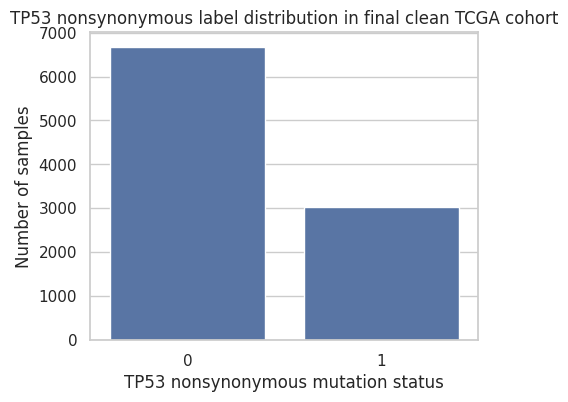

In [47]:
label_summary_clean = pd.Series({
    "n_samples": len(model_eda),
    "n_tp53_nonsyn": int(model_eda["TP53_mut_nonsyn"].sum()),
    "n_tp53_wildtype_or_no_nonsyn": int((model_eda["TP53_mut_nonsyn"] == 0).sum()),
    "tp53_nonsyn_rate": float(model_eda["TP53_mut_nonsyn"].mean()),
})

display(label_summary_clean.to_frame("value"))

plt.figure(figsize=(5, 4))
sns.countplot(data=model_eda, x="TP53_mut_nonsyn")
plt.title("TP53 nonsynonymous label distribution in final clean TCGA cohort")
plt.xlabel("TP53 nonsynonymous mutation status")
plt.ylabel("Number of samples")
plt.show()

In [48]:
# Task 2 label design in the final clean TCGA cohort.
def collapse_tcga_task2_label(raw_class):
    if pd.isna(raw_class):
        return "WT"
    if raw_class == "missense":
        return "missense"
    if raw_class in {"truncating", "splice"}:
        return "truncating_or_splice"
    if raw_class in {"inframe", "protein_altering"}:
        return "rare_protein_altering_excluded"
    if raw_class == "synonymous":
        return "synonymous_excluded"
    return "ambiguous_excluded"

model_eda["TP53_task2_raw"] = model_eda["tp53_primary_event_class"].fillna("WT")
model_eda["TP53_task2_label"] = model_eda["tp53_primary_event_class"].map(collapse_tcga_task2_label)

tcga_task2_raw_counts = (
    model_eda["TP53_task2_raw"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_raw")
    .to_frame("n_final_clean_cohort")
)

tcga_task2_collapsed_counts = (
    model_eda["TP53_task2_label"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_label")
    .to_frame("n_final_clean_cohort")
)

print("Raw Task 2 classes in the final clean cohort:")
display(tcga_task2_raw_counts)
print("Collapsed/excluded Task 2 classes for modeling:")
display(tcga_task2_collapsed_counts)


Raw Task 2 classes in the final clean cohort:


,n_final_clean_cohort
TP53_task2_raw,
WT,6636
missense,1898
truncating,841
splice,216
inframe,66
synonymous,38


Collapsed/excluded Task 2 classes for modeling:


,n_final_clean_cohort
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057
rare_protein_altering_excluded,66
synonymous_excluded,38


## Cancer-type composition and TP53 prevalence

This section checks whether cancer type is likely to confound pan-cancer TP53 prediction.

,n_samples,tp53_rate,n_tp53
cancer type abbreviation,,,
BRCA,1090,0.239450,261
KIRC,530,0.020755,11
HNSC,518,0.677606,351
LUAD,513,0.500975,257
LGG,510,0.472549,241
THCA,504,0.005952,3
LUSC,495,0.795960,394
PRAD,495,0.117172,58
SKCM,464,0.146552,68


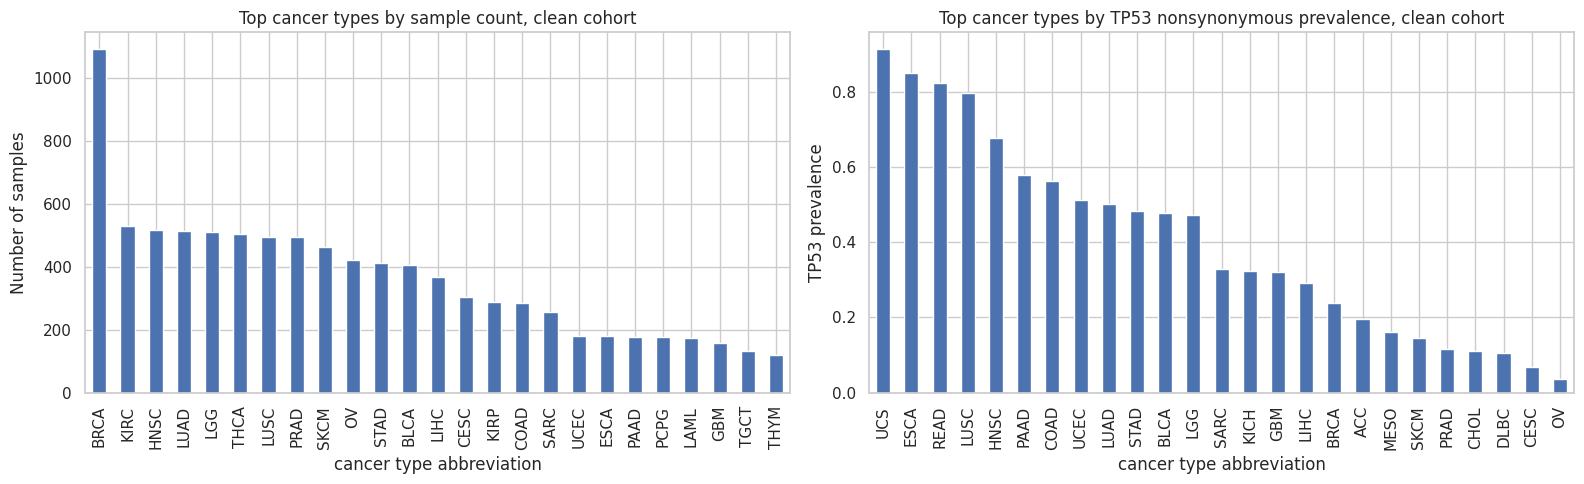

In [49]:
cancer_stats_clean = (
    model_eda
    .groupby(CANCER_TYPE_COL)
    .agg(
        n_samples=("sample_id", "size"),
        tp53_rate=("TP53_mut_nonsyn", "mean"),
        n_tp53=("TP53_mut_nonsyn", "sum"),
    )
    .sort_values("n_samples", ascending=False)
)

display(cancer_stats_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cancer_stats_clean["n_samples"].sort_values(ascending=False).head(25).plot(
    kind="bar",
    ax=axes[0],
)
axes[0].set_title("Top cancer types by sample count, clean cohort")
axes[0].set_ylabel("Number of samples")

cancer_stats_clean["tp53_rate"].sort_values(ascending=False).head(25).plot(
    kind="bar",
    ax=axes[1],
)
axes[1].set_title("Top cancer types by TP53 nonsynonymous prevalence, clean cohort")
axes[1].set_ylabel("TP53 prevalence")

plt.tight_layout()
plt.show()

### Cancer-type interpretation

Cancer type can strongly confound TP53 prediction because it affects both mutation prevalence and RNA expression. In this notebook, cancer type is therefore used for split stratification, subgroup auditing, and grouped evaluation, not as a predictor.


## Metadata missingness

In [50]:
metadata_cols_to_check = [
    "sample_id",
    "patient_id",
    "sample_type_code",
    "sample_type_label",
    "is_tumor_sample",
    CANCER_TYPE_COL,
    "TP53_mut_nonsyn",
    "TP53_mut_ambiguous",
    "has_mixed_tp53_annotation",
]

metadata_missing_raw = (
    merged[metadata_cols_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

metadata_missing_clean = (
    model_eda[metadata_cols_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(metadata_missing_raw.to_frame("missing_fraction_raw_merged"))
display(metadata_missing_clean.to_frame("missing_fraction_clean_cohort"))

,missing_fraction_raw_merged
sample_type_code,0.003702
is_tumor_sample,0.003702
sample_type_label,0.003702
cancer type abbreviation,0.003702
patient_id,0.003322
sample_id,0.000000
TP53_mut_nonsyn,0.000000
TP53_mut_ambiguous,0.000000
has_mixed_tp53_annotation,0.000000


,missing_fraction_clean_cohort
sample_id,0.0
patient_id,0.0
sample_type_code,0.0
sample_type_label,0.0
is_tumor_sample,0.0
cancer type abbreviation,0.0
TP53_mut_nonsyn,0.0
TP53_mut_ambiguous,0.0
has_mixed_tp53_annotation,0.0


## RNA expression structure in the final clean cohort

In [51]:
# Optional heavy RNA EDA for the final clean TCGA cohort.
# Disabled by default because the modeling section streams and loads the exact final cohort RNA matrix once.
model_sample_ids = model_eda["sample_id"].tolist()

if RUN_TCGA_RNA_EDA:
    print("RUN_TCGA_RNA_EDA=True: loading a final-cohort RNA matrix for descriptive EDA. This may be memory-heavy on Kaggle.")
    expr_clean = load_rna_subset(
        RNA_PATH,
        RNA_SEP,
        RNA_ORIENTATION,
        model_sample_ids,
        max_features=min(TCGA_MODEL_RNA_FEATURE_CAP, TOP_VAR_GENES_FOR_PCA),
        chunksize=TCGA_RNA_CHUNKSIZE,
    )
    expr_clean.index = model_eda.index

    assert expr_clean.shape[0] == len(model_eda)
    assert expr_clean.isna().mean().mean() < 0.05, "Unexpectedly high expression missingness."

    gene_cols = expr_clean.columns.tolist()
    print("Expression matrix for clean cohort:", expr_clean.shape)
    print("RNA feature count:", expr_clean.shape[1])
    print("Overall missing fraction:", float(expr_clean.isna().mean().mean()))

    gene_var = expr_clean.var(axis=0)
    display(gene_var.describe().to_frame("gene_variance"))

    plt.figure(figsize=(6, 4))
    plt.hist(np.log10(gene_var.replace(0, np.nan).dropna()), bins=60)
    plt.title("Distribution of log10 gene variance, clean cohort")
    plt.xlabel("log10 variance")
    plt.ylabel("Number of genes")
    plt.show()
else:
    expr_clean = None
    gene_cols = list(rna_feature_preview)
    gene_var = pd.Series(dtype=float)
    print("Skipping full TCGA RNA EDA matrix load because RUN_TCGA_RNA_EDA=False.")
    print("Final clean cohort samples to load in modeling section:", len(model_sample_ids))
    print("The modeling section will stream-select top-variance RNA features before materializing X_rna.")


Skipping full TCGA RNA EDA matrix load because RUN_TCGA_RNA_EDA=False.
Final clean cohort samples to load in modeling section: 9695
The modeling section will stream-select top-variance RNA features before materializing X_rna.


### RNA dimensionality conclusion

The RNA matrix is very high-dimensional relative to sample size. Dimensionality reduction, variance filtering, and supervised feature selection may be useful, but any supervised feature selection must be done inside training/CV folds in the modelling notebook.

## PCA on high-variance genes

This PCA is descriptive only. It should not be used for final model selection.

In [52]:
if RUN_TCGA_RNA_EDA and expr_clean is not None:
    # Use top variable genes for stable PCA.
    top_var_genes = gene_var.sort_values(ascending=False).head(TOP_VAR_GENES_FOR_PCA).index.tolist()

    X_pca_input = expr_clean[top_var_genes].copy()
    X_pca_input = X_pca_input.fillna(X_pca_input.median())

    X_scaled = StandardScaler().fit_transform(X_pca_input)
    pca = PCA(n_components=10, random_state=RANDOM_STATE)
    pca_scores = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(
        pca_scores[:, :5],
        columns=[f"PC{i}" for i in range(1, 6)],
        index=model_eda.index,
    )
    pca_df["TP53_mut_nonsyn"] = model_eda["TP53_mut_nonsyn"].values
    pca_df[CANCER_TYPE_COL] = model_eda[CANCER_TYPE_COL].values

    display(pca_df.head())
    print("Explained variance ratio, first 5 PCs:", pca.explained_variance_ratio_[:5])

    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="TP53_mut_nonsyn", alpha=0.6, s=20)
    plt.title("PCA of high-variance RNA genes by TP53 status")
    plt.show()

    top_types = cancer_stats_clean.head(10).index
    pca_top = pca_df.loc[pca_df[CANCER_TYPE_COL].isin(top_types)].copy()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_top, x="PC1", y="PC2", hue=CANCER_TYPE_COL, alpha=0.7, s=20)
    plt.title("PCA of high-variance RNA genes by top cancer types")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping TCGA PCA EDA because RUN_TCGA_RNA_EDA=False.")


Skipping TCGA PCA EDA because RUN_TCGA_RNA_EDA=False.


### PCA interpretation

PCA is expected to reflect broad cancer-type structure more strongly than TP53 mutation status. This supports using cancer type as a stratification and evaluation variable rather than as a predictor.


## TP53 target-gene and gene-identifier limitation

The RNA matrix typically uses Ensembl gene IDs, while TP53 target-gene lists often use gene symbols. Direct overlap between Ensembl IDs and symbols is not meaningful without an annotation map.

The optional `tp53_target_genes_fischer2017.csv` file is a broad curated p53/TP53 target-gene reference list. These are genes whose expression may respond to p53 activity; they are not genes that are necessarily mutated in the samples. This reference is used only for biological sanity checks and coefficient annotation when identifier mapping allows it.


In [53]:
print("Example RNA feature IDs:")
display(pd.Series(gene_cols[:10], name="rna_feature_id"))

if TP53_TARGETS_PATH is not None and Path(TP53_TARGETS_PATH).exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH)
    print("TP53 target list shape:", tp53_targets.shape)
    display(tp53_targets.head())
else:
    tp53_targets = None
    print("No TP53 target-gene list found.")

if GENE_ANNOTATION_PATH is not None:
    print("Gene annotation file found:", GENE_ANNOTATION_PATH)
else:
    print("No gene annotation file found. Biological interpretation will be limited to Ensembl IDs.")

print("Direct symbol-to-Ensembl overlap should not be interpreted without annotation.")

Example RNA feature IDs:


0     ENSG00000242268.2
1     ENSG00000259041.1
2     ENSG00000270112.3
3    ENSG00000167578.16
4     ENSG00000278814.1
5     ENSG00000078237.5
6     ENSG00000269416.5
7     ENSG00000263642.1
8    ENSG00000146083.11
9    ENSG00000158486.13
Name: rna_feature_id, dtype: object

TP53 target list shape: (343, 1)


,gene_symbol
0,ABCA12
1,ABHD4
2,ABTB2
3,ACER2
4,ACTA2


No gene annotation file found. Biological interpretation will be limited to Ensembl IDs.
Direct symbol-to-Ensembl overlap should not be interpreted without annotation.


## Exploratory RNA-label differences

This section is descriptive only. It should not be used as final feature selection because it uses the full clean cohort and labels.

If TP53 target-gene references are used here, they are used for interpretation of RNA-expression patterns, not for constructing mutation labels.


In [54]:
if RUN_TCGA_RNA_EDA and expr_clean is not None:
    y_clean = model_eda["TP53_mut_nonsyn"].astype(int).values
    group0 = expr_clean.loc[y_clean == 0]
    group1 = expr_clean.loc[y_clean == 1]
    effect_size = group1.mean(axis=0) - group0.mean(axis=0)
    effect_df = effect_size.sort_values(ascending=False).rename("mean_diff_mut_minus_wt").to_frame()
    display(effect_df.head(20))
    display(effect_df.tail(20))
else:
    print("Skipping full-cohort RNA-label difference EDA because RUN_TCGA_RNA_EDA=False.")
    print("This avoids duplicating the modeling section's RNA load and avoids leakage-prone feature selection in EDA.")


Skipping full-cohort RNA-label difference EDA because RUN_TCGA_RNA_EDA=False.
This avoids duplicating the modeling section's RNA load and avoids leakage-prone feature selection in EDA.


### Warning

The exploratory RNA-label differences above are useful for sanity checking, but they are not a leakage-safe feature-selection procedure. In the modelling notebook, supervised feature selection must be performed only within training/CV folds.

# EDA conclusions

## Proposed main label

The primary target is `TP53_mut_nonsyn`, defined as whether a sample has at least one nonsynonymous / protein-altering TP53 mutation.

This is a somatic mutation label for TP53, not TP53 RNA expression. The corresponding WT/non-mutant group means no retained protein-altering TP53 event under the notebook's mutation-annotation rules, not proof that the p53 pathway is fully intact.

## Final modelling cohort

The final TCGA modelling cohort uses the same rules as the modeling section:

1. keep samples present in the RNA matrix;
2. keep tumour samples only;
3. exclude samples with missing cancer type;
4. exclude ambiguous or mixed TP53 mutation annotations;
5. keep one sample per patient to prevent patient-level leakage;
6. prefer primary tumour samples when multiple tumour samples exist for the same patient.

Cancer type is retained for stratification and grouped evaluation only. It is not used as a model feature in the primary RNA-only models.


# TCGA Pan-Cancer Modeling for Predicting TP53 Mutation Status from RNA Expression

This notebook builds a leakage-aware workflow for predicting **TP53 mutation status** from **TCGA RNA expression**.

TP53 mutation status is a somatic mutation label for the `TP53` gene. It is not TP53 RNA expression level. RNA expression across genes is the predictor space.

Cancer type is used only as a **stratification/grouping/audit variable** in the submitted primary RNA-only models. It is not included as a predictor in those models.

## Main goals

- build a **tumour-only**, **one-sample-per-patient** TCGA cohort;
- define **TP53 nonsynonymous mutation status** from mutation annotations;
- train RNA-only Task 1 and Task 2 models;
- use adaptive TP53 × cancer-type stratification for train/test splits;
- run cancer-type-grouped CV as an anti-confounding robustness check;
- run RNA-only ablation / ensemble models, using cuML when available and falling back safely when it is not.


In [55]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import gzip
import os
import re
import sys
import subprocess
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)

In [56]:
# Search locations for Kaggle, Colab, local, and this sandbox.
# The first Kaggle path below matches the path seen in the previously successful run.
SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/cameroncaputa/tp53-prediction"),
    Path("/kaggle/input/tp53-prediction"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file.\nTried:\n" + "\n".join(tried))
    return None

# Prefer raw TCGA/Xena files when available.
RAW_MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3.v0.2.8.PUBLIC.xena",
    "*mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3*PUBLIC*xena*",
], required=False)

RAW_PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=False)

RAW_RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "tcga_RSEM_gene_tpm.gz",
    "*tcga_RSEM_gene_tpm*",
], required=False)

# Curated CSV fallbacks.
MODEL_PATH = find_first(["Model.csv", "*Model*.csv"], required=False)
OMICS_MUT_PATH = find_first([
    "OmicsSomaticMutations.csv",
    "*OmicsSomaticMutations*.csv",
], required=False)
OMICS_RNA_PATH = find_first([
    "OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    "OmicsExpressionProteinCodingGenesTPML.csv",
    "*OmicsExpressionProteinCodingGenesTPM*.csv",
    "*OmicsExpressionProteinCodingGenesTPML*",
], required=False)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

USE_RAW_TCGA = all(p is not None for p in [RAW_MUT_PATH, RAW_PHENO_PATH, RAW_RNA_PATH])

MUT_PATH = RAW_MUT_PATH if RAW_MUT_PATH is not None else OMICS_MUT_PATH
META_PATH = RAW_PHENO_PATH if RAW_PHENO_PATH is not None else MODEL_PATH
RNA_PATH = RAW_RNA_PATH if RAW_RNA_PATH is not None else OMICS_RNA_PATH

def show_available_kaggle_files(max_files=80):
    roots = [Path("/kaggle/input"), Path("/kaggle/input/datasets")]
    shown = 0
    print("\nAvailable files under Kaggle input roots:")
    for root in roots:
        if not root.exists():
            continue
        for p in sorted(root.rglob("*")):
            if p.is_file():
                print(" -", p)
                shown += 1
                if shown >= max_files:
                    print(f" ... truncated after {max_files} files")
                    return
    if shown == 0:
        print("No files found under /kaggle/input. Attach the TCGA raw-data Kaggle Dataset to this notebook.")

missing_inputs = []
if MUT_PATH is None:
    missing_inputs.append("mutation file: mc3.v0.2.8.PUBLIC.xena")
if META_PATH is None:
    missing_inputs.append("metadata/phenotype file: Survival_SupplementalTable_S1_20171025_xena_sp")
if RNA_PATH is None:
    missing_inputs.append("RNA expression file: tcga_RSEM_gene_tpm")

if missing_inputs:
    show_available_kaggle_files()
    raise FileNotFoundError(
        "Could not locate required TCGA input files. Missing:\n  - "
        + "\n  - ".join(missing_inputs)
        + "\n\nAttach the same Kaggle Dataset used in the successful run, which contained:\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm\n"
        + "Optional but recommended: tp53_target_genes_fischer2017.csv"
    )

RANDOM_STATE = 42
TEST_SIZE = 0.20
INNER_CV_SPLITS = 3
GROUP_CV_SPLITS = 3
TOP_COEFS_TO_SHOW = 25
TOP_VAR_GENES = min(3000, TCGA_MODEL_RNA_FEATURE_CAP)
FLOOR_VALUE = -9.9658
MAX_FLOOR_FRAC = 0.95
BOOTSTRAP_RESAMPLES = 200
MIN_SAMPLES_PER_CLASS = 20
SKLEARN_MAX_ITER = 10000
CUML_MAX_ITER = 10000
SAGA_TOL = 1e-3
CUML_TOL = 1e-4

RUN_GROUPED_CV = True
RUN_COMBINED_MODEL = False
RUN_WITHIN_CANCER_EVAL = False

# Runtime controls
GPU_REQUIRED = False
ALLOW_CPU_FALLBACK = True
INSTALL_RAPIDS_IN_COLAB = False
GPU_SEARCH_BACKEND = "cuml"      # {"cuml", "sklearn"}
FINAL_REFIT_BACKEND = "sklearn"  # {"sklearn", "cuml"}; sklearn is more reproducible for final reported fits
WITHIN_CANCER_BACKEND = "sklearn"   # {"cuml", "sklearn"}; fixed-parameter within-cancer checks favor reproducibility
GROUPED_TUNING_MODE = "reuse_holdout_best"  # {"nested", "reuse_holdout_best"}; nested is slower but methodologically cleaner


RNA_PARAM_GRID = {
    "top_k": [3000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5],
}

# Smaller pre-specified grids for nested cancer-type-grouped evaluation.
# This keeps the stricter grouped analysis feasible while avoiding reuse of random-holdout hyperparameters.
GROUPED_RNA_PARAM_GRID = {
    "top_k": [3000],
    "k_select": [500],
    "scaler": ["maxabs"],
    "C": [0.1],
    "l1_ratio": [0.0, 0.5],
}

print("Using raw TCGA/Xena inputs:", USE_RAW_TCGA)
print("TCGA_MODEL_RNA_FEATURE_CAP:", TCGA_MODEL_RNA_FEATURE_CAP)
print("MUT_PATH =", MUT_PATH)
print("META_PATH =", META_PATH)
print("RNA_PATH =", RNA_PATH)
print("TP53_TARGETS_PATH =", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH =", GENE_ANNOTATION_PATH)
print("RNA grid combinations:", len(list(ParameterGrid(RNA_PARAM_GRID))))
print("Grouped RNA grid combinations:", len(list(ParameterGrid(GROUPED_RNA_PARAM_GRID))))


Using raw TCGA/Xena inputs: True
TCGA_MODEL_RNA_FEATURE_CAP: 3000
MUT_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena
META_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp
RNA_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm
TP53_TARGETS_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH = None
RNA grid combinations: 12
Grouped RNA grid combinations: 2


The notebook uses a hybrid backend strategy. GPU-accelerated cuML is used for the repeated hyperparameter-search fits, where speed matters most. However, the final refit and within-cancer analyses are run with scikit-learn. These stages are used for the final reported estimates, coefficients, calibration, and subgroup results, so numerical stability, clearer convergence diagnostics, and reproducibility are more important than speed. This is especially relevant because some within-cancer subsets are small or highly imbalanced, where GPU overhead and solver behavior may be less reliable. Thus, cuML is used as an acceleration tool for model search, while scikit-learn is used as the reference implementation for final reporting.

## GPU environment setup

The heavy RNA and combined-model searches can use **RAPIDS cuML** if it is available in the runtime.

- If RAPIDS is installed and importable, the manual elastic-net search can use **cuML LogisticRegression**.
- If RAPIDS is unavailable, the notebook falls back to **scikit-learn** automatically unless `GPU_REQUIRED=True`.
- The **final refit** defaults to **scikit-learn** for more reproducible reported holdout estimates and fewer GPU convergence-warning issues.
- The grouped cancer-type evaluation defaults to nested tuning with a smaller pre-specified grid. This is slower than reusing random-holdout hyperparameters, but it is the cleaner anti-confounding estimate.

In [57]:
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.exists("/kaggle")

if INSTALL_RAPIDS_IN_COLAB and IN_COLAB:
    utils_dir = Path("./rapidsai-csp-utils")
    if not utils_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/rapidsai/rapidsai-csp-utils.git"],
            check=True,
        )
    subprocess.run([sys.executable, "rapidsai-csp-utils/colab/pip-install.py"], check=True)

GPU_AVAILABLE = False
GPU_IMPORT_ERROR = None
cp = None
cuLogisticRegression = None
cuml = None

try:
    import cupy as cp
    import cuml
    from cuml.linear_model import LogisticRegression as cuLogisticRegression

    GPU_AVAILABLE = True
    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass
except Exception as e:
    GPU_IMPORT_ERROR = repr(e)

if GPU_REQUIRED and not GPU_AVAILABLE and not ALLOW_CPU_FALLBACK:
    raise RuntimeError(
        "GPU_REQUIRED=True but cuML/CuPy could not be imported. "
        "Install RAPIDS in a compatible CUDA environment first."
    )

if GPU_SEARCH_BACKEND == "cuml" and not GPU_AVAILABLE:
    if ALLOW_CPU_FALLBACK:
        print("cuML not available; falling back to scikit-learn CPU search.")
        GPU_SEARCH_BACKEND = "sklearn"
        if FINAL_REFIT_BACKEND == "cuml":
            FINAL_REFIT_BACKEND = "sklearn"
        if WITHIN_CANCER_BACKEND == "cuml":
            WITHIN_CANCER_BACKEND = "sklearn"
    else:
        raise RuntimeError("GPU search requested but cuML/CuPy are unavailable.")

gpu_name = None
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        text=True,
    ).strip().splitlines()
    gpu_name = smi[0] if smi else None
except Exception:
    pass

print("In Colab:", IN_COLAB)
print("In Kaggle:", IN_KAGGLE)
print("GPU available:", GPU_AVAILABLE)
print("GPU import error:", GPU_IMPORT_ERROR)
print("Detected GPU name:", gpu_name)
print("GPU search backend:", GPU_SEARCH_BACKEND)
print("Final refit backend:", FINAL_REFIT_BACKEND)
print("Within-cancer backend:", WITHIN_CANCER_BACKEND)
print("Grouped tuning mode:", GROUPED_TUNING_MODE)

In Colab: False
In Kaggle: True
GPU available: True
GPU import error: None
Detected GPU name: Tesla T4
GPU search backend: cuml
Final refit backend: sklearn
Within-cancer backend: sklearn
Grouped tuning mode: reuse_holdout_best


## Load mutation and metadata tables

The notebook first loads the mutation and metadata / phenotype tables, infers the relevant schema, and only then loads the RNA matrix after the modeling cohort is frozen.

This avoids loading the full expression matrix too early.

In [58]:
def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        line = f.readline()
    if line.count("\t") > line.count(","):
        return "\t"
    return ","

def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None

def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))

def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))

def normalize_sample_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s

def normalize_patient_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s

def tcga_sample_type_code(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan

TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan

def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

MUT_SEP = sniff_sep(MUT_PATH)
META_SEP = sniff_sep(META_PATH)
RNA_SEP = sniff_sep(RNA_PATH)

mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
meta_raw = pd.read_csv(META_PATH, sep=META_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=3, low_memory=False)

print("mut_raw shape:", mut_raw.shape)
print("meta_raw shape:", meta_raw.shape)
print("rna_header preview shape:", rna_header.shape)
print("mut_raw columns:", mut_raw.columns.tolist()[:20])
print("meta_raw columns:", meta_raw.columns.tolist()[:20])
print("RNA first columns:", list(rna_header.columns[:8]))

MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

META_SAMPLE_COL = find_col(
    meta_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "metadata sample column",
)
PATIENT_COL = find_col(
    meta_raw,
    ["patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    meta_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen metadata sample column:", META_SAMPLE_COL)
print("Chosen patient column:", PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

mut_raw shape: (2907335, 12)
meta_raw shape: (12591, 34)
rna_header preview shape: (3, 10536)
mut_raw columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
meta_raw columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']
Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect']
Chosen metadata sample column: sample
Chosen patient column: _P

## Infer RNA matrix orientation and available samples

The notebook supports two RNA layouts:

1. **sample × gene**  
   first column is sample ID, remaining columns are genes

2. **gene × sample**  
   first column is gene ID, remaining columns are sample IDs

The loader detects the layout automatically and then loads only the retained cohort later.

A misleading column name such as `sample` does not by itself prove that rows are samples. In the TCGA/Xena RNA file, the first column can contain gene identifiers even if the column header is named `sample`, so orientation detection is essential before creating the ML matrix.


In [59]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}

    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    # Strong clues from header names.
    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    # Fallback using first few row values.
    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    # Conservative default for TCGA-like Xena matrices.
    return "sample_x_gene"

RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

def get_rna_available_samples(path, sep, orientation):
    if orientation == "gene_x_sample":
        header = pd.read_csv(path, sep=sep, nrows=0)
        sample_ids = [normalize_sample_id(c) for c in header.columns[1:]]
        return pd.Index(pd.unique(pd.Series(sample_ids).dropna()), name="sample_id")

    sample_ids = []
    for chunk in pd.read_csv(path, sep=sep, usecols=[0], chunksize=5000, low_memory=False):
        vals = chunk.iloc[:, 0].map(normalize_sample_id)
        sample_ids.extend(vals.dropna().tolist())
    return pd.Index(pd.unique(pd.Series(sample_ids)), name="sample_id")

rna_available_samples = get_rna_available_samples(RNA_PATH, RNA_SEP, RNA_ORIENTATION)

print("RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)
print("Number of RNA-available samples:", len(rna_available_samples))
print("Example RNA-available samples:", rna_available_samples[:5].tolist())

RNA orientation: gene_x_sample
RNA first column: sample
Number of RNA-available samples: 10535
Example RNA-available samples: ['TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01']


## Rebuild the TP53 sample-level label

This follows the same scientific rule as before:

- `TP53_mut_nonsyn = 1` if a sample has at least one protein-altering TP53 event;
- ambiguous / mixed cases are tracked and later excluded from modeling.

The negative/WT class means no retained protein-altering TP53 event under the mutation-file rules. It does not exclude every possible mechanism of p53 pathway disruption.


In [60]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}

def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"

tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("rate"))

TP53 mutation rows: 3729


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


,rate
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


In [61]:
# Task 2 sample-level mutation-type label source.
# A sample can have multiple TP53 rows, so choose a primary event by severity for the multiclass task.
TCGA_TASK2_PRIORITY = {
    "truncating": 7,
    "splice": 6,
    "missense": 5,
    "inframe": 4,
    "protein_altering": 3,
    "synonymous": 2,
    "other_or_unknown": 1,
    "unknown": 0,
}

tp53_rows["task2_priority"] = (
    tp53_rows["tp53_event_class"]
    .map(TCGA_TASK2_PRIORITY)
    .fillna(0)
    .astype(int)
)

tp53_primary_event = (
    tp53_rows
    .sort_values(["sample_id", "task2_priority"], ascending=[True, False])
    .drop_duplicates("sample_id")
    .set_index("sample_id")["tp53_event_class"]
    .rename("tp53_primary_event_class")
)

tp53_nonsyn_class_count = (
    tp53_rows.loc[tp53_rows["is_tp53_nonsyn"]]
    .groupby("sample_id")["tp53_event_class"]
    .nunique()
    .rename("n_unique_tp53_nonsyn_event_classes")
)

tp53_sample = tp53_sample.merge(
    tp53_primary_event.reset_index(),
    on="sample_id",
    how="left",
)

tp53_sample = tp53_sample.merge(
    tp53_nonsyn_class_count.reset_index(),
    on="sample_id",
    how="left",
    suffixes=("", "_nonsyn_only"),
)

if "n_unique_tp53_nonsyn_event_classes_nonsyn_only" in tp53_sample.columns:
    tp53_sample["n_unique_tp53_nonsyn_event_classes"] = tp53_sample[
        "n_unique_tp53_nonsyn_event_classes_nonsyn_only"
    ].fillna(0).astype(int)
    tp53_sample = tp53_sample.drop(columns=["n_unique_tp53_nonsyn_event_classes_nonsyn_only"])

print("Sample-level primary TP53 event class counts before cohort filtering:")
display(tp53_primary_event.value_counts().rename_axis("tp53_primary_event_class").to_frame("n_samples"))


Sample-level primary TP53 event class counts before cohort filtering:


,n_samples
tp53_primary_event_class,
missense,2069
truncating,900
splice,230
inframe,71
synonymous,45
other_or_unknown,10


## Build phenotype metadata and freeze the modeling cohort

This section applies the leakage-aware cohort rules before any large RNA matrix is loaded:

- retain only samples with RNA available
- derive patient IDs from phenotype/sample barcodes for **all** samples, not only mutation-positive samples
- keep tumour samples only
- require non-missing cancer type
- remove ambiguous or mixed TP53 labels
- keep exactly one sample per patient

These rules mirror the revised TCGA EDA cohort decisions.

In [62]:
meta = meta_raw.copy()
meta["sample_id"] = meta[META_SAMPLE_COL].map(normalize_sample_id)

if PATIENT_COL is not None:
    meta["patient_id"] = meta[PATIENT_COL]
else:
    meta["patient_id"] = meta["sample_id"].map(normalize_patient_id)

meta["patient_id"] = meta["patient_id"].fillna(meta["sample_id"].map(normalize_patient_id))
meta["sample_type_code"] = meta["sample_id"].map(tcga_sample_type_code)
meta["sample_type_label"] = meta["sample_id"].map(tcga_sample_type_label)

if USE_RAW_TCGA:
    meta["is_tumor_sample"] = meta["sample_id"].map(is_tcga_tumor_sample)
else:
    # For non-TCGA fallback tables, keep all rows by default.
    meta["is_tumor_sample"] = True

meta["in_rna"] = meta["sample_id"].isin(rna_available_samples)

meta = meta.merge(tp53_sample, on="sample_id", how="left", suffixes=("", "_tp53"))
if "patient_id_tp53" in meta.columns:
    meta["patient_id"] = meta["patient_id"].fillna(meta["patient_id_tp53"])

meta["TP53_mut_nonsyn"] = meta["TP53_mut_nonsyn"].fillna(0).astype(int)
meta["TP53_mut_ambiguous"] = meta["TP53_mut_ambiguous"].fillna(0).astype(int)
meta["has_any_tp53_row"] = meta["has_any_tp53_row"].fillna(False).astype(bool)
meta["has_mixed_tp53_annotation"] = meta["has_mixed_tp53_annotation"].fillna(0).astype(int)

SAMPLE_PRIORITY = {
    "01": 0,
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}

model_meta = meta.copy()
model_meta = model_meta.loc[model_meta["in_rna"]].copy()
model_meta = model_meta.loc[model_meta["is_tumor_sample"].fillna(False)].copy()
model_meta = model_meta.loc[model_meta[CANCER_TYPE_COL].notna()].copy()
model_meta = model_meta.loc[
    (model_meta["TP53_mut_ambiguous"] == 0) &
    (model_meta["has_mixed_tp53_annotation"] == 0)
].copy()

pre_dedup_n = len(model_meta)
pre_dedup_multi_patient_counts = (
    model_meta["patient_id"].value_counts().loc[lambda s: s > 1].sort_values(ascending=False)
)

model_meta["sample_priority"] = model_meta["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_meta = (
    model_meta.sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

cohort_summary = pd.Series({
    "n_rows": len(model_meta),
    "n_unique_samples": model_meta["sample_id"].nunique(),
    "n_unique_patients": model_meta["patient_id"].nunique(),
    "tp53_prevalence": model_meta["TP53_mut_nonsyn"].mean(),
    "n_cancer_types": model_meta[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_meta["patient_id"].isna().sum() == 0, "Patient IDs must be present after backfill."
assert model_meta["patient_id"].nunique() == len(model_meta), "Exactly one sample per patient should remain."
assert set(model_meta["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."
print("Final cohort passes basic leakage-sensitive checks.")

,value
n_rows,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-G5-6572,2
TCGA-2G-AAKG,2
TCGA-ER-A2NF,2
TCGA-K1-A42X,2
TCGA-TM-A7CF,2
TCGA-QR-A6GZ,2
TCGA-K1-A3PN,2
TCGA-HM-A6W2,2


Final cohort passes basic leakage-sensitive checks.


## Task 2 label design: sample-level TP53 mutation type

This block constructs the TCGA mutation-type target required by the assignment. The raw mutation annotations are converted to sample-level TP53 mutation-type/consequence labels.

The main TCGA Task 2 classes are:

- `WT`: no retained protein-altering TP53 mutation in the sample under the notebook's rules;
- `missense`: TP53 missense events;
- `truncating_or_splice`: truncating, frameshift, nonsense, or splice-related TP53 events.

`WT` is included in the main 3-class status/type formulation, but it should not be interpreted as proof of a completely normal p53 pathway. It only means no retained protein-altering TP53 mutation annotation was used for the label.

Rare or ambiguous categories are counted first and then excluded from the main multiclass model rather than being forced into unstable labels. This is a deliberate modelling choice. A very literal mutation-type classifier could separate all raw categories, but several mutation subtypes have limited sample support. Collapsing related categories into broader biological consequence classes gives a more stable supervised learning target while still addressing the assignment's goal of predicting TP53 mutation type.

The strict mutant-only Task 2 evaluation later in the notebook removes WT samples and evaluates only the distinction between `missense` and `truncating_or_splice` among TP53-mutant test samples.


In [63]:
def collapse_tcga_task2_label(raw_class):
    if pd.isna(raw_class):
        return "WT"
    if raw_class == "missense":
        return "missense"
    if raw_class in {"truncating", "splice"}:
        return "truncating_or_splice"
    if raw_class in {"inframe", "protein_altering"}:
        return "rare_protein_altering_excluded"
    if raw_class == "synonymous":
        return "synonymous_excluded"
    return "ambiguous_excluded"

model_meta["TP53_task2_raw"] = model_meta["tp53_primary_event_class"].fillna("WT")
model_meta["TP53_task2_label"] = model_meta["tp53_primary_event_class"].map(collapse_tcga_task2_label)

task2_raw_counts = (
    model_meta["TP53_task2_raw"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_raw")
    .to_frame("n")
)

task2_candidate_counts = (
    model_meta["TP53_task2_label"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

print("Raw TCGA Task 2 labels in final clean cohort:")
display(task2_raw_counts)
print("Collapsed/excluded TCGA Task 2 labels:")
display(task2_candidate_counts)

tcga_task2_keep_labels = ["WT", "missense", "truncating_or_splice"]
task2_mask = model_meta["TP53_task2_label"].isin(tcga_task2_keep_labels)
model_meta_task2 = model_meta.loc[task2_mask].copy()

print("Final TCGA Task 2 modeling classes:")
display(
    model_meta_task2["TP53_task2_label"]
    .value_counts()
    .reindex(tcga_task2_keep_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n_final_task2")
)

print("Excluded from main Task 2 model:")
display(
    task2_candidate_counts.loc[
        ~task2_candidate_counts.index.isin(tcga_task2_keep_labels)
    ]
)


Raw TCGA Task 2 labels in final clean cohort:


,n
TP53_task2_raw,
WT,6636
missense,1898
truncating,841
splice,216
inframe,66
synonymous,38


Collapsed/excluded TCGA Task 2 labels:


,n
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057
rare_protein_altering_excluded,66
synonymous_excluded,38


Final TCGA Task 2 modeling classes:


,n_final_task2
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057


Excluded from main Task 2 model:


,n
TP53_task2_label,
rare_protein_altering_excluded,66
synonymous_excluded,38


## Load RNA for the final retained cohort only

The loader handles either:

- **sample × gene** RNA matrices by chunking through rows and keeping only retained samples
- **gene × sample** RNA matrices by loading only the retained sample columns and then transposing

In [64]:
def load_rna_subset(path, sep, orientation, selected_sample_ids, max_features=None, chunksize=750):
    """Load final-cohort RNA only, with streaming top-variance feature capping.

    For TCGA gene x sample matrices, loading all genes for all retained samples can exceed Kaggle memory.
    This function first streams the file to identify high-variance genes within the final cohort, then
    materializes only those genes as a samples x genes float32 matrix. No labels are used for this filter.
    """
    selected_sample_ids = list(pd.Index(selected_sample_ids).astype(str))
    selected_set = set(selected_sample_ids)
    max_features = None if max_features is None else int(max_features)

    if orientation == "sample_x_gene":
        chunks = []
        for chunk in pd.read_csv(path, sep=sep, chunksize=256, low_memory=False):
            first_col = chunk.columns[0]
            chunk["sample_id"] = chunk[first_col].map(normalize_sample_id)
            sub = chunk.loc[chunk["sample_id"].isin(selected_set)].copy()
            if len(sub) == 0:
                continue
            keep_cols = ["sample_id"] + [c for c in sub.columns if c not in {first_col, "sample_id"}]
            chunks.append(sub[keep_cols])
        if len(chunks) == 0:
            raise ValueError("No selected samples were found in the RNA matrix.")
        rna_df = pd.concat(chunks, axis=0, ignore_index=True).drop_duplicates("sample_id", keep="first")
        rna_df = rna_df.set_index("sample_id").reindex(selected_sample_ids)
        rna_df.index.name = "sample_id"
        rna_df.columns.name = None
        rna_df = rna_df.apply(pd.to_numeric, errors="coerce").astype(np.float32)
        if max_features is not None and rna_df.shape[1] > max_features:
            top_cols = rna_df.var(axis=0).sort_values(ascending=False).head(max_features).index
            rna_df = rna_df.loc[:, top_cols]
        return rna_df

    # gene x sample: stream rows to avoid materializing full matrix.
    header = pd.read_csv(path, sep=sep, nrows=0)
    first_col = header.columns[0]
    sample_cols = [c for c in header.columns[1:] if normalize_sample_id(c) in selected_set]
    if len(sample_cols) == 0:
        raise ValueError("No selected samples matched RNA columns in a gene x sample matrix.")

    print(f"RNA loader matched {len(sample_cols)} RNA columns for {len(selected_sample_ids)} final-cohort samples.")
    print(f"Streaming top-variance RNA feature cap: {max_features if max_features is not None else 'all'}")

    usecols = [first_col] + sample_cols

    if max_features is not None:
        top_frames = []
        n_seen = 0
        for chunk in pd.read_csv(path, sep=sep, usecols=usecols, chunksize=chunksize, low_memory=False):
            features = chunk[first_col].astype(str)
            values = chunk[sample_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32, copy=False)
            variances = np.nanvar(values, axis=1)
            local = pd.DataFrame({"feature_id": features.to_numpy(), "variance": variances})
            top_frames.append(local.nlargest(min(max_features, len(local)), "variance"))
            n_seen += len(local)
            if len(top_frames) > 8:
                top_frames = [pd.concat(top_frames, ignore_index=True).nlargest(max_features, "variance")]
        top_feature_df = pd.concat(top_frames, ignore_index=True).nlargest(max_features, "variance")
        selected_features = set(top_feature_df["feature_id"].astype(str))
        print(f"Scanned {n_seen:,} RNA features; retaining {len(selected_features):,} top-variance features.")
    else:
        selected_features = None

    kept_chunks = []
    for chunk in pd.read_csv(path, sep=sep, usecols=usecols, chunksize=chunksize, low_memory=False):
        chunk[first_col] = chunk[first_col].astype(str)
        if selected_features is not None:
            chunk = chunk.loc[chunk[first_col].isin(selected_features)].copy()
        if len(chunk) == 0:
            continue
        kept_chunks.append(chunk)

    if len(kept_chunks) == 0:
        raise ValueError("No RNA features retained after streaming selection.")

    subset = pd.concat(kept_chunks, axis=0, ignore_index=True)
    subset = subset.rename(columns={first_col: "feature_id"})
    subset = subset.rename(columns={c: normalize_sample_id(c) for c in sample_cols})

    dup_cols = pd.Index(subset.columns[1:]).duplicated(keep=False)
    if dup_cols.any():
        feature = subset["feature_id"]
        values = subset.drop(columns=["feature_id"])
        values = values.groupby(level=0, axis=1).mean()
        subset = pd.concat([feature, values], axis=1)

    subset = subset.set_index("feature_id")
    subset = subset.apply(pd.to_numeric, errors="coerce")
    rna_df = subset.T
    rna_df.index = pd.Index(rna_df.index.map(normalize_sample_id), name="sample_id")
    rna_df = rna_df.groupby(level=0).mean().reindex(selected_sample_ids)
    rna_df.columns.name = None
    rna_df = rna_df.astype(np.float32)
    return rna_df

selected_sample_ids = model_meta["sample_id"].tolist()
rna_mat = load_rna_subset(RNA_PATH, RNA_SEP, RNA_ORIENTATION, selected_sample_ids, max_features=TCGA_MODEL_RNA_FEATURE_CAP, chunksize=TCGA_RNA_CHUNKSIZE)

assert rna_mat.shape[0] == len(selected_sample_ids), "RNA sample count does not match retained cohort."
assert rna_mat.index.equals(pd.Index(selected_sample_ids, name="sample_id")), "RNA sample order mismatch."

print("rna_mat shape (samples x genes):", rna_mat.shape)
print("RNA missing fraction:", float(rna_mat.isna().mean().mean()))
print("RNA dtype summary:")
print(rna_mat.dtypes.value_counts().head())
print(
    "Observed RNA min / median / max:",
    float(np.nanmin(rna_mat.to_numpy())),
    float(np.nanmedian(rna_mat.to_numpy())),
    float(np.nanmax(rna_mat.to_numpy())),
)
rna_values_for_summary = rna_mat.to_numpy(dtype=np.float32, copy=False)
print("Overall fraction exactly at floor value:", float(np.isclose(rna_values_for_summary, FLOOR_VALUE, atol=1e-6).mean()))
del rna_values_for_summary
_ = gc.collect()
display(rna_mat.iloc[:3, :5])


RNA loader matched 9695 RNA columns for 9695 final-cohort samples.
Streaming top-variance RNA feature cap: 3000
Scanned 60,498 RNA features; retaining 3,000 top-variance features.
rna_mat shape (samples x genes): (9695, 3000)
RNA missing fraction: 0.0
RNA dtype summary:
float32    3000
Name: count, dtype: int64
Observed RNA min / median / max: -9.965800285339355 -3.815999984741211 17.89430046081543
Overall fraction exactly at floor value: 0.40841196493037646


,ENSG00000269416.5,ENSG00000166391.14,ENSG00000104833.10,ENSG00000206072.12,ENSG00000229637.3
sample_id,,,,,
TCGA-02-0047-01,0.4865,-9.9658,7.1125,-9.9658,-9.9658
TCGA-02-0055-01,-4.6082,-5.5735,3.9127,-4.6082,-0.0877
TCGA-02-2483-01,1.9527,-9.9658,5.7093,-9.9658,-9.9658


## Prepare train/test data

The TCGA binary Task 1 split is stratified by **TP53 mutation status x cancer type**. Cancer type is the TCGA analogue of CCLE lineage: it is a major determinant of gene expression and can also affect TP53 mutation prevalence. Stratifying by the combined label and cancer type helps prevent the train and test sets from having very different cancer-type mixtures.

As in CCLE, cancer type is used for splitting, auditing, and grouped evaluation. It is not used as a predictor in the primary RNA-only model.

The RNA matrix is loaded only for the final retained modelling cohort. For memory reasons, the TCGA RNA loader may apply an initial unsupervised high-variance gene cap while streaming the RNA matrix. This step uses RNA variance only and does not use TP53 labels. It is therefore not target leakage, but it is still less ideal than performing every feature-space choice after the split. All supervised feature selection, floor filtering, scaling, and model fitting are performed using training data or cross-validation workflows.

A random holdout split that is stratified by cancer type is still not the same as proving generalization to unseen cancer types. The grouped cancer-type evaluation later is the stricter anti-confounding check.


In [65]:
y = model_meta["TP53_mut_nonsyn"].astype(np.int8).to_numpy()
groups = model_meta[CANCER_TYPE_COL].astype(str).to_numpy()
X_rna = rna_mat.to_numpy(dtype=np.float32, copy=True)
gene_ids = np.array(rna_mat.columns)

del rna_mat
_ = gc.collect()

print("X_rna shape:", X_rna.shape)
print("X_rna dtype:", X_rna.dtype)
print("Positive class rate:", y.mean())


def make_stable_joint_strata_tcga(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

binary_split_strata = make_stable_joint_strata_tcga(
    labels=y,
    groups=groups,
    min_count=2,
    group_name="cancer_type",
    split_fraction=TEST_SIZE,
    min_group_count=25,
)

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(np.zeros(len(y)), binary_split_strata))

X_rna_train, X_rna_test = X_rna[train_idx], X_rna[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
patient_train = model_meta.iloc[train_idx]["patient_id"]
patient_test = model_meta.iloc[test_idx]["patient_id"]

assert set(patient_train).isdisjoint(set(patient_test)), "Patient overlap detected across train/test."

print("Primary TCGA Task 1 split stratification: TP53 label x cancer type")
print("No samples are removed by cancer-type stratification; rare cancer-type-label cells are collapsed or label-only fallback is used if necessary.")
print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())
print("Cancer types in train:", pd.Series(groups[train_idx]).nunique())
print("Cancer types in test:", pd.Series(groups[test_idx]).nunique())
print("Cancer types absent from train but present in test:", sorted(set(groups[test_idx]) - set(groups[train_idx])))
print("Cancer types absent from test but present in train:", sorted(set(groups[train_idx]) - set(groups[test_idx]))[:10])

display(pd.crosstab(pd.Series(groups, name="cancer_type").iloc[np.r_[train_idx, test_idx]], pd.Series(["train"] * len(train_idx) + ["test"] * len(test_idx), name="split")).head(20))


X_rna shape: (9695, 3000)
X_rna dtype: float32
Positive class rate: 0.3116039195461578
Using adaptive TP53-label x cancer_type strata: 63 strata; rare cancer_type threshold=15. No samples dropped.
Primary TCGA Task 1 split stratification: TP53 label x cancer type
No samples are removed by cancer-type stratification; rare cancer-type-label cells are collapsed or label-only fallback is used if necessary.
Train size: 7756
Test size: 1939
Train prevalence: 0.31162970603403817
Test prevalence: 0.3115007735946364
Cancer types in train: 33
Cancer types in test: 33
Cancer types absent from train but present in test: []
Cancer types absent from test but present in train: []


split,test,train
cancer_type,,
ACC,77,0
BLCA,110,296
BRCA,77,1013
CESC,111,192
CHOL,29,7
COAD,18,266
DLBC,4,43
ESCA,122,58
GBM,0,159


## Evaluation helpers

In [66]:
def subset_X(X, idx):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    return X[idx]

def evaluate_from_proba(y_true, y_proba, threshold=0.5):
    """Primary metrics are threshold-free AUROC/AUPRC plus calibration/Brier.
    Threshold-dependent metrics use a fixed 0.5 threshold and should be interpreted as secondary.
    """
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, y_proba),
        "auprc": average_precision_score(y_true, y_proba),
        "balanced_accuracy_at_0.5": balanced_accuracy_score(y_true, y_pred),
        "f1_at_0.5": f1_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_proba),
    }

def plot_roc_pr_curves(y_true, y_proba, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], linestyle="--")
    axes[0].set_title(f"{title_prefix} ROC")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")

    axes[1].plot(recall, precision)
    axes[1].set_title(f"{title_prefix} Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()

def evaluate_fitted_model(name, fitted_estimator, X_test, y_test, threshold=0.5, show_plots=True):
    y_proba = fitted_estimator.predict_proba(X_test)[:, 1]
    metrics = pd.Series({"model": name, **evaluate_from_proba(y_test, y_proba, threshold=threshold)})

    print()
    print(name)
    display(metrics.to_frame("value"))

    y_pred = (y_proba >= threshold).astype(int)
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
    print("Classification report at fixed threshold 0.5:")
    print(classification_report(y_test, y_pred, digits=3))

    if show_plots:
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.show()
        plot_roc_pr_curves(y_test, y_proba, title_prefix=name)

    return metrics, y_proba

def bootstrap_metric_ci(y_true, y_proba, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_proba[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

## Baseline 1: Dummy classifier

In [67]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_proba = dummy.predict_proba(np.zeros((len(y_test), 1)))[:, 1]
dummy_metrics = pd.Series({"model": "dummy_prior", **evaluate_from_proba(y_test, dummy_proba)})
display(dummy_metrics.to_frame("value"))

,value
model,dummy_prior
auroc,0.5
auprc,0.311501
balanced_accuracy_at_0.5,0.5
f1_at_0.5,0.0
brier,0.214468


## Baseline 2: Cancer-type-only logistic regression

This section is intentionally not trained in the submitted notebook. Cancer type is used for stratification, auditing, and grouped evaluation only, not as a model predictor.

A cancer-type-only baseline would be useful as an additional confounding diagnostic, but including it as a predictive model would move away from the primary RNA-only submission. The code below therefore records that no metadata-only model is trained.


In [68]:
inner_cv_strata = make_stable_joint_strata_tcga(
    labels=y_train,
    groups=groups[train_idx],
    min_count=INNER_CV_SPLITS,
    group_name="cancer_type",
    min_group_count=25,
)
inner_cv = list(
    StratifiedKFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(
        np.zeros(len(y_train)),
        inner_cv_strata,
    )
)
print(f"Inner CV uses {INNER_CV_SPLITS} folds stratified by TP53 label x cancer type where feasible; precomputed list accepted by materialize_cv_splits.")
print("No cancer-type-only metadata model is trained; cancer type is used only for stratification/auditing.")


Using adaptive TP53-label x cancer_type strata: 61 strata; rare cancer_type threshold=15. No samples dropped.
Inner CV uses 3 folds stratified by TP53 label x cancer type where feasible; precomputed list accepted by materialize_cv_splits.
No cancer-type-only metadata model is trained; cancer type is used only for stratification/auditing.


## Main model: RNA-only elastic-net logistic regression

This uses the same scientific model family as the CPU notebook, but the search loop is implemented manually so that the heavy elastic-net fits can use **cuML** when available.

Per training fold, the RNA pipeline does:

- floor-value filtering;
- top-variance prefiltering;
- `SelectKBest`;
- scaling;
- elastic-net logistic regression.

These operations must be fit inside the training fold / CV split to avoid leakage. `SelectKBest` is supervised, so it should never be fit on the full dataset before evaluating on held-out test samples.


In [69]:
def compute_floor_fraction(X, floor_value=FLOOR_VALUE):
    X = np.asarray(X, dtype=np.float32)
    return (X == np.float32(floor_value)).mean(axis=0)

def fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC):
    floor_frac = compute_floor_fraction(X_train, floor_value=floor_value)
    keep_idx = np.where(floor_frac <= max_floor_frac)[0]
    if len(keep_idx) == 0:
        raise ValueError("All features were removed by the floor filter.")
    return {
        "floor_value": float(floor_value),
        "max_floor_frac": float(max_floor_frac),
        "floor_frac": floor_frac,
        "keep_idx": keep_idx,
    }

def transform_floor_filter(floor_filter, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, floor_filter["keep_idx"]], dtype=np.float32)

def fit_topvar_indices(X_train, top_k):
    X_train = np.asarray(X_train, dtype=np.float32)
    k = min(int(top_k), X_train.shape[1])
    variances = np.nanvar(X_train, axis=0)
    support_idx = np.argpartition(variances, -k)[-k:]
    support_idx = support_idx[np.argsort(variances[support_idx])[::-1]]
    return {
        "top_k": int(top_k),
        "support_idx": support_idx,
        "variances": variances,
    }

def transform_topvar(topvar_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, topvar_obj["support_idx"]], dtype=np.float32)

def fit_kbest_indices(X_train, y_train, k_select):
    X_train = np.asarray(X_train, dtype=np.float32)
    k_eff = min(int(k_select), X_train.shape[1])
    scores, pvals = f_classif(X_train, y_train)
    scores = np.nan_to_num(scores, nan=-np.inf, neginf=-np.inf, posinf=np.inf)
    support_idx = np.argpartition(scores, -k_eff)[-k_eff:]
    support_idx = support_idx[np.argsort(scores[support_idx])[::-1]]
    return {
        "k_select": int(k_select),
        "k_effective": int(k_eff),
        "support_idx": support_idx,
        "scores": scores,
        "pvals": pvals,
    }

def transform_kbest(kbest_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, kbest_obj["support_idx"]], dtype=np.float32)

def fit_scaler(X_train, scaler_name):
    if scaler_name == "maxabs":
        scaler = MaxAbsScaler()
    elif scaler_name == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError(f"Unknown scaler_name: {scaler_name}")
    scaler.fit(X_train)
    return scaler

def transform_scaler(scaler, X):
    X_out = scaler.transform(X)
    return np.ascontiguousarray(np.asarray(X_out, dtype=np.float32), dtype=np.float32)

def fit_rna_preprocessor(X_train, y_train, params):
    floor_filter = fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC)
    X_floor = transform_floor_filter(floor_filter, X_train)

    topvar_obj = fit_topvar_indices(X_floor, top_k=params["top_k"])
    X_topvar = transform_topvar(topvar_obj, X_floor)

    kbest_obj = fit_kbest_indices(X_topvar, y_train, k_select=params["k_select"])
    X_selected = transform_kbest(kbest_obj, X_topvar)

    scaler = fit_scaler(X_selected, scaler_name=params["scaler"])
    return {
        "params": dict(params),
        "floor_filter": floor_filter,
        "topvar_obj": topvar_obj,
        "kbest_obj": kbest_obj,
        "scaler": scaler,
    }

def transform_rna_preprocessor(preproc, X):
    X_floor = transform_floor_filter(preproc["floor_filter"], X)
    X_topvar = transform_topvar(preproc["topvar_obj"], X_floor)
    X_selected = transform_kbest(preproc["kbest_obj"], X_topvar)
    return transform_scaler(preproc["scaler"], X_selected)

def fit_binary_logreg_ready(X_train_ready, y_train, C, l1_ratio, backend="sklearn"):
    backend = backend.lower()
    y_train = np.asarray(y_train).astype(np.int32)

    if backend == "sklearn":
        X_fit = np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float64))
        clf = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=SKLEARN_MAX_ITER,
            tol=SAGA_TOL,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            C=float(C),
            l1_ratio=float(l1_ratio),
        )
        clf.fit(X_fit, y_train)
        return clf

    if backend == "cuml":
        if not GPU_AVAILABLE:
            raise RuntimeError("backend='cuml' requested but GPU stack is unavailable.")
        X_fit = cp.asarray(np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float32)))
        y_fit = cp.asarray(y_train)
        clf = cuLogisticRegression(
            penalty="elasticnet",
            C=float(C),
            l1_ratio=float(l1_ratio),
            max_iter=SKLEARN_MAX_ITER,
            tol=SAGA_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(X_fit, y_fit)
        return clf

    raise ValueError(f"Unknown backend: {backend}")

def predict_binary_proba_ready(clf, X_ready):
    X_ready = np.asarray(X_ready)
    if GPU_AVAILABLE and cuLogisticRegression is not None and isinstance(clf, cuLogisticRegression):
        X_pred = cp.asarray(np.ascontiguousarray(X_ready.astype(np.float32)))
    else:
        X_pred = np.ascontiguousarray(X_ready.astype(np.float64))
    proba = clf.predict_proba(X_pred)[:, 1]
    return np.asarray(proba, dtype=np.float64)

def fit_rna_artifact(X_train, y_train, params, backend="sklearn"):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_binary_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
        backend=backend,
    )
    return {
        "kind": "rna",
        "backend": backend,
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }

def predict_rna_artifact(artifact, X):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    return predict_binary_proba_ready(artifact["model"], X_ready)


def materialize_cv_splits(splitter, y, groups=None):
    """Return a list of CV splits from either a splitter object or a precomputed split list.

    Some notebook sections precompute adaptive TP53-label x cancer-type splits as a
    plain list. scikit-learn CV objects expose .split(...), but precomputed lists do
    not. This helper supports both so the RNA-only TCGA search can use the same
    cancer-type-stratified folds without treating cancer type as a predictor.
    """
    if isinstance(splitter, list):
        return splitter
    if isinstance(splitter, tuple):
        return list(splitter)
    dummy_X = np.zeros((len(y), 1), dtype=np.float32)
    if groups is None:
        return list(splitter.split(dummy_X, y))
    return list(splitter.split(dummy_X, y, groups))

def manual_cv_search_rna(
    X,
    y,
    splitter,
    param_grid,
    search_backend="cuml",
    refit_backend="sklearn",
    groups=None,
    verbose=1,
    label="RNA",
):
    candidate_params = list(ParameterGrid(param_grid))
    splits = materialize_cv_splits(splitter, y, groups=groups)

    rows = []
    best_params = None
    best_score = -np.inf

    for candidate_idx, params in enumerate(candidate_params, start=1):
        fold_scores = []
        for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
            artifact = fit_rna_artifact(
                X_train=X[tr_idx],
                y_train=y[tr_idx],
                params=params,
                backend=search_backend,
            )
            val_proba = predict_rna_artifact(artifact, X[val_idx])
            fold_scores.append(average_precision_score(y[val_idx], val_proba))

        row = dict(params)
        row["mean_cv_auprc"] = float(np.mean(fold_scores))
        row["std_cv_auprc"] = float(np.std(fold_scores))
        rows.append(row)

        if row["mean_cv_auprc"] > best_score:
            best_score = row["mean_cv_auprc"]
            best_params = dict(params)

        if verbose and (candidate_idx == 1 or candidate_idx % max(1, len(candidate_params) // 8) == 0 or candidate_idx == len(candidate_params)):
            print(
                f"{label} search: {candidate_idx}/{len(candidate_params)} combos done | "
                f"current best mean CV AUPRC = {best_score:.4f}"
            )

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    best_artifact = fit_rna_artifact(X, y, best_params, backend=refit_backend)
    return {
        "best_params": best_params,
        "best_score": float(best_score),
        "cv_results": cv_results,
        "best_artifact": best_artifact,
    }


def crossval_fixed_rna_params(X, y, splitter, params, backend="cuml", groups=None):
    splits = materialize_cv_splits(splitter, y, groups=groups)
    rows = []
    for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
        artifact = fit_rna_artifact(X[tr_idx], y[tr_idx], params=params, backend=backend)
        val_proba = predict_rna_artifact(artifact, X[val_idx])
        rows.append({"fold": fold_idx, **evaluate_from_proba(y[val_idx], val_proba)})
    return pd.DataFrame(rows)

def extract_rna_feature_names(preproc, gene_ids):
    genes_after_floor = gene_ids[preproc["floor_filter"]["keep_idx"]]
    genes_after_topvar = genes_after_floor[preproc["topvar_obj"]["support_idx"]]
    final_genes = genes_after_topvar[preproc["kbest_obj"]["support_idx"]]
    return np.asarray(final_genes)

train_floor_frac = compute_floor_fraction(X_rna_train, floor_value=FLOOR_VALUE)
floor_diag = pd.DataFrame({
    "ensembl_gene_id": gene_ids,
    "train_floor_frac": train_floor_frac,
})
print("Genes with >95% floor in training set:", int((floor_diag["train_floor_frac"] > MAX_FLOOR_FRAC).sum()))
display(floor_diag.sort_values("train_floor_frac", ascending=False).head(20))

rna_search = manual_cv_search_rna(
    X=X_rna_train,
    y=y_train,
    splitter=inner_cv,
    param_grid=RNA_PARAM_GRID,
    search_backend=GPU_SEARCH_BACKEND,
    refit_backend=FINAL_REFIT_BACKEND,
    groups=None,
    verbose=1,
    label="RNA",
)

print("Best RNA params:", rna_search["best_params"])
print("Best RNA CV AUPRC:", rna_search["best_score"])
display(rna_search["cv_results"].head(10))

combo_search = None
best_combo_artifact = None


Genes with >95% floor in training set: 0


,ensembl_gene_id,train_floor_frac
9,ENSG00000281474.1,0.920964
1164,ENSG00000212283.1,0.912713
1760,ENSG00000201098.1,0.908071
1337,ENSG00000201321.1,0.902914
1961,ENSG00000275252.1,0.900722
1242,ENSG00000276737.1,0.900722
875,ENSG00000276796.1,0.900722
1745,ENSG00000264346.1,0.894791
533,ENSG00000239183.1,0.892986
1601,ENSG00000275955.1,0.892599


RNA search: 1/12 combos done | current best mean CV AUPRC = 0.7710
RNA search: 2/12 combos done | current best mean CV AUPRC = 0.7710
RNA search: 3/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 4/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 5/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 6/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 7/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 8/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 9/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 10/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 11/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 12/12 combos done | current best mean CV AUPRC = 0.7881
Best RNA params: {'C': 0.01, 'k_select': 1000, 'l1_ratio': 0.0, 'scaler': 'maxabs', 'top_k': 3000}
Best RNA CV AUPRC: 0.7880638642682521


,C,k_select,l1_ratio,scaler,top_k,mean_cv_auprc,std_cv_auprc
0,0.01,1000,0.0,maxabs,3000,0.788064,0.003294
1,0.10,1000,0.5,maxabs,3000,0.783774,0.001756
2,0.10,1000,0.0,maxabs,3000,0.771849,0.006116
3,0.01,500,0.0,maxabs,3000,0.770998,0.003066
4,0.10,500,0.5,maxabs,3000,0.770964,0.004921
5,0.10,500,0.0,maxabs,3000,0.767265,0.009071
6,0.01,1000,0.5,maxabs,3000,0.761569,0.005316
7,1.00,500,0.5,maxabs,3000,0.759295,0.013198
8,1.00,500,0.0,maxabs,3000,0.755226,0.013901
9,1.00,1000,0.5,maxabs,3000,0.747073,0.007607



rna_only_elastic_net_logreg


,value
model,rna_only_elastic_net_logreg
auroc,0.908491
auprc,0.769996
balanced_accuracy_at_0.5,0.840182
f1_at_0.5,0.763529
brier,0.120695


Confusion matrix:


,pred_0,pred_1
true_0,1105,230
true_1,89,515


Classification report at fixed threshold 0.5:
              precision    recall  f1-score   support

           0      0.925     0.828     0.874      1335
           1      0.691     0.853     0.764       604

    accuracy                          0.835      1939
   macro avg      0.808     0.840     0.819      1939
weighted avg      0.853     0.835     0.839      1939



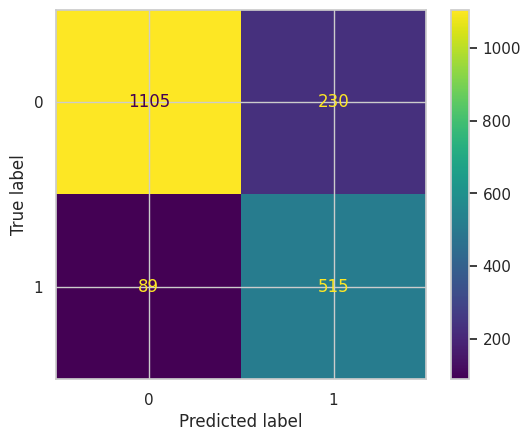

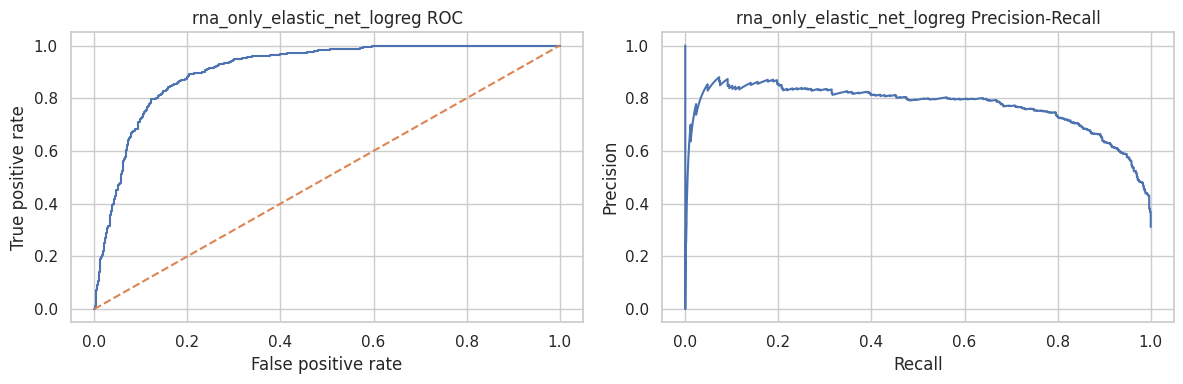

In [70]:
best_rna_artifact = rna_search["best_artifact"]
rna_test_proba = predict_rna_artifact(best_rna_artifact, X_rna_test)
rna_metrics = pd.Series({"model": "rna_only_elastic_net_logreg", **evaluate_from_proba(y_test, rna_test_proba)})

print()
print("rna_only_elastic_net_logreg")
display(rna_metrics.to_frame("value"))

rna_test_pred = (rna_test_proba >= 0.5).astype(int)
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, rna_test_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
print("Classification report at fixed threshold 0.5:")
print(classification_report(y_test, rna_test_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, rna_test_pred)
plt.show()
plot_roc_pr_curves(y_test, rna_test_proba, title_prefix="rna_only_elastic_net_logreg")

## Holdout comparison and calibration diagnostics

,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,rna_only_elastic_net_logreg,0.908491,0.769996,0.840182,0.763529,0.120695
1,dummy_prior,0.500000,0.311501,0.500000,0.000000,0.214468


,model,auroc_ci_2.5,auroc_ci_50,auroc_ci_97.5,auprc_ci_2.5,auprc_ci_50,auprc_ci_97.5
0,rna_only_elastic_net_logreg,0.895549,0.908046,0.922525,0.731342,0.769976,0.815197


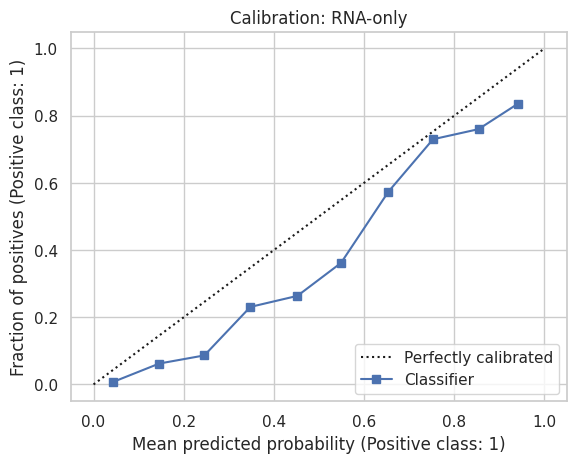

In [71]:
holdout_results = pd.DataFrame([dummy_metrics, rna_metrics])
holdout_results = holdout_results.sort_values("auprc", ascending=False).reset_index(drop=True)
display(holdout_results)

ci_rows = []
for model_name, proba in [
    ("rna_only_elastic_net_logreg", rna_test_proba),
]:
    auroc_lo, auroc_med, auroc_hi = bootstrap_metric_ci(y_test, proba, roc_auc_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    auprc_lo, auprc_med, auprc_hi = bootstrap_metric_ci(y_test, proba, average_precision_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    ci_rows.append({
        "model": model_name,
        "auroc_ci_2.5": auroc_lo,
        "auroc_ci_50": auroc_med,
        "auroc_ci_97.5": auroc_hi,
        "auprc_ci_2.5": auprc_lo,
        "auprc_ci_50": auprc_med,
        "auprc_ci_97.5": auprc_hi,
    })

holdout_ci = pd.DataFrame(ci_rows)
display(holdout_ci)

CalibrationDisplay.from_predictions(y_test, rna_test_proba, n_bins=10)
plt.title("Calibration: RNA-only")
plt.show()


## Task 2: multiclass TP53 mutation-type prediction with cancer-type-stratified splitting

This section addresses the assignment's mutation-type task in TCGA. It predicts broad TP53 mutation-type/consequence classes from RNA expression:

- `WT`;
- `missense`;
- `truncating_or_splice`.

Cancer type is used for stratified splitting and auditing only. It is not included as a feature in the primary RNA model. The Task 2 split is stratified by **mutation-type class x cancer type** where feasible so that both mutation-type prevalence and cancer-type composition are reasonably balanced between train and test.

The 3-class TCGA Task 2 result should be interpreted more cautiously than the CCLE result. TCGA is pan-cancer, tumor samples are biologically heterogeneous, and the mutation-type classes are imbalanced. In the held-out test set, the model performs well on the WT class but has lower F1 for `missense` and especially `truncating_or_splice`. This is expected because distinguishing mutation mechanisms or consequence classes from bulk RNA expression is harder than detecting broad mutant-vs-WT status.

The notebook also computes a strict **mutant-only Task 2** report on TP53-mutant held-out samples only, comparing `missense` versus `truncating_or_splice`. This directly addresses a strict interpretation of "type of mutation." In this evaluation, WT predictions made by the 3-class model on mutant samples are counted as errors in the metrics. The mutant-only confusion table focuses on the two mutant classes, so the full 3-class confusion matrix should be considered when interpreting WT-predicted errors.

In [72]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in TCGA
# ============================================================
# Methodological changes from the initial completed version:
#   * The Task 2 train/test split is stratified by mutation-type label and cancer type.
#   * Cancer type is the TCGA analogue of CCLE lineage.
#   * The model chosen for detailed reporting is selected by CV macro-F1, not by test macro-F1.
#   * Cancer type is used for stratification/auditing only, not as a predictor.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



def make_stable_joint_strata(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

def align_task2_proba_from_classes(raw_proba, est_classes, labels):
    labels = list(labels)
    est_classes = list(est_classes)
    out = np.zeros((raw_proba.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw_proba[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


def fit_multiclass_logreg_ready(X_train_ready, y_train, C, l1_ratio):
    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=SKLEARN_MAX_ITER,
        tol=SAGA_TOL,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        C=float(C),
        l1_ratio=float(l1_ratio),
    )
    clf.fit(np.asarray(X_train_ready, dtype=np.float64), y_train)
    return clf


def fit_task2_rna_logreg_artifact(X_train, y_train, params):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_multiclass_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
    )
    return {
        "kind": "task2_rna_logreg",
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }


def fit_task2_rna_rf_artifact(X_train, y_train, params):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = RandomForestClassifier(
        n_estimators=int(params.get("n_estimators", 400)),
        max_depth=params.get("max_depth", 16),
        min_samples_leaf=int(params.get("min_samples_leaf", 2)),
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_ready, y_train)
    return {
        "kind": "task2_rna_random_forest",
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }


def predict_task2_rna_artifact(artifact, X, labels):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    raw = artifact["model"].predict_proba(X_ready)
    return align_task2_proba_from_classes(raw, artifact["model"].classes_, labels)



def task2_cv_search(model_name, fit_fn, predict_fn, param_grid, X_fit, y_fit, labels, cv):
    rows = []
    best_score = -np.inf
    best_params = None

    for params in list(ParameterGrid(param_grid)):
        fold_scores = []
        for tr, va in cv:
            artifact = fit_fn(X_fit[tr], y_fit[tr], params)
            proba = predict_fn(artifact, X_fit[va], labels)
            metrics, _ = evaluate_multiclass(y_fit[va], proba, labels)
            fold_scores.append(metrics["macro_f1"])
            del artifact, proba
            gc.collect()

        mean_macro_f1 = float(np.mean(fold_scores))
        rows.append({
            "model": model_name,
            "params": dict(params),
            "cv_macro_f1": mean_macro_f1,
        })
        if mean_macro_f1 > best_score:
            best_score = mean_macro_f1
            best_params = dict(params)

    final_artifact = fit_fn(X_fit, y_fit, best_params)
    return {
        "model": model_name,
        "best_params": best_params,
        "best_cv_macro_f1": float(best_score),
        "cv_results": pd.DataFrame(rows),
        "artifact": final_artifact,
    }


task2_labels = ["WT", "missense", "truncating_or_splice"]

task2_indices = model_meta_task2.index.to_numpy()
X_rna_task2 = X_rna[task2_indices]
X_meta_task2 = model_meta_task2[[CANCER_TYPE_COL]].copy().reset_index(drop=True)  # split/audit only; not a predictor
X_meta_task2[CANCER_TYPE_COL] = X_meta_task2[CANCER_TYPE_COL].astype(str).fillna("missing").replace({"nan": "missing"})
y_task2 = model_meta_task2["TP53_task2_label"].astype(str).to_numpy()
groups_task2 = model_meta_task2[CANCER_TYPE_COL].astype(str).to_numpy()

task2_all_pos = np.arange(len(y_task2))
task2_strata_all = make_stable_joint_strata(
    labels=y_task2,
    groups=groups_task2,
    min_count=2,
    group_name="cancer_type",
    split_fraction=TASK2_TEST_SIZE,
    min_group_count=25,
)

task2_train_pos, task2_test_pos = train_test_split(
    task2_all_pos,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=task2_strata_all,
)

X2_train = X_rna_task2[task2_train_pos]
X2_test = X_rna_task2[task2_test_pos]
X2_meta_train = X_meta_task2.iloc[task2_train_pos]  # split/audit only
X2_meta_test = X_meta_task2.iloc[task2_test_pos]  # split/audit only
y2_train = y_task2[task2_train_pos]
y2_test = y_task2[task2_test_pos]
g2_train = groups_task2[task2_train_pos]
g2_test = groups_task2[task2_test_pos]

task2_split_counts = pd.concat(
    {
        "train": pd.Series(y2_train).value_counts().reindex(task2_labels),
        "test": pd.Series(y2_test).value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_cancer_split_counts = pd.concat(
    {
        "train": pd.Series(g2_train).value_counts(),
        "test": pd.Series(g2_test).value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("TCGA Task 2 split counts using label-cancer-type stratification:")
display(task2_split_counts)
print("TCGA Task 2 cancer-type split counts, top 20 cancer types:")
display(task2_cancer_split_counts.head(20))
print("Cancer types absent from Task 2 train but present in test:", sorted(set(g2_test) - set(g2_train)))
print("Cancer types absent from Task 2 test but present in train:", sorted(set(g2_train) - set(g2_test))[:10])

task2_cv_n = min(INNER_CV_SPLITS, int(pd.Series(y2_train).value_counts().min()))
task2_train_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=g2_train,
    min_count=task2_cv_n,
    group_name="cancer_type",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RANDOM_STATE).split(
        np.zeros(len(y2_train)),
        task2_train_cv_strata,
    )
)

TASK2_LOGREG_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.03, 0.1, 0.3],
    "l1_ratio": [0.0, 0.5],
}

TASK2_RF_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "n_estimators": [400],
    "max_depth": [12, 20],
    "min_samples_leaf": [2],
}

# Baseline 1: empirical class prior.
task2_dummy = DummyClassifier(strategy="prior")
task2_dummy.fit(np.zeros((len(y2_train), 1)), y2_train)
task2_dummy_raw = task2_dummy.predict_proba(np.zeros((len(y2_test), 1)))
task2_dummy_proba = align_task2_proba_from_classes(task2_dummy_raw, task2_dummy.classes_, task2_labels)
task2_dummy_metrics, task2_dummy_pred = evaluate_multiclass(y2_test, task2_dummy_proba, task2_labels)

# RNA-only models.
task2_logreg_search = task2_cv_search(
    "task2_rna_multinomial_logreg",
    fit_task2_rna_logreg_artifact,
    predict_task2_rna_artifact,
    TASK2_LOGREG_GRID,
    X2_train,
    y2_train,
    task2_labels,
    task2_cv,
)

task2_rf_search = task2_cv_search(
    "task2_rna_random_forest",
    fit_task2_rna_rf_artifact,
    predict_task2_rna_artifact,
    TASK2_RF_GRID,
    X2_train,
    y2_train,
    task2_labels,
    task2_cv,
)

# RNA + cancer-type model intentionally omitted; predictors remain RNA-only.
task2_combo_search = None

task2_rows = [
    {
        "model": "task2_dummy_prior",
        "tier": "baseline",
        "best_cv_macro_f1": np.nan,
        "selection_macro_f1": np.nan,
        "best_params": {},
        **{f"test_{k}": v for k, v in task2_dummy_metrics.items()},
    },
]

task2_predictions = {
    "task2_dummy_prior": task2_dummy_pred,
}
task2_artifacts = {
    "task2_rna_multinomial_logreg": task2_logreg_search["artifact"],
    "task2_rna_random_forest": task2_rf_search["artifact"],
}

for search in [task2_logreg_search, task2_rf_search]:
    proba = predict_task2_rna_artifact(search["artifact"], X2_test, task2_labels)
    metrics, pred = evaluate_multiclass(y2_test, proba, task2_labels)
    task2_rows.append({
        "model": search["model"],
        "tier": "rna_only",
        "best_cv_macro_f1": search["best_cv_macro_f1"],
        "selection_macro_f1": search["best_cv_macro_f1"],
        "best_params": search["best_params"],
        **{f"test_{k}": v for k, v in metrics.items()},
    })
    task2_predictions[search["model"]] = pred


tcga_task2_results = pd.DataFrame(task2_rows)
tcga_task2_results["selection_rank"] = tcga_task2_results["selection_macro_f1"].rank(
    method="first",
    ascending=False,
    na_option="bottom",
).astype(int)
tcga_task2_results = tcga_task2_results.sort_values("selection_rank").reset_index(drop=True)

display(tcga_task2_results)

selectable = tcga_task2_results.loc[tcga_task2_results["selection_macro_f1"].notna()].copy()
best_tcga_task2_model = selectable.iloc[0]["model"]
best_tcga_task2_pred = task2_predictions[best_tcga_task2_model]

tcga_task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_tcga_task2_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

tcga_task2_report = multiclass_report_df(
    y2_test,
    best_tcga_task2_pred,
    task2_labels,
)

print(f"Best TCGA Task 2 model by CV macro-F1: {best_tcga_task2_model}")
display(tcga_task2_confusion)
display(tcga_task2_report.round(4))

# Strict assignment-aligned Task 2: evaluate mutation type among TP53-mutant samples only.
# The fitted model and predictions are unchanged; WT test samples are removed only for this metric.
tcga_task2_mutant_labels = ["missense", "truncating_or_splice"]
tcga_task2_mutant_mask = pd.Series(y2_test).astype(str).ne("WT").to_numpy()
tcga_task2_mutant_y_true = pd.Series(y2_test).astype(str).to_numpy()[tcga_task2_mutant_mask]
tcga_task2_mutant_y_pred = pd.Series(best_tcga_task2_pred).astype(str).to_numpy()[tcga_task2_mutant_mask]

tcga_task2_mutant_only_metrics = pd.DataFrame([
    {
        "cohort": "TCGA",
        "evaluation": "mutant_only_task2",
        "best_model": best_tcga_task2_model,
        "n_mutant_test_samples": int(tcga_task2_mutant_mask.sum()),
        "labels": json.dumps(tcga_task2_mutant_labels),
        "accuracy": accuracy_score(tcga_task2_mutant_y_true, tcga_task2_mutant_y_pred),
        "balanced_accuracy": balanced_accuracy_score(tcga_task2_mutant_y_true, tcga_task2_mutant_y_pred),
        "macro_f1": f1_score(
            tcga_task2_mutant_y_true,
            tcga_task2_mutant_y_pred,
            average="macro",
            labels=tcga_task2_mutant_labels,
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            tcga_task2_mutant_y_true,
            tcga_task2_mutant_y_pred,
            average="weighted",
            labels=tcga_task2_mutant_labels,
            zero_division=0,
        ),
    }
])

tcga_task2_mutant_only_confusion = pd.DataFrame(
    confusion_matrix(
        tcga_task2_mutant_y_true,
        tcga_task2_mutant_y_pred,
        labels=tcga_task2_mutant_labels,
    ),
    index=[f"true_{x}" for x in tcga_task2_mutant_labels],
    columns=[f"pred_{x}" for x in tcga_task2_mutant_labels],
)

tcga_task2_mutant_only_report = multiclass_report_df(
    tcga_task2_mutant_y_true,
    tcga_task2_mutant_y_pred,
    tcga_task2_mutant_labels,
)

print("Strict TCGA Task 2 mutant-only evaluation: missense vs truncating/splice")
display(tcga_task2_mutant_only_metrics.round(4))
display(tcga_task2_mutant_only_confusion)
display(tcga_task2_mutant_only_report.round(4))

# Optional cancer-type-grouped check for Task 2.
# This is reported as a robustness check because mutation-type classes can be sparse in held-out cancer groups.
tcga_task2_grouped_results = pd.DataFrame()
tcga_task2_grouped_summary = pd.DataFrame()

min_task2_class_n = int(pd.Series(y_task2).value_counts().min())
n_grouped_splits = min(GROUP_CV_SPLITS, len(np.unique(groups_task2)), min_task2_class_n)

if n_grouped_splits >= 3:
    grouped_rows = []
    grouped_cv_task2 = StratifiedGroupKFold(
        n_splits=n_grouped_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    for fold, (tr, te) in enumerate(grouped_cv_task2.split(X_rna_task2, y_task2, groups_task2), start=1):
        y_tr, y_te = y_task2[tr], y_task2[te]
        if set(task2_labels) - set(y_tr) or set(task2_labels) - set(y_te):
            grouped_rows.append({
                "fold": fold,
                "model": "task2_rna_multinomial_logreg",
                "status": "skipped_missing_class_in_train_or_test",
                "n_test": len(te),
            })
            continue
        artifact = fit_task2_rna_logreg_artifact(
            X_rna_task2[tr],
            y_tr,
            task2_logreg_search["best_params"],
        )
        proba = predict_task2_rna_artifact(artifact, X_rna_task2[te], task2_labels)
        metrics, _ = evaluate_multiclass(y_te, proba, task2_labels)
        grouped_rows.append({
            "fold": fold,
            "model": "task2_rna_multinomial_logreg",
            "status": "ok",
            "n_test": len(te),
            **metrics,
        })
    tcga_task2_grouped_results = pd.DataFrame(grouped_rows)
    display(tcga_task2_grouped_results)
    ok_grouped = tcga_task2_grouped_results.loc[tcga_task2_grouped_results["status"].eq("ok")]
    if len(ok_grouped) > 0:
        tcga_task2_grouped_summary = ok_grouped.groupby("model")[[
            "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "ovr_auroc_macro", "ovr_auprc_macro"
        ]].agg(["mean", "std"])
        display(tcga_task2_grouped_summary)
else:
    print("Skipping TCGA Task 2 grouped CV because class or cancer-type support is too sparse.")

# Save Task 2 outputs immediately so they are available even if later optional sections are skipped.
task2_raw_counts.to_csv("tcga_task2_raw_class_counts.csv")
task2_candidate_counts.to_csv("tcga_task2_collapsed_class_counts.csv")
task2_split_counts.to_csv("tcga_task2_split_class_counts.csv")
task2_cancer_split_counts.to_csv("tcga_task2_cancer_type_split_counts.csv")
tcga_task2_results.to_csv("tcga_task2_test_results.csv", index=False)
tcga_task2_confusion.to_csv("tcga_task2_confusion_matrix.csv")
tcga_task2_report.to_csv("tcga_task2_classification_report.csv", index=False)
tcga_task2_mutant_only_metrics.to_csv("tcga_task2_mutant_only_metrics.csv", index=False)
tcga_task2_mutant_only_confusion.to_csv("tcga_task2_mutant_only_confusion_matrix.csv")
tcga_task2_mutant_only_report.to_csv("tcga_task2_mutant_only_classification_report.csv", index=False)

task2_cv_result_frames = [
    task2_logreg_search["cv_results"],
    task2_rf_search["cv_results"],
]
pd.concat(task2_cv_result_frames, ignore_index=True).to_csv("tcga_task2_cv_results.csv", index=False)

if len(tcga_task2_grouped_results) > 0:
    tcga_task2_grouped_results.to_csv("tcga_task2_grouped_cv_results.csv", index=False)
if len(tcga_task2_grouped_summary) > 0:
    tcga_task2_grouped_summary.to_csv("tcga_task2_grouped_cv_summary.csv")


Using adaptive TP53-label x cancer_type strata: 89 strata; rare cancer_type threshold=15. No samples dropped.
TCGA Task 2 split counts using label-cancer-type stratification:


,train,test
WT,5309,1327
missense,1518,380
truncating_or_splice,845,212


TCGA Task 2 cancer-type split counts, top 20 cancer types:


,train,test
BRCA,868,218
KIRC,423,106
THCA,404,100
HNSC,403,102
LGG,401,101
LUAD,400,101
PRAD,397,98
LUSC,379,95
SKCM,370,92
OV,338,84


Cancer types absent from Task 2 train but present in test: []
Cancer types absent from Task 2 test but present in train: []
Using adaptive TP53-label x cancer_type strata: 86 strata; rare cancer_type threshold=10. No samples dropped.


...

,cohort,evaluation,best_model,n_mutant_test_samples,labels,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,TCGA,mutant_only_task2,task2_rna_multinomial_logreg,592,"[""missense"", ""truncating_or_splice""]",0.4628,0.4544,0.4921,0.5123


,pred_missense,pred_truncating_or_splice
true_missense,184,126
true_truncating_or_splice,89,90


,class,precision,recall,f1-score,support
0,missense,0.6740,0.4842,0.5636,380.0
1,truncating_or_splice,0.4167,0.4245,0.4206,212.0
2,micro avg,0.5603,0.4628,0.5069,592.0
3,macro avg,0.5453,0.4544,0.4921,592.0
4,weighted avg,0.5818,0.4628,0.5123,592.0


,fold,model,status,n_test,accuracy,balanced_accuracy,macro_f1,weighted_f1,ovr_auroc_macro,ovr_auprc_macro
0,1,task2_rna_multinomial_logreg,ok,4164,0.615754,0.509778,0.501465,0.619429,0.726843,0.497797
1,2,task2_rna_multinomial_logreg,ok,2648,0.669184,0.474036,0.474213,0.668907,0.735142,0.480589
2,3,task2_rna_multinomial_logreg,ok,2779,0.578625,0.479318,0.403204,0.644642,0.704635,0.415548


accuracy           balanced_accuracy            macro_f1           weighted_f1           ovr_auroc_macro           ovr_auprc_macro          
                                  mean       std              mean       std      mean       std        mean       std            mean       std            mean       std
model                                                                                                                                                                     
task2_rna_multinomial_logreg  0.621188  0.045523           0.48771  0.019293  0.459627  0.050728    0.644326  0.024741        0.722207  0.015773        0.464645  0.043381

## Cancer-type-grouped RNA-only evaluation

This is the main anti-confounding section. Cancer type is used as the grouping variable for evaluation, not as a predictor. With `GROUPED_TUNING_MODE = "reuse_holdout_best"`, the grouped result is a practical robustness check; set `GROUPED_TUNING_MODE = "nested"` only if you have enough runtime for fully nested grouped tuning.


In [73]:
if RUN_GROUPED_CV:
    group_outer = StratifiedGroupKFold(
        n_splits=GROUP_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    group_inner = StratifiedGroupKFold(
        n_splits=max(3, GROUP_CV_SPLITS - 1),
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    group_rows = []

    for fold, (tr_idx, te_idx) in enumerate(group_outer.split(X_rna, y, groups), start=1):
        y_tr, y_te = y[tr_idx], y[te_idx]
        g_tr = groups[tr_idx]

        X_rna_tr = X_rna[tr_idx]
        X_rna_te = X_rna[te_idx]

        dummy = DummyClassifier(strategy="prior")
        dummy.fit(np.zeros((len(tr_idx), 1)), y_tr)
        dummy_proba = dummy.predict_proba(np.zeros((len(te_idx), 1)))[:, 1]
        group_rows.append({
            "fold": fold,
            "model": "dummy_prior",
            **evaluate_from_proba(y_te, dummy_proba),
        })

        if GROUPED_TUNING_MODE == "nested":
            rna_group_search = manual_cv_search_rna(
                X=X_rna_tr,
                y=y_tr,
                splitter=group_inner,
                param_grid=GROUPED_RNA_PARAM_GRID,
                search_backend=GPU_SEARCH_BACKEND,
                refit_backend=FINAL_REFIT_BACKEND,
                groups=g_tr,
                verbose=0,
                label=f"RNA_GROUP_FOLD_{fold}",
            )
            rna_group_artifact = rna_group_search["best_artifact"]
        else:
            rna_group_artifact = fit_rna_artifact(
                X_train=X_rna_tr,
                y_train=y_tr,
                params=rna_search["best_params"],
                backend=FINAL_REFIT_BACKEND,
            )
        rna_group_proba = predict_rna_artifact(rna_group_artifact, X_rna_te)
        group_rows.append({
            "fold": fold,
            "model": "rna_only_elastic_net_logreg",
            **evaluate_from_proba(y_te, rna_group_proba),
        })

        print(f"Completed grouped outer fold {fold}/{GROUP_CV_SPLITS}")

    group_results = pd.DataFrame(group_rows)
    display(group_results)

    group_summary = (
        group_results
        .groupby("model")[["auroc", "auprc", "balanced_accuracy_at_0.5", "f1_at_0.5", "brier"]]
        .agg(["mean", "std"])
    )
    display(group_summary)
else:
    print("RUN_GROUPED_CV is False; skipping grouped evaluation.")


Completed grouped outer fold 1/3
Completed grouped outer fold 2/3
Completed grouped outer fold 3/3


,fold,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,1,dummy_prior,0.500000,0.412194,0.500000,0.000000,0.266505
1,1,rna_only_elastic_net_logreg,0.808455,0.712629,0.679999,0.584602,0.185687
2,2,dummy_prior,0.500000,0.248983,0.500000,0.000000,0.196417
3,2,rna_only_elastic_net_logreg,0.717040,0.375241,0.625679,0.449173,0.226959
4,3,dummy_prior,0.500000,0.265841,0.500000,0.000000,0.199340
5,3,rna_only_elastic_net_logreg,0.819825,0.643773,0.741002,0.607450,0.164381


auroc               auprc          balanced_accuracy_at_0.5           f1_at_0.5               brier          
                                 mean       std      mean      std                     mean       std      mean       std      mean       std
model                                                                                                                                        
dummy_prior                  0.500000  0.000000  0.309006  0.08976                 0.500000  0.000000  0.000000  0.000000  0.220754  0.039648
rna_only_elastic_net_logreg  0.781773  0.056348  0.577214  0.17827                 0.682227  0.057694  0.547075  0.085552  0.192342  0.031815

## Inspect RNA coefficients and optional biological sanity checks

This section strips Ensembl version suffixes, optionally maps to gene symbols, and checks overlap with the TP53 target list when possible.

The TP53 target list here refers to curated p53-response genes, such as the optional `tp53_target_genes_fischer2017.csv` reference, not to genes that are mutated. Because TCGA RNA features are often Ensembl IDs, coefficient interpretation is limited unless a reliable Ensembl-to-symbol annotation is available. Without that mapping, individual coefficients should be treated as predictive RNA features rather than named biological mechanisms.


In [74]:
best_rna_preproc = best_rna_artifact["preproc"]
final_features = extract_rna_feature_names(best_rna_preproc, gene_ids)
coef = np.asarray(best_rna_artifact["model"].coef_).ravel()

coef_df = pd.DataFrame({
    "ensembl_gene_id": final_features,
    "coefficient": coef,
})
coef_df["ensembl_gene_id_no_version"] = coef_df["ensembl_gene_id"].astype(str).str.replace(r"\..*$", "", regex=True)

def infer_ensembl_col(df):
    candidates = [
        "ensembl_gene_id", "ensembl_gene_id_no_version", "Ensembl", "ENSEMBL",
        "gene_id", "id", "feature_id",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def infer_symbol_col(df):
    candidates = [
        "gene_symbol", "symbol", "gene", "Gene", "HugoSymbol", "hgnc_symbol",
        "approved_symbol", "gene_name",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def parse_symbol_from_feature_id(x):
    parts = [p.strip() for p in str(x).split("|")]
    for part in parts:
        if part and not looks_like_ensembl(part):
            return part
    return np.nan

# Fallback: if feature IDs themselves carry symbols, use them.
coef_df["gene_symbol"] = coef_df["ensembl_gene_id"].map(parse_symbol_from_feature_id)

annotation_loaded = False
if GENE_ANNOTATION_PATH is not None:
    gene_annot = pd.read_csv(GENE_ANNOTATION_PATH, sep=None, engine="python", low_memory=False)
    annot_ensembl_col = infer_ensembl_col(gene_annot)
    annot_symbol_col = infer_symbol_col(gene_annot)
    if annot_ensembl_col is not None and annot_symbol_col is not None:
        gene_map = gene_annot[[annot_ensembl_col, annot_symbol_col]].copy()
        gene_map.columns = ["ensembl_gene_id_raw", "gene_symbol_from_annotation"]
        gene_map["ensembl_gene_id_no_version"] = gene_map["ensembl_gene_id_raw"].astype(str).str.replace(r"\..*$", "", regex=True)
        gene_map = gene_map.dropna(subset=["gene_symbol_from_annotation"]).drop_duplicates("ensembl_gene_id_no_version")
        coef_df = coef_df.merge(
            gene_map[["ensembl_gene_id_no_version", "gene_symbol_from_annotation"]],
            on="ensembl_gene_id_no_version",
            how="left",
        )
        coef_df["gene_symbol"] = coef_df["gene_symbol"].fillna(coef_df["gene_symbol_from_annotation"])
        annotation_loaded = True

coef_df["is_tp53_target"] = False
if TP53_TARGETS_PATH is not None and TP53_TARGETS_PATH.exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH, low_memory=False)
    target_ensembl_col = infer_ensembl_col(tp53_targets)
    target_symbol_col = infer_symbol_col(tp53_targets)

    if target_ensembl_col is not None:
        target_ids = (
            tp53_targets[target_ensembl_col]
            .astype(str)
            .str.replace(r"\..*$", "", regex=True)
            .dropna()
            .unique()
        )
        coef_df["is_tp53_target"] = coef_df["ensembl_gene_id_no_version"].isin(target_ids)
    if target_symbol_col is not None:
        target_symbols = set(tp53_targets[target_symbol_col].astype(str).str.upper().dropna())
        coef_df["is_tp53_target"] = coef_df["is_tp53_target"] | coef_df["gene_symbol"].astype(str).str.upper().isin(target_symbols)

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)

print("Gene symbol annotation loaded:", annotation_loaded)
print("Top positive coefficients:")
display(coef_df.head(TOP_COEFS_TO_SHOW))

print("Top negative coefficients:")
display(coef_df.tail(TOP_COEFS_TO_SHOW).sort_values("coefficient"))

print("Largest absolute coefficients:")
display(coef_df.sort_values("abs_coefficient", ascending=False).head(TOP_COEFS_TO_SHOW))

print("TP53-target overlap among selected RNA features:", int(coef_df["is_tp53_target"].sum()))

canonical_tp53_pathway = ["TP53", "MDM2", "CDKN1A", "BAX", "DDB2", "XPC", "FDXR", "RPS27L", "DRAM1", "EDA2R"]
canonical_hits = coef_df.loc[coef_df["gene_symbol"].astype(str).str.upper().isin(canonical_tp53_pathway)].copy()
print("Canonical TP53 pathway genes selected:", len(canonical_hits))
display(canonical_hits.sort_values("abs_coefficient", ascending=False))

Gene symbol annotation loaded: False
Top positive coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
0,ENSG00000226251.5,0.273782,ENSG00000226251,NaN,False,0.273782
1,ENSG00000215221.2,0.267109,ENSG00000215221,NaN,False,0.267109
2,ENSG00000259803.6,0.253814,ENSG00000259803,NaN,False,0.253814
3,ENSG00000184697.6,0.236366,ENSG00000184697,NaN,False,0.236366
4,ENSG00000184486.8,0.232791,ENSG00000184486,NaN,False,0.232791
5,ENSG00000240990.9,0.229591,ENSG00000240990,NaN,False,0.229591
6,ENSG00000187527.10,0.211617,ENSG00000187527,NaN,False,0.211617
7,ENSG00000270460.1,0.187954,ENSG00000270460,NaN,False,0.187954
8,ENSG00000171124.12,0.178542,ENSG00000171124,NaN,False,0.178542
9,ENSG00000103460.16,0.175351,ENSG00000103460,NaN,False,0.175351


Top negative coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
999,ENSG00000251095.6,-0.691968,ENSG00000251095,NaN,False,0.691968
998,ENSG00000250337.5,-0.689434,ENSG00000250337,NaN,False,0.689434
997,ENSG00000205592.13,-0.291071,ENSG00000205592,NaN,False,0.291071
996,ENSG00000105278.10,-0.265551,ENSG00000105278,NaN,False,0.265551
995,ENSG00000269941.1,-0.245882,ENSG00000269941,NaN,False,0.245882
994,ENSG00000176769.9,-0.217584,ENSG00000176769,NaN,False,0.217584
993,ENSG00000081479.12,-0.203995,ENSG00000081479,NaN,False,0.203995
992,ENSG00000197084.5,-0.198228,ENSG00000197084,NaN,False,0.198228
991,ENSG00000253764.1,-0.196143,ENSG00000253764,NaN,False,0.196143
990,ENSG00000143217.8,-0.193683,ENSG00000143217,NaN,False,0.193683


Largest absolute coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
999,ENSG00000251095.6,-0.691968,ENSG00000251095,NaN,False,0.691968
998,ENSG00000250337.5,-0.689434,ENSG00000250337,NaN,False,0.689434
997,ENSG00000205592.13,-0.291071,ENSG00000205592,NaN,False,0.291071
0,ENSG00000226251.5,0.273782,ENSG00000226251,NaN,False,0.273782
1,ENSG00000215221.2,0.267109,ENSG00000215221,NaN,False,0.267109
996,ENSG00000105278.10,-0.265551,ENSG00000105278,NaN,False,0.265551
2,ENSG00000259803.6,0.253814,ENSG00000259803,NaN,False,0.253814
995,ENSG00000269941.1,-0.245882,ENSG00000269941,NaN,False,0.245882
3,ENSG00000184697.6,0.236366,ENSG00000184697,NaN,False,0.236366
4,ENSG00000184486.8,0.232791,ENSG00000184486,NaN,False,0.232791


TP53-target overlap among selected RNA features: 0
Canonical TP53 pathway genes selected: 0


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient


## Combined RNA + cancer-type model intentionally omitted

This section is kept as a placeholder to make the modelling choice explicit. The submitted primary models remain RNA-only, so cancer type is not added as a predictor. Cancer type is used for stratification, auditing, and grouped evaluation instead.


In [75]:
# Combined RNA + cancer-type model intentionally disabled/omitted.
# Cancer type is used for stratification and auditing only, not as a predictor.
combo_search = None
best_combo_artifact = None
combo_test_proba = None
combo_metrics = None
print("Skipping RNA + cancer-type combined model by design; predictors remain RNA-only.")


Skipping RNA + cancer-type combined model by design; predictors remain RNA-only.


## TCGA RNA-only ablation and soft-voting ensemble

This section is enabled by default. It fits RNA-only ablation candidates using the available GPU backend when possible, falls back safely when needed, and then builds a soft-voting ensemble from the top ablation models. Cancer type is used only for stratification/grouped evaluation, not as a predictor.


In [76]:
# ============================================================
# TCGA RNA-only ablation table: GPU if available, CPU-safe fallback
# ============================================================

import time
import gc

RUN_RNA_ABLATION = True
ABLATION_ENSEMBLE_TOP_N = 3
ABLATION_BACKEND = "cuml" if GPU_AVAILABLE and cuLogisticRegression is not None else "sklearn"

print("RUN_RNA_ABLATION:", RUN_RNA_ABLATION)
print("Ablation backend:", ABLATION_BACKEND, "(cancer type is not used as a predictor)")

# X_rna is already feature-capped for TCGA. Keep every ablation top_k within the
# currently materialized TCGA RNA matrix and refit on TCGA train only. This avoids
# accidentally using stale CCLE globals such as X_trainval/y_trainval.
TCGA_ABLATION_TOP_K = int(min(TOP_VAR_GENES, X_rna_train.shape[1]))
print("TCGA ablation top_k capped at:", TCGA_ABLATION_TOP_K)

ablation_searches = {}
ablation_cv_results = pd.DataFrame()
ablation_test_scores = {}
ablation_table = pd.DataFrame()
ablation_failures = {}

if RUN_RNA_ABLATION:
    # Fixed, compact RNA-only candidates. These are deliberately small to keep Kaggle runtime feasible.
    # They still test preprocessing/model-regularization sensitivity without using metadata features.
    ABLATION_CANDIDATES = [
        {
            "model": "ablation_enet_sparse_500",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 500, "scaler": "maxabs", "C": 0.1, "l1_ratio": 0.5},
        },
        {
            "model": "ablation_l2_500",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 500, "scaler": "maxabs", "C": 0.1, "l1_ratio": 0.0},
        },
        {
            "model": "ablation_l2_1000",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 1000, "scaler": "maxabs", "C": 0.1, "l1_ratio": 0.0},
        },
        {
            "model": "ablation_enet_1000_highC",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 1000, "scaler": "maxabs", "C": 1.0, "l1_ratio": 0.5},
        },
    ]

    rows = []
    cv_rows = []
    for candidate in ABLATION_CANDIDATES:
        model_name = candidate["model"]
        params = candidate["params"]
        start = time.time()
        print(f"Running RNA-only ablation candidate: {model_name} | {params}")
        try:
            fold_metrics = crossval_fixed_rna_params(
                X=X_rna_train,
                y=y_train,
                splitter=inner_cv,
                params=params,
                backend=ABLATION_BACKEND,
                groups=None,
            )
            mean_cv_auprc = float(fold_metrics["auprc"].mean())
            mean_cv_auroc = float(fold_metrics["auroc"].mean())
            std_cv_auprc = float(fold_metrics["auprc"].std())
            fold_metrics.insert(0, "model", model_name)
            fold_metrics["params"] = json.dumps(params)
            cv_rows.append(fold_metrics)

            artifact = fit_rna_artifact(
                X_train=X_rna_train,
                y_train=y_train,
                params=params,
                backend=FINAL_REFIT_BACKEND,
            )
            test_score = predict_rna_artifact(artifact, X_rna_test)
            ablation_test_scores[model_name] = test_score
            test_metrics = evaluate_from_proba(y_test, test_score)

            ablation_searches[model_name] = {"best_score": mean_cv_auprc, "best_params": params}
            rows.append({
                "model": model_name,
                "backend_for_cv": ABLATION_BACKEND,
                "best_cv_auprc": mean_cv_auprc,
                "cv_auroc": mean_cv_auroc,
                "cv_auprc_std": std_cv_auprc,
                "best_params": params,
                "seconds": time.time() - start,
                **{f"test_{k}": v for k, v in test_metrics.items()},
            })
            del artifact, test_score
            gc.collect()
            if cp is not None:
                try:
                    cp.get_default_memory_pool().free_all_blocks()
                except Exception:
                    pass
        except Exception as exc:
            ablation_failures[model_name] = repr(exc)
            print(f"Ablation candidate failed and will be skipped: {model_name}: {repr(exc)}")

    ablation_cv_results = pd.concat(cv_rows, ignore_index=True) if len(cv_rows) else pd.DataFrame()
    ablation_table = (
        pd.DataFrame(rows)
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
        if len(rows)
        else pd.DataFrame()
    )

    print("TCGA RNA-only ablation table, selected without metadata predictors:")
    display(ablation_table)

    if len(ablation_cv_results):
        ablation_cv_results.to_csv("tcga_rna_ablation_cv_results.csv", index=False)
    if len(ablation_table):
        ablation_table.to_csv("tcga_rna_model_ablation_table.csv", index=False)
    if ablation_failures:
        print("Ablation failures/skips:")
        for name, err in ablation_failures.items():
            print(f" - {name}: {err}")
else:
    print("RUN_RNA_ABLATION is False; skipping RNA ablation table.")


RUN_RNA_ABLATION: True
Ablation backend: cuml (cancer type is not used as a predictor)
TCGA ablation top_k capped at: 3000
Running RNA-only ablation candidate: ablation_enet_sparse_500 | {'top_k': 3000, 'k_select': 500, 'scaler': 'maxabs', 'C': 0.1, 'l1_ratio': 0.5}
Running RNA-only ablation candidate: ablation_l2_500 | {'top_k': 3000, 'k_select': 500, 'scaler': 'maxabs', 'C': 0.1, 'l1_ratio': 0.0}
Running RNA-only ablation candidate: ablation_l2_1000 | {'top_k': 3000, 'k_select': 1000, 'scaler': 'maxabs', 'C': 0.1, 'l1_ratio': 0.0}
Running RNA-only ablation candidate: ablation_enet_1000_highC | {'top_k': 3000, 'k_select': 1000, 'scaler': 'maxabs', 'C': 1.0, 'l1_ratio': 0.5}
TCGA RNA-only ablation table, selected without metadata predictors:


,model,backend_for_cv,best_cv_auprc,cv_auroc,cv_auprc_std,best_params,seconds,test_auroc,test_auprc,test_balanced_accuracy_at_0.5,test_f1_at_0.5,test_brier
0,ablation_l2_1000,cuml,0.771524,0.895465,0.007238,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm...",13.346067,0.903043,0.766962,0.834683,0.757848,0.123513
1,ablation_enet_sparse_500,cuml,0.771029,0.896705,0.006072,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma...",8.772050,0.904068,0.759300,0.832219,0.753516,0.122954
2,ablation_l2_500,cuml,0.767440,0.893834,0.010909,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma...",6.679006,0.900504,0.753499,0.826937,0.748687,0.124719
3,ablation_enet_1000_highC,cuml,0.747419,0.879485,0.010160,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm...",44.074928,0.893344,0.753034,0.817003,0.737320,0.132337


### Soft-voting ensemble and final ablation comparison

The ensemble is selected without looking at test labels: the top RNA-only models by inner-CV AUPRC are averaged with uniform weights. This tests whether RNA model diversity improves held-out AUPRC beyond the main elastic-net model.


In [77]:
# ============================================================
# Soft-voting ensemble and final comparison table
# ============================================================

if RUN_RNA_ABLATION and len(ablation_table) > 0:
    top_ensemble_models = (
        ablation_table
        .sort_values("best_cv_auprc", ascending=False)
        .head(min(ABLATION_ENSEMBLE_TOP_N, len(ablation_table)))["model"]
        .tolist()
    )

    print("Soft-voting ensemble members selected by inner-CV AUPRC:")
    print(top_ensemble_models)

    ensemble_test_score = np.mean(
        [ablation_test_scores[m] for m in top_ensemble_models],
        axis=0,
    )
    ensemble_metrics = evaluate_from_proba(y_test, ensemble_test_score)

    ensemble_row = {
        "model": f"soft_vote_top{len(top_ensemble_models)}_by_cv_auprc",
        "best_cv_auprc": float(np.mean([ablation_searches[m]["best_score"] for m in top_ensemble_models])),
        "best_params": {
            "members": top_ensemble_models,
            "weights": "uniform",
            "selection_rule": "top models by inner-CV AUPRC",
        },
        **{f"test_{k}": v for k, v in ensemble_metrics.items()},
    }

    ablation_table_with_ensemble = (
        pd.concat([ablation_table, pd.DataFrame([ensemble_row])], ignore_index=True)
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
    )

    # Recompute the holdout dummy score because the grouped-CV section reuses the variable name dummy_proba.
    holdout_dummy_score = np.repeat(float(np.mean(y_train)), len(y_test))

    main_rows_for_ablation = []
    existing_model_scores = {
        "dummy_prior": holdout_dummy_score,
        "main_rna_elastic_net_logreg": rna_test_proba,
    }

    for model_name, score in existing_model_scores.items():
        metrics = evaluate_from_proba(y_test, score)
        main_rows_for_ablation.append({
            "model": model_name,
            "model_family": "main_notebook_model",
            "best_cv_auprc": np.nan,
            "best_params": np.nan,
            **{f"test_{k}": v for k, v in metrics.items()},
        })

    ablation_rows_clean = ablation_table_with_ensemble.copy()
    ablation_rows_clean["model_family"] = "rna_ablation"

    final_ablation_table = pd.concat(
        [pd.DataFrame(main_rows_for_ablation), ablation_rows_clean],
        ignore_index=True,
    )

    preferred_cols = [
        "model",
        "model_family",
        "best_cv_auprc",
        "test_auprc",
        "test_auroc",
        "test_balanced_accuracy_at_0.5",
        "test_f1_at_0.5",
        "test_brier",
        "best_params",
    ]

    final_ablation_table = (
        final_ablation_table[preferred_cols]
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
    )

    print("Final holdout comparison including main models, RNA ablations, and soft-voting ensemble:")
    display(final_ablation_table)

    final_ablation_table.to_csv("tcga_rna_model_ablation_table.csv", index=False)
    if len(ablation_cv_results):
        ablation_cv_results.to_csv("tcga_rna_model_ablation_cv_results.csv", index=False)
    print("Saved final ablation outputs to tcga_rna_model_ablation_table.csv and tcga_rna_model_ablation_cv_results.csv")
else:
    top_ensemble_models = []
    ablation_table_with_ensemble = pd.DataFrame()
    final_ablation_table = pd.DataFrame()
    print("RNA ablation was skipped or no ablation model succeeded; no ensemble/final ablation table created.")


Soft-voting ensemble members selected by inner-CV AUPRC:
['ablation_l2_1000', 'ablation_enet_sparse_500', 'ablation_l2_500']
Final holdout comparison including main models, RNA ablations, and soft-voting ensemble:


,model,model_family,best_cv_auprc,test_auprc,test_auroc,test_balanced_accuracy_at_0.5,test_f1_at_0.5,test_brier,best_params
0,main_rna_elastic_net_logreg,main_notebook_model,NaN,0.769996,0.908491,0.840182,0.763529,0.120695,NaN
1,ablation_l2_1000,rna_ablation,0.771524,0.766962,0.903043,0.834683,0.757848,0.123513,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm..."
2,soft_vote_top3_by_cv_auprc,rna_ablation,0.769998,0.766553,0.908159,0.846313,0.773998,0.118910,"{'members': ['ablation_l2_1000', 'ablation_ene..."
3,ablation_enet_sparse_500,rna_ablation,0.771029,0.759300,0.904068,0.832219,0.753516,0.122954,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma..."
4,ablation_l2_500,rna_ablation,0.767440,0.753499,0.900504,0.826937,0.748687,0.124719,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma..."
5,ablation_enet_1000_highC,rna_ablation,0.747419,0.753034,0.893344,0.817003,0.737320,0.132337,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm..."
6,dummy_prior,main_notebook_model,NaN,0.311501,0.500000,0.500000,0.000000,0.214468,NaN


Saved final ablation outputs to tcga_rna_model_ablation_table.csv and tcga_rna_model_ablation_cv_results.csv


## Within-cancer RNA evaluation

This asks whether the RNA model still carries TP53 signal **within individual tumour types**, not just across pan-cancer mixtures.

This is a stricter confounding check than a random pan-cancer holdout. If the run flag is disabled, the notebook should be described as including grouped cancer-type CV but not a full within-cancer model audit.


In [78]:
if RUN_WITHIN_CANCER_EVAL:
    within_cancer_rows = []
    for cancer_type, idx in model_meta.groupby(CANCER_TYPE_COL).groups.items():
        idx = np.array(list(idx))
        y_sub = y[idx]
        counts = pd.Series(y_sub).value_counts()
        n_neg = int(counts.get(0, 0))
        n_pos = int(counts.get(1, 0))
        if n_neg < MIN_SAMPLES_PER_CLASS or n_pos < MIN_SAMPLES_PER_CLASS:
            continue

        cv_splits = min(5, n_neg, n_pos)
        if cv_splits < 3:
            continue

        sub_cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        sub_scores = crossval_fixed_rna_params(
            X=X_rna[idx],
            y=y_sub,
            splitter=sub_cv,
            params=rna_search["best_params"],
            backend=WITHIN_CANCER_BACKEND,
        )

        within_cancer_rows.append({
            "cancer_type": cancer_type,
            "n_samples": len(idx),
            "n_pos": n_pos,
            "n_neg": n_neg,
            "prevalence": n_pos / len(idx),
            "cv_auroc_mean": float(sub_scores["auroc"].mean()),
            "cv_auroc_std": float(sub_scores["auroc"].std(ddof=0)),
            "cv_auprc_mean": float(sub_scores["auprc"].mean()),
            "cv_auprc_std": float(sub_scores["auprc"].std(ddof=0)),
            "cv_balanced_accuracy_at_0.5_mean": float(sub_scores["balanced_accuracy_at_0.5"].mean()),
        })

    within_cancer_df = pd.DataFrame(within_cancer_rows).sort_values("cv_auprc_mean", ascending=False)
    display(within_cancer_df)

    if len(within_cancer_df) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(within_cancer_df["n_samples"], within_cancer_df["cv_auprc_mean"])
        for _, row in within_cancer_df.iterrows():
            plt.text(row["n_samples"], row["cv_auprc_mean"], row["cancer_type"], fontsize=8)
        plt.xlabel("Number of samples")
        plt.ylabel("Within-cancer CV AUPRC")
        plt.title("Within-cancer RNA performance by tumour type")
        plt.show()
else:
    print("RUN_WITHIN_CANCER_EVAL is False; skipping within-cancer evaluation.")

RUN_WITHIN_CANCER_EVAL is False; skipping within-cancer evaluation.


## Final conclusions and exam-defense summary

This notebook addresses both required coursework tasks using gene expression profiles as predictors and TP53 mutation annotations as labels.

### Task 1: TP53 mutant versus wild type

Task 1 is formulated as binary classification: TP53 protein-altering/nonsynonymous mutant versus no retained protein-altering TP53 mutation. The labels are constructed from somatic mutation annotations, not from RNA expression. The primary predictors are RNA expression measurements across genes.

The WT/non-mutant class should be interpreted operationally. It means no retained protein-altering TP53 event under the available annotation rules; it does not prove that the p53 pathway is fully intact.

The binary task is the most statistically stable part of the project. It has larger class support than the mutation-type task and asks a clearer biological question: whether RNA expression contains signal associated with TP53 mutation status. In both CCLE and TCGA, RNA-only models outperform simple baselines, supporting the conclusion that transcriptomic profiles contain predictive information about TP53 mutation status.

### Task 2: TP53 mutation type

Task 2 is implemented as coarse TP53 mutation-type/consequence prediction. The teaching material describes many mutation categories, including missense, nonsense, insertion, deletion, frameshift, and splice-site mutations. Instead of modelling every raw category separately, I grouped related annotations into broader classes with enough sample support.

In CCLE, the main classes are `wild_type`, `missense_or_inframe`, and `lof_or_splice`. In TCGA, the main classes are `WT`, `missense`, and `truncating_or_splice`. These classes capture an important biological distinction: missense/in-frame alterations often preserve protein length but alter sequence or local structure, whereas truncating, frameshift, nonsense, and splice-related events are more likely to severely disrupt TP53 function.

Because the phrase "type of mutation" can be interpreted strictly as a mutant-only task, the notebook also reports strict mutant-only Task 2 evaluations. These remove WT samples from the evaluation and compare the main mutant classes only. This makes the assignment alignment explicit while still preserving the broader 3-class status/type formulation.

### Splitting and confounding

Both datasets require careful splitting because cancer lineage or cancer type can confound the relationship between RNA expression and TP53 mutation. Gene expression is highly tissue-specific, and TP53 mutation prevalence differs across cancer types. Therefore, the notebook uses adaptive label-by-lineage or label-by-cancer-type stratification where feasible. Rare strata are collapsed rather than forcing unstable splits.

This stratification is used to balance train/test composition, not to train separate models within each lineage or cancer type. Rare lineages or cancer types may still have too few samples for reliable subgroup-specific conclusions. For this reason, the notebook also includes lineage/cancer-type audits, grouped evaluation, and model-family ablations.

### Leakage control

Mutation annotation columns are used only to define TP53 labels and are not included as RNA predictors. Supervised feature selection, scaling, and model fitting are performed within training or cross-validation workflows. The TCGA RNA loader uses an unsupervised high-variance feature cap for memory management, but this step does not use TP53 labels. This caveat should be distinguished from supervised leakage.

The compact CCLE `TP53_TARGETS` panel and the broader Fischer-style TP53 target-gene CSV are biological reference lists of p53-response genes. They are not mutation labels and not lists of genes mutated in the samples. When such genes are used in the CCLE feature builder, they enter only as RNA-expression measurements chosen from an a priori biological panel.

### Interpretation

The strongest scientific conclusion is that RNA expression contains predictive signal for TP53 mutation status. The project does not prove that selected genes causally determine TP53 mutation status. Important genes may reflect TP53 pathway activity, DNA-damage response, cell-cycle effects, cancer lineage, proliferation, or dataset-specific structure.

Task 2 should be interpreted more cautiously than Task 1. Mutation-type classes are smaller and more imbalanced, and different TP53 mutation types may produce overlapping downstream RNA effects. Therefore, macro-F1, balanced accuracy, per-class F1, and confusion matrices are more informative than accuracy alone.

Overall, the project satisfies the assignment by building and evaluating RNA-based models for both binary TP53 mutation status and TP53 mutation-type/consequence prediction, while explicitly addressing leakage, lineage/cancer-type confounding, class imbalance, and cautious biological interpretation.
